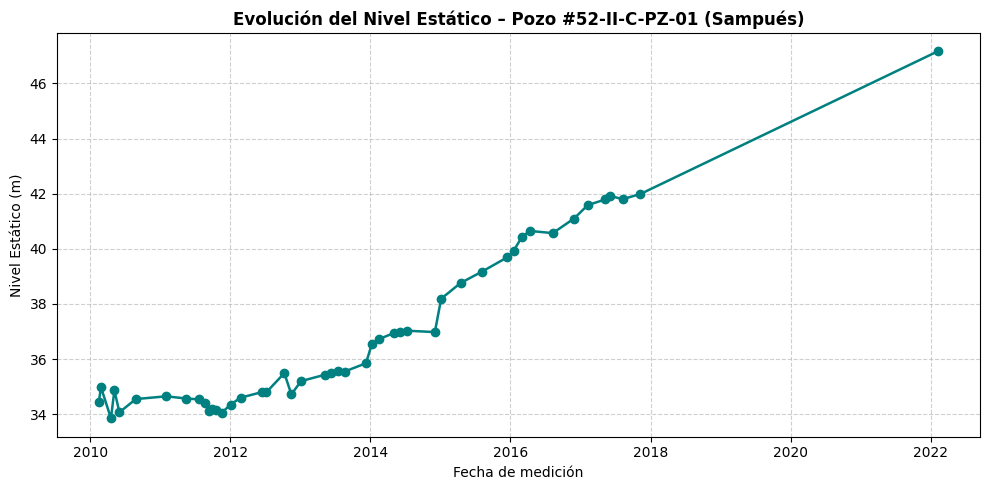

In [1]:
#Sampues - # 52-II-C-PZ-01

import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# 1. Crear el DataFrame con los datos del pozo
# -------------------------------
data = {
    'Fecha': [
        '15/02/2010','26/02/2010','19/04/2010','07/05/2010','02/06/2010','27/08/2010',
        '01/02/2011','16/05/2011','21/07/2011','22/08/2011','14/09/2011','28/09/2011',
        '18/10/2011','17/11/2011','03/01/2012','24/02/2012','13/06/2012','08/07/2012',
        '09/10/2012','15/11/2012','04/01/2013','07/05/2013','12/06/2013','16/07/2013',
        '20/08/2013','09/12/2013','08/01/2014','13/02/2014','05/05/2014','03/06/2014',
        '10/07/2014','03/12/2014','16/04/2015','05/01/2015','05/08/2015','15/12/2015',
        '18/01/2016','29/02/2016','11/04/2016','09/08/2016','28/11/2016','08/02/2017',
        '10/05/2017','01/06/2017','08/08/2017','09/11/2017','08/02/2022'
    ],
    'Nivel_Estatico_m': [
        34.45,34.98,33.85,34.87,34.07,34.55,
        34.65,34.57,34.54,34.39,34.10,34.19,
        34.15,34.05,34.35,34.60,34.80,34.80,
        35.49,34.72,35.20,35.43,35.50,35.58,
        35.55,35.85,36.54,36.72,36.95,36.98,
        37.03,36.98,38.76,38.19,39.17,39.69,
        39.93,40.42,40.65,40.57,41.10,41.59,
        41.79,41.93,41.80,41.99,47.17
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')
df = df.sort_values('Fecha')

# -------------------------------
# 2. Graficar los datos
# -------------------------------
plt.figure(figsize=(10,5))
plt.plot(df['Fecha'], df['Nivel_Estatico_m'], marker='o', color='teal', linewidth=1.8)
plt.title('Evolución del Nivel Estático – Pozo #52-II-C-PZ-01 (Sampués)', fontsize=12, weight='bold')
plt.xlabel('Fecha de medición')
plt.ylabel('Nivel Estático (m)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


#Incluyendo Imlutación, Interpolación

/tmp/ipykernel_24318/3889271120.py:38: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fechas_ext = pd.date_range(start=df.index.min(), end='2025-12-31', freq='M')


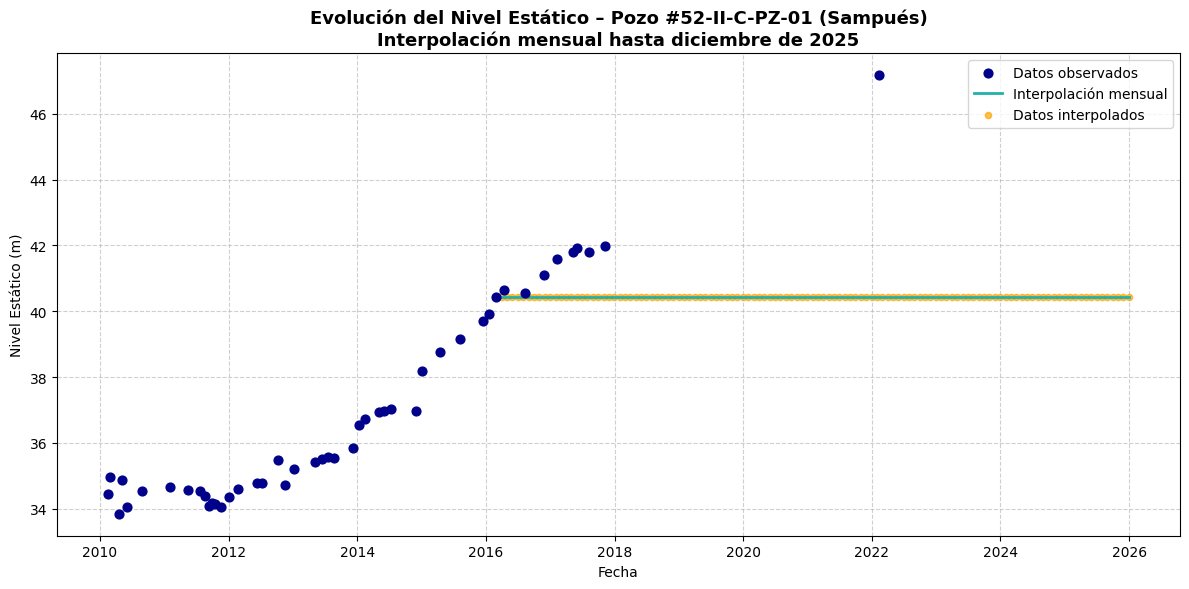

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------
# 1️⃣ Datos originales del pozo #52-II-C-PZ-01
# -----------------------------------------------
data = {
    'Fecha': [
        '15/02/2010','26/02/2010','19/04/2010','07/05/2010','02/06/2010','27/08/2010',
        '01/02/2011','16/05/2011','21/07/2011','22/08/2011','14/09/2011','28/09/2011',
        '18/10/2011','17/11/2011','03/01/2012','24/02/2012','13/06/2012','08/07/2012',
        '09/10/2012','15/11/2012','04/01/2013','07/05/2013','12/06/2013','16/07/2013',
        '20/08/2013','09/12/2013','08/01/2014','13/02/2014','05/05/2014','03/06/2014',
        '10/07/2014','03/12/2014','16/04/2015','05/01/2015','05/08/2015','15/12/2015',
        '18/01/2016','29/02/2016','11/04/2016','09/08/2016','28/11/2016','08/02/2017',
        '10/05/2017','01/06/2017','08/08/2017','09/11/2017','08/02/2022'
    ],
    'Nivel_Estatico_m': [
        34.45,34.98,33.85,34.87,34.07,34.55,
        34.65,34.57,34.54,34.39,34.10,34.19,
        34.15,34.05,34.35,34.60,34.80,34.80,
        35.49,34.72,35.20,35.43,35.50,35.58,
        35.55,35.85,36.54,36.72,36.95,36.98,
        37.03,36.98,38.76,38.19,39.17,39.69,
        39.93,40.42,40.65,40.57,41.10,41.59,
        41.79,41.93,41.80,41.99,47.17
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')
df = df.sort_values('Fecha').set_index('Fecha')

# -----------------------------------------------
# 2️⃣ Interpolación mensual hasta diciembre de 2025
# -----------------------------------------------
# Crear rango mensual completo hasta 12/2025
fechas_ext = pd.date_range(start=df.index.min(), end='2025-12-31', freq='M')

# Reindexar e interpolar linealmente
df_ext = df.reindex(fechas_ext)
df_ext['Nivel_Estatico_m'] = df_ext['Nivel_Estatico_m'].interpolate(method='linear')

# -----------------------------------------------
# 3️⃣ Graficar datos originales vs. interpolados
# -----------------------------------------------
plt.figure(figsize=(12,6))

# Datos originales
plt.scatter(df.index, df['Nivel_Estatico_m'], color='darkblue', label='Datos observados', s=40, zorder=3)

# Datos interpolados
plt.plot(df_ext.index, df_ext['Nivel_Estatico_m'], color='lightseagreen', linewidth=2, label='Interpolación mensual')
plt.scatter(df_ext.index.difference(df.index), df_ext.loc[df_ext.index.difference(df.index), 'Nivel_Estatico_m'],
            color='orange', s=20, alpha=0.7, label='Datos interpolados')

# Personalización del gráfico
plt.title('Evolución del Nivel Estático – Pozo #52-II-C-PZ-01 (Sampués)\nInterpolación mensual hasta diciembre de 2025',
          fontsize=13, weight='bold')
plt.xlabel('Fecha')
plt.ylabel('Nivel Estático (m)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


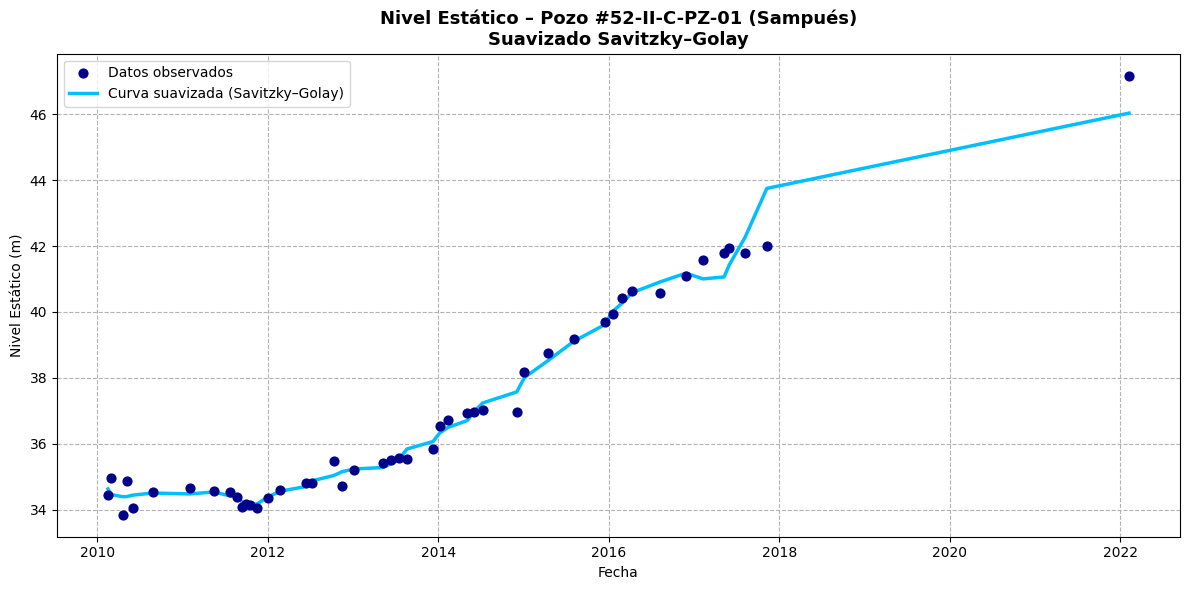

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# -----------------------------------------------
# 1️⃣ Datos originales del pozo #52-II-C-PZ-01
# -----------------------------------------------
data = {
    'Fecha': [
        '15/02/2010','26/02/2010','19/04/2010','07/05/2010','02/06/2010','27/08/2010',
        '01/02/2011','16/05/2011','21/07/2011','22/08/2011','14/09/2011','28/09/2011',
        '18/10/2011','17/11/2011','03/01/2012','24/02/2012','13/06/2012','08/07/2012',
        '09/10/2012','15/11/2012','04/01/2013','07/05/2013','12/06/2013','16/07/2013',
        '20/08/2013','09/12/2013','08/01/2014','13/02/2014','05/05/2014','03/06/2014',
        '10/07/2014','03/12/2014','16/04/2015','05/01/2015','05/08/2015','15/12/2015',
        '18/01/2016','29/02/2016','11/04/2016','09/08/2016','28/11/2016','08/02/2017',
        '10/05/2017','01/06/2017','08/08/2017','09/11/2017','08/02/2022'
    ],
    'Nivel_Estatico_m': [
        34.45,34.98,33.85,34.87,34.07,34.55,
        34.65,34.57,34.54,34.39,34.10,34.19,
        34.15,34.05,34.35,34.60,34.80,34.80,
        35.49,34.72,35.20,35.43,35.50,35.58,
        35.55,35.85,36.54,36.72,36.95,36.98,
        37.03,36.98,38.76,38.19,39.17,39.69,
        39.93,40.42,40.65,40.57,41.10,41.59,
        41.79,41.93,41.80,41.99,47.17
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')
df = df.sort_values('Fecha')

# -----------------------------------------------
# 2️⃣ Aplicar suavizado Savitzky–Golay
# -----------------------------------------------
# Definir ventana y orden (ajusta según densidad de datos)
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)  # ventana impar
poly = 3
df['Suavizado'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=poly)

# -----------------------------------------------
# 3️⃣ Graficar
# -----------------------------------------------
plt.figure(figsize=(12,6))
plt.scatter(df['Fecha'], df['Nivel_Estatico_m'], color='darkblue', s=40, label='Datos observados', zorder=3)
plt.plot(df['Fecha'], df['Suavizado'], color='deepskyblue', linewidth=2.5, label='Curva suavizada (Savitzky–Golay)')

plt.title('Nivel Estático – Pozo #52-II-C-PZ-01 (Sampués)\nSuavizado Savitzky–Golay', fontsize=13, weight='bold')
plt.xlabel('Fecha')
plt.ylabel('Nivel Estático (m)')
plt.grid(True, linestyle='--', alpha=0.96)
plt.legend()
plt.tight_layout()
plt.show()


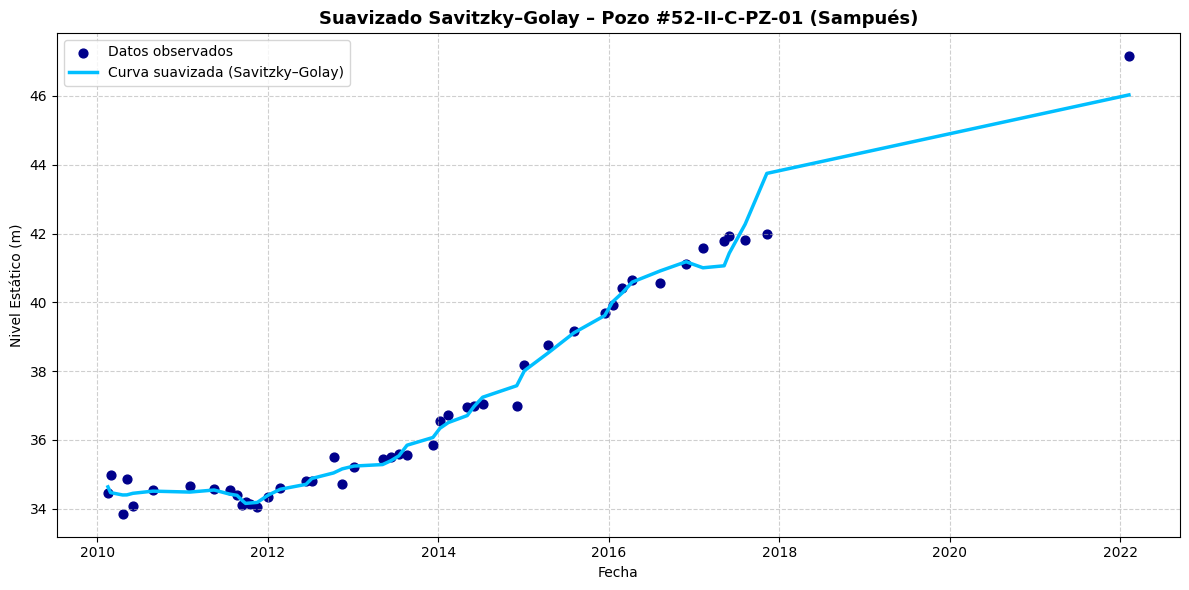

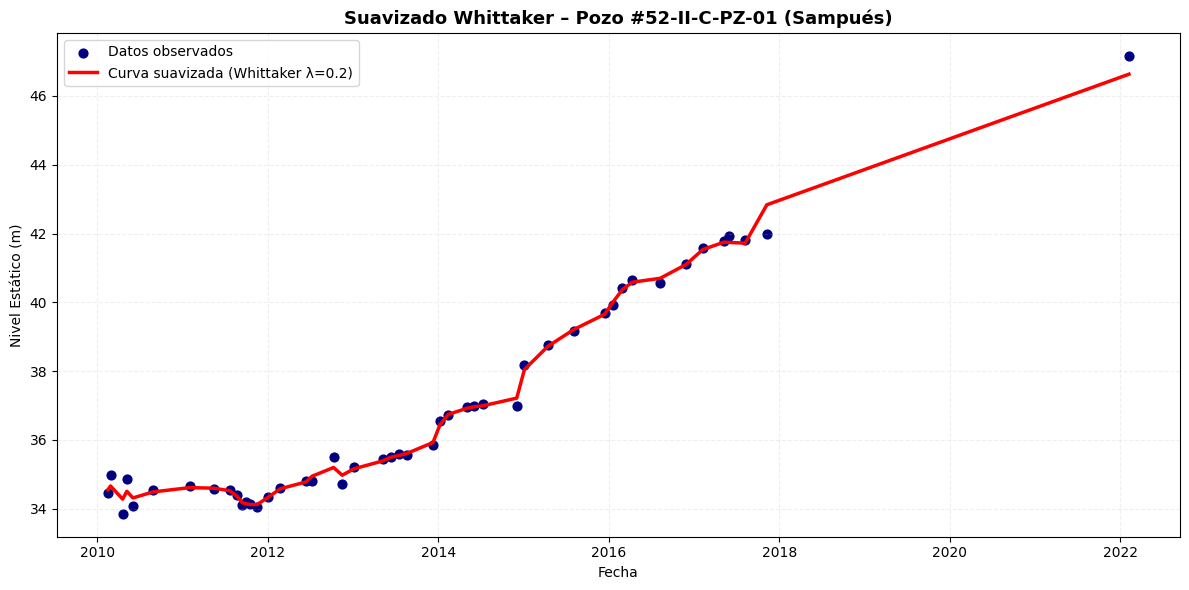

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve

# ==============================================================
# 1️⃣ Datos originales del pozo #52-II-C-PZ-01 (Sampués)
# ==============================================================
data = {
    'Fecha': [
        '15/02/2010','26/02/2010','19/04/2010','07/05/2010','02/06/2010','27/08/2010',
        '01/02/2011','16/05/2011','21/07/2011','22/08/2011','14/09/2011','28/09/2011',
        '18/10/2011','17/11/2011','03/01/2012','24/02/2012','13/06/2012','08/07/2012',
        '09/10/2012','15/11/2012','04/01/2013','07/05/2013','12/06/2013','16/07/2013',
        '20/08/2013','09/12/2013','08/01/2014','13/02/2014','05/05/2014','03/06/2014',
        '10/07/2014','03/12/2014','16/04/2015','05/01/2015','05/08/2015','15/12/2015',
        '18/01/2016','29/02/2016','11/04/2016','09/08/2016','28/11/2016','08/02/2017',
        '10/05/2017','01/06/2017','08/08/2017','09/11/2017','08/02/2022'
    ],
    'Nivel_Estatico_m': [
        34.45,34.98,33.85,34.87,34.07,34.55,
        34.65,34.57,34.54,34.39,34.10,34.19,
        34.15,34.05,34.35,34.60,34.80,34.80,
        35.49,34.72,35.20,35.43,35.50,35.58,
        35.55,35.85,36.54,36.72,36.95,36.98,
        37.03,36.98,38.76,38.19,39.17,39.69,
        39.93,40.42,40.65,40.57,41.10,41.59,
        41.79,41.93,41.80,41.99,47.17
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')
df = df.sort_values('Fecha').reset_index(drop=True)

# ==============================================================
# 2️⃣ Suavizado Savitzky–Golay
# ==============================================================
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
poly = 3
df['Savitzky_Golay'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=poly)

plt.figure(figsize=(12,6))
plt.scatter(df['Fecha'], df['Nivel_Estatico_m'], color='darkblue', s=40, label='Datos observados')
plt.plot(df['Fecha'], df['Savitzky_Golay'], color='deepskyblue', linewidth=2.5,
         label='Curva suavizada (Savitzky–Golay)')
plt.title('Suavizado Savitzky–Golay – Pozo #52-II-C-PZ-01 (Sampués)', fontsize=13, weight='bold')
plt.xlabel('Fecha')
plt.ylabel('Nivel Estático (m)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# ==============================================================
# 3️⃣ Suavizado Whittaker
# ==============================================================

def whittaker_smooth(y, lmbd, differences=2):
    """
    Suavizado Whittaker.
    y: serie de valores
    lmbd: parámetro de suavización (10^2 a 10^5)
    differences: orden de penalización
    """
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

lambda_value = 0.2  # ajuste
df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'].values, lmbd=lambda_value)

plt.figure(figsize=(12,6))
plt.scatter(df['Fecha'], df['Nivel_Estatico_m'], color='navy', s=40, label='Datos observados')
plt.plot(df['Fecha'], df['Whittaker'], color='red', linewidth=2.5,
         label='Curva suavizada (Whittaker λ={})'.format(lambda_value))
plt.title('Suavizado Whittaker – Pozo #52-II-C-PZ-01 (Sampués)', fontsize=13, weight='bold')
plt.xlabel('Fecha')
plt.ylabel('Nivel Estático (m)')
plt.grid(True, linestyle='--', alpha=0.196)
plt.legend()
plt.tight_layout()
plt.show()


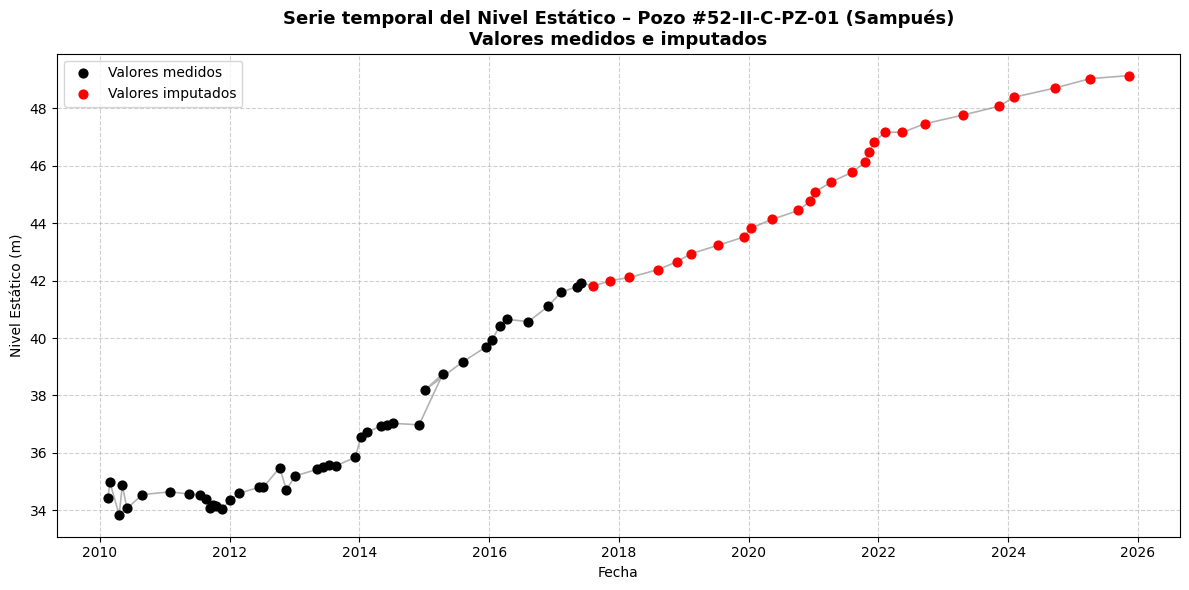

In [5]:
#Imputación para Datos 2025

import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------
# 1️⃣ Datos del pozo con imputación (Sampués – #52-II-C-PZ-01)
# -----------------------------------------------
data = {
    'Fecha': [
        '15/02/2010','26/02/2010','19/04/2010','07/05/2010','02/06/2010','27/08/2010',
        '01/02/2011','16/05/2011','21/07/2011','22/08/2011','14/09/2011','28/09/2011',
        '18/10/2011','17/11/2011','03/01/2012','24/02/2012','13/06/2012','08/07/2012',
        '09/10/2012','15/11/2012','04/01/2013','07/05/2013','12/06/2013','16/07/2013',
        '20/08/2013','09/12/2013','08/01/2014','13/02/2014','05/05/2014','03/06/2014',
        '10/07/2014','03/12/2014','16/04/2015','05/01/2015','05/08/2015','15/12/2015',
        '18/01/2016','29/02/2016','11/04/2016','09/08/2016','28/11/2016','08/02/2017',
        '10/05/2017','01/06/2017','08/08/2017','09/11/2017',
        # 🔴 Datos imputados a partir de aquí
        '01/03/2018','08/08/2018','23/11/2018','12/02/2019','11/07/2019','07/12/2019',
        '12/01/2020','11/05/2020','07/10/2020','12/12/2020','11/01/2021','07/04/2021',
        '03/08/2021','17/10/2021','07/11/2021','09/12/2021','08/02/2022','16/05/2022',
        '17/09/2022','22/04/2023','11/11/2023','05/02/2024','22/09/2024','06/04/2025','11/11/2025'
    ],
    'Nivel_Estatico_m': [
        34.45,34.98,33.85,34.87,34.07,34.55,34.65,34.57,34.54,34.39,34.10,34.19,34.15,34.05,
        34.35,34.60,34.80,34.80,35.49,34.72,35.20,35.43,35.50,35.58,35.55,35.85,36.54,36.72,
        36.95,36.98,37.03,36.98,38.76,38.19,39.17,39.69,39.93,40.42,40.65,40.57,41.10,41.59,
        41.79,41.93,41.80,41.99,
        # 🔴 Imputados
        42.107111,42.37704237,42.65289932,42.93477741,43.22277417,43.51698905,43.81752341,
        44.1244806,44.43796586,44.7580864,45.08495134,45.41867175,45.75936065,46.10713297,
        46.4621056,46.82439736,47.17,47.15234246,47.45189065,47.75630129,48.06563814,
        48.37996574,48.69934942,49.02385527,49.13
    ]
}

# -----------------------------------------------
# 2️⃣ Crear DataFrame y clasificar observados/imputados
# -----------------------------------------------
df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')
df['Imputado'] = False
df.loc[df.index >= 44, 'Imputado'] = True  # a partir del índice 44 son imputados (ajustar según tus datos)

# -----------------------------------------------
# 3️⃣ Graficar valores medidos vs imputados
# -----------------------------------------------
plt.figure(figsize=(12,6))

# Medidos en negro
plt.scatter(df.loc[~df['Imputado'], 'Fecha'], df.loc[~df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=40, label='Valores medidos', zorder=3)

# Imputados en rojo
plt.scatter(df.loc[df['Imputado'], 'Fecha'], df.loc[df['Imputado'], 'Nivel_Estatico_m'],
            color='red', s=40, label='Valores imputados', zorder=3)

# Curva de tendencia
plt.plot(df['Fecha'], df['Nivel_Estatico_m'], color='gray', linewidth=1.2, alpha=0.6)

# Personalización
plt.title('Serie temporal del Nivel Estático – Pozo #52-II-C-PZ-01 (Sampués)\nValores medidos e imputados',
          fontsize=13, weight='bold')
plt.xlabel('Fecha')
plt.ylabel('Nivel Estático (m)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


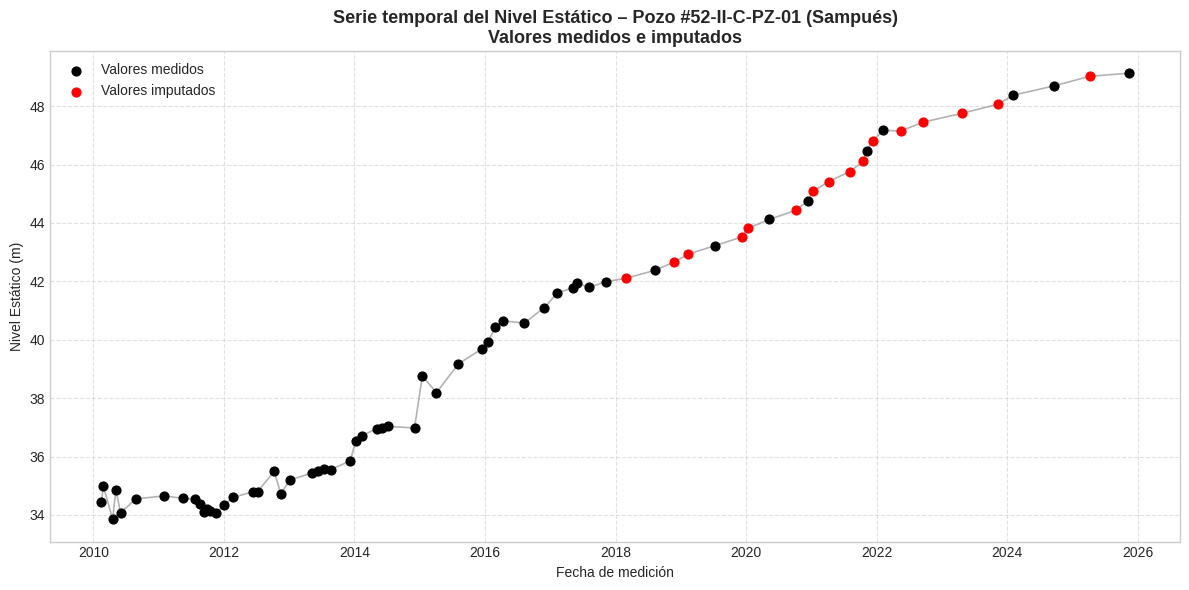

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------
# 1️⃣ Datos del pozo #52-II-C-PZ-01 (Sampués)
# -----------------------------------------------
data = {
    'Fecha': [
        '15/02/2010','26/02/2010','19/04/2010','07/05/2010','02/06/2010','27/08/2010',
        '01/02/2011','16/05/2011','21/07/2011','22/08/2011','14/09/2011','28/09/2011',
        '18/10/2011','17/11/2011','03/01/2012','24/02/2012','13/06/2012','08/07/2012',
        '09/10/2012','15/11/2012','04/01/2013','07/05/2013','12/06/2013','16/07/2013',
        '20/08/2013','09/12/2013','08/01/2014','13/02/2014','05/05/2014','03/06/2014',
        '10/07/2014','03/12/2014','16/01/2015','05/04/2015','05/08/2015','15/12/2015',
        '18/01/2016','29/02/2016','11/04/2016','09/08/2016','28/11/2016','08/02/2017',
        '10/05/2017','01/06/2017','08/08/2017','09/11/2017','01/03/2018','08/08/2018',
        '23/11/2018','12/02/2019','11/07/2019','07/12/2019','12/01/2020','11/05/2020',
        '07/10/2020','12/12/2020','11/01/2021','07/04/2021','03/08/2021','17/10/2021',
        '07/11/2021','09/12/2021','08/02/2022','16/05/2022','17/09/2022','22/04/2023',
        '11/11/2023','05/02/2024','22/09/2024','06/04/2025','11/11/2025'
    ],
    'Nivel_Estatico_m': [
        34.45,34.98,33.85,34.87,34.07,34.55,34.65,34.57,34.54,34.39,34.10,34.19,34.15,
        34.05,34.35,34.60,34.80,34.80,35.49,34.72,35.20,35.43,35.50,35.58,35.55,35.85,
        36.54,36.72,36.95,36.98,37.03,36.98,38.76,38.19,39.17,39.69,39.93,40.42,40.65,
        40.57,41.10,41.59,41.79,41.93,41.80,41.99,42.107111,42.37704237,42.65289932,
        42.93477741,43.22277417,43.51698905,43.81752341,44.1244806,44.43796586,
        44.7580864,45.08495134,45.41867175,45.75936065,46.10713297,46.4621056,
        46.82439736,47.17,47.15234246,47.45189065,47.75630129,48.06563814,48.37996574,
        48.69934942,49.02385527,49.13
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Clasificar datos imputados
# -----------------------------------------------
# Fechas imputadas según aclaración del usuario
fechas_imputadas = [
    '01/03/2018','23/11/2018','12/02/2019','07/12/2019',
    '12/01/2020','07/10/2020','11/01/2021','07/04/2021',
    '03/08/2021','17/10/2021','09/12/2021','16/05/2022',
    '17/09/2022','22/04/2023','11/11/2023','06/04/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')

df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# -----------------------------------------------
# 3️⃣ Graficar (puntos negros = medidos, rojos = imputados)
# -----------------------------------------------
plt.figure(figsize=(12,6))

# Puntos medidos (negros)
plt.scatter(df.loc[~df['Imputado'], 'Fecha'],
            df.loc[~df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=40, label='Valores medidos', zorder=3)

# Puntos imputados (rojos)
plt.scatter(df.loc[df['Imputado'], 'Fecha'],
            df.loc[df['Imputado'], 'Nivel_Estatico_m'],
            color='red', s=40, label='Valores imputados', zorder=3)

#plt.style.use('seaborn-v0_8-whitegrid')
#plt.xticks(rotation=45)
#plt.tight_layout()


# Línea de conexión general
plt.plot(df['Fecha'], df['Nivel_Estatico_m'], color='gray', linewidth=1.2, alpha=0.6)

# Personalización
plt.title('Serie temporal del Nivel Estático – Pozo #52-II-C-PZ-01 (Sampués)\nValores medidos e imputados',
          fontsize=13, weight='bold')
plt.xlabel('Fecha de medición')
plt.ylabel('Nivel Estático (m)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


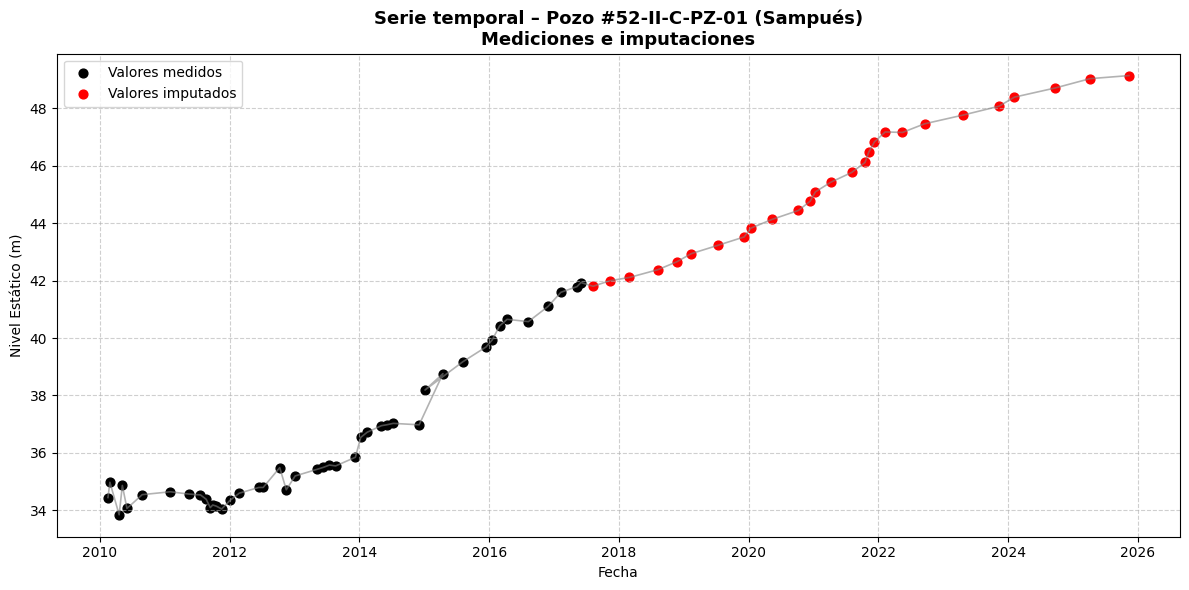

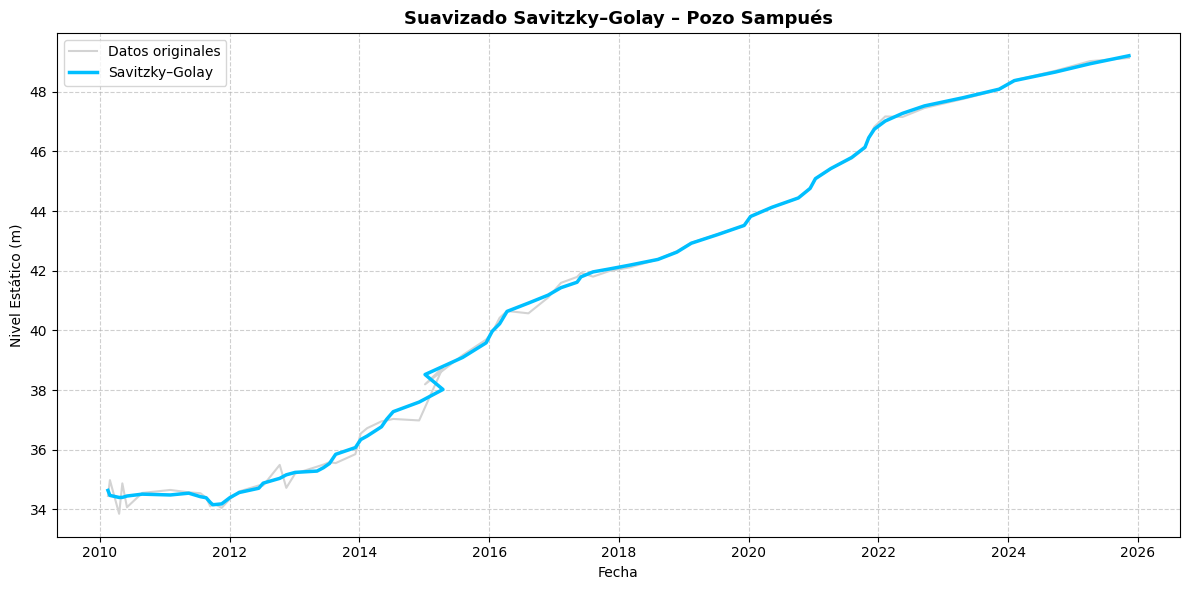

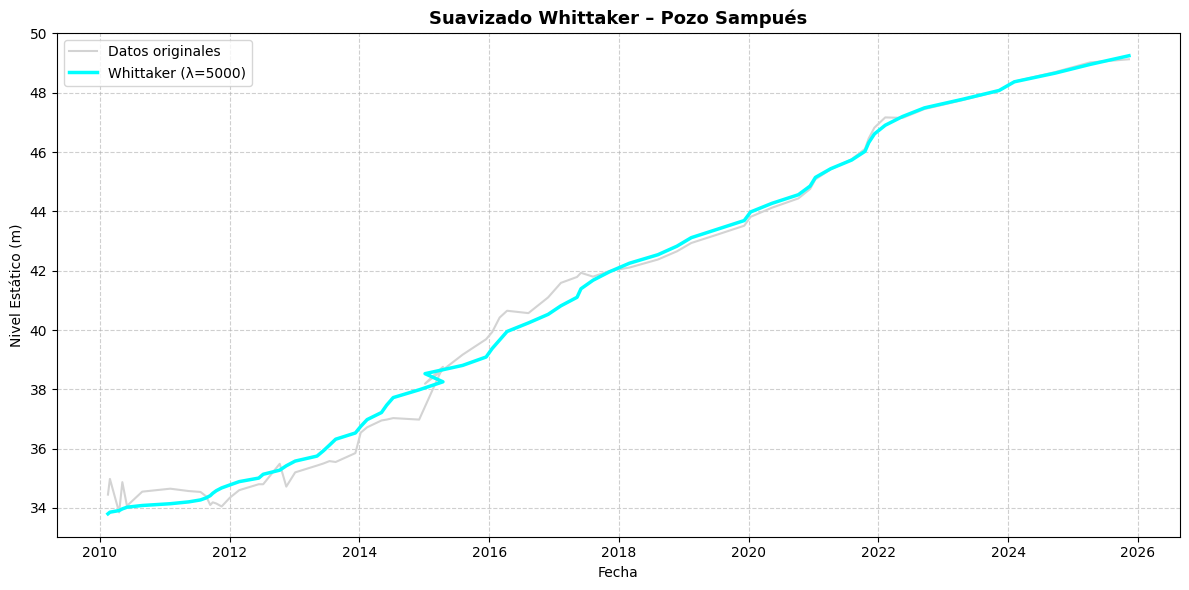

/tmp/ipython-input-3183521372.py:113: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_pred = df.set_index('Fecha').resample('M').mean().interpolate()
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/tmp/ipython-input-3183521372.py:147: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=df_pred.index[-1]+pd.offsets.MonthEnd(1),


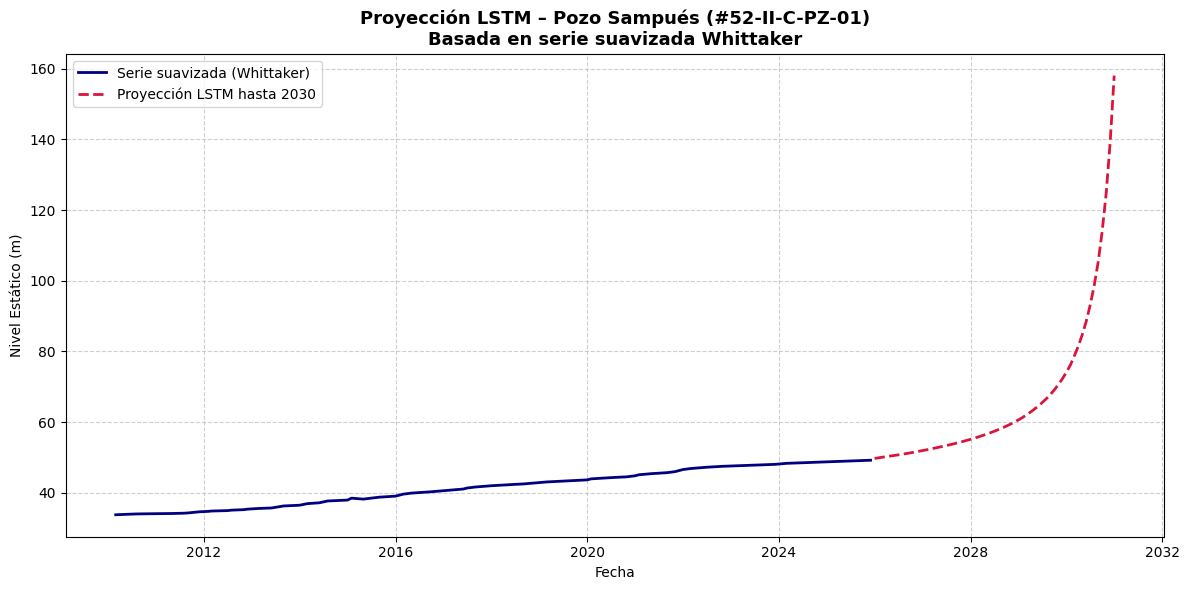

In [ ]:
# ======================================================
# Serie temporal con imputación + suavizado + predicción
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -----------------------------------------------
# 1️⃣ Datos del pozo con imputación (Sampués – #52-II-C-PZ-01)
# -----------------------------------------------
data = {
    'Fecha': [
        '15/02/2010','26/02/2010','19/04/2010','07/05/2010','02/06/2010','27/08/2010',
        '01/02/2011','16/05/2011','21/07/2011','22/08/2011','14/09/2011','28/09/2011',
        '18/10/2011','17/11/2011','03/01/2012','24/02/2012','13/06/2012','08/07/2012',
        '09/10/2012','15/11/2012','04/01/2013','07/05/2013','12/06/2013','16/07/2013',
        '20/08/2013','09/12/2013','08/01/2014','13/02/2014','05/05/2014','03/06/2014',
        '10/07/2014','03/12/2014','16/04/2015','05/01/2015','05/08/2015','15/12/2015',
        '18/01/2016','29/02/2016','11/04/2016','09/08/2016','28/11/2016','08/02/2017',
        '10/05/2017','01/06/2017','08/08/2017','09/11/2017',
        # 🔴 Datos imputados a partir de aquí
        '01/03/2018','08/08/2018','23/11/2018','12/02/2019','11/07/2019','07/12/2019',
        '12/01/2020','11/05/2020','07/10/2020','12/12/2020','11/01/2021','07/04/2021',
        '03/08/2021','17/10/2021','07/11/2021','09/12/2021','08/02/2022','16/05/2022',
        '17/09/2022','22/04/2023','11/11/2023','05/02/2024','22/09/2024','06/04/2025','11/11/2025'
    ],
    'Nivel_Estatico_m': [
        34.45,34.98,33.85,34.87,34.07,34.55,34.65,34.57,34.54,34.39,34.10,34.19,34.15,34.05,
        34.35,34.60,34.80,34.80,35.49,34.72,35.20,35.43,35.50,35.58,35.55,35.85,36.54,36.72,
        36.95,36.98,37.03,36.98,38.76,38.19,39.17,39.69,39.93,40.42,40.65,40.57,41.10,41.59,
        41.79,41.93,41.80,41.99,
        # 🔴 Imputados
        42.107111,42.37704237,42.65289932,42.93477741,43.22277417,43.51698905,43.81752341,
        44.1244806,44.43796586,44.7580864,45.08495134,45.41867175,45.75936065,46.10713297,
        46.4621056,46.82439736,47.17,47.15234246,47.45189065,47.75630129,48.06563814,
        48.37996574,48.69934942,49.02385527,49.13
    ]
}

# -----------------------------------------------
# 2️⃣ Crear DataFrame y clasificar observados/imputados
# -----------------------------------------------
df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')
df['Imputado'] = False
df.loc[df.index >= 44, 'Imputado'] = True  # índice a partir del cual son imputados

# -----------------------------------------------
# 3️⃣ Gráfico base: medidos (negros) e imputados (rojos)
# -----------------------------------------------
plt.figure(figsize=(12,6))
plt.scatter(df.loc[~df['Imputado'], 'Fecha'], df.loc[~df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=40, label='Valores medidos')
plt.scatter(df.loc[df['Imputado'], 'Fecha'], df.loc[df['Imputado'], 'Nivel_Estatico_m'],
            color='red', s=40, label='Valores imputados')
plt.plot(df['Fecha'], df['Nivel_Estatico_m'], color='gray', linewidth=1.2, alpha=0.6)
plt.title('Serie temporal – Pozo #52-II-C-PZ-01 (Sampués)\nMediciones e imputaciones', fontsize=13, weight='bold')
plt.xlabel('Fecha')
plt.ylabel('Nivel Estático (m)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================================
# 4️⃣ Suavizados: Savitzky–Golay y Whittaker
# ==========================================================
# Savitzky–Golay
from scipy.signal import savgol_filter
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

# Whittaker smoother
def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=5000)

# --- Plot Savitzky
plt.figure(figsize=(12,6))
plt.plot(df['Fecha'], df['Nivel_Estatico_m'], color='lightgray', label='Datos originales')
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2.5, label='Savitzky–Golay')
plt.title('Suavizado Savitzky–Golay – Pozo Sampués', fontsize=13, weight='bold')
plt.xlabel('Fecha'); plt.ylabel('Nivel Estático (m)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()

# --- Plot Whittaker
plt.figure(figsize=(12,6))
plt.plot(df['Fecha'], df['Nivel_Estatico_m'], color='lightgray', label='Datos originales')
plt.plot(df['Fecha'], df['Whittaker'], color='aqua', linewidth=2.5, label='Whittaker (λ=5000)')
plt.title('Suavizado Whittaker – Pozo Sampués', fontsize=13, weight='bold')
plt.xlabel('Fecha'); plt.ylabel('Nivel Estático (m)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()

# ==========================================================
# 5️⃣ Predicción LSTM (serie suavizada con Whittaker)
# ==========================================================
df_pred = df.set_index('Fecha').resample('M').mean().interpolate()
scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(df_pred[['Whittaker']])

def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = Sequential([
    LSTM(64, activation='relu', input_shape=(window,1)),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=300, batch_size=8, verbose=0)

# Proyección hasta 2030
pred_steps = (2030 - df_pred.index[-1].year)*12 + (12 - df_pred.index[-1].month)
last_seq = scaled[-window:]
preds = []
for _ in range(pred_steps):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    last_seq = np.append(last_seq[1:], pred)[-window:]

future_dates = pd.date_range(start=df_pred.index[-1]+pd.offsets.MonthEnd(1),
                             periods=pred_steps, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

plt.figure(figsize=(12,6))
plt.plot(df_pred.index, df_pred['Whittaker'], color='navy', linewidth=2, label='Serie suavizada (Whittaker)')
plt.plot(future_df['Fecha'], future_df['Nivel_Predicho'], color='crimson', linestyle='--', linewidth=2,
         label='Proyección LSTM hasta 2030')
plt.title('Proyección LSTM – Pozo Sampués (#52-II-C-PZ-01)\nBasada en serie suavizada Whittaker',
          fontsize=13, weight='bold')
plt.xlabel('Fecha'); plt.ylabel('Nivel Estático (m)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()


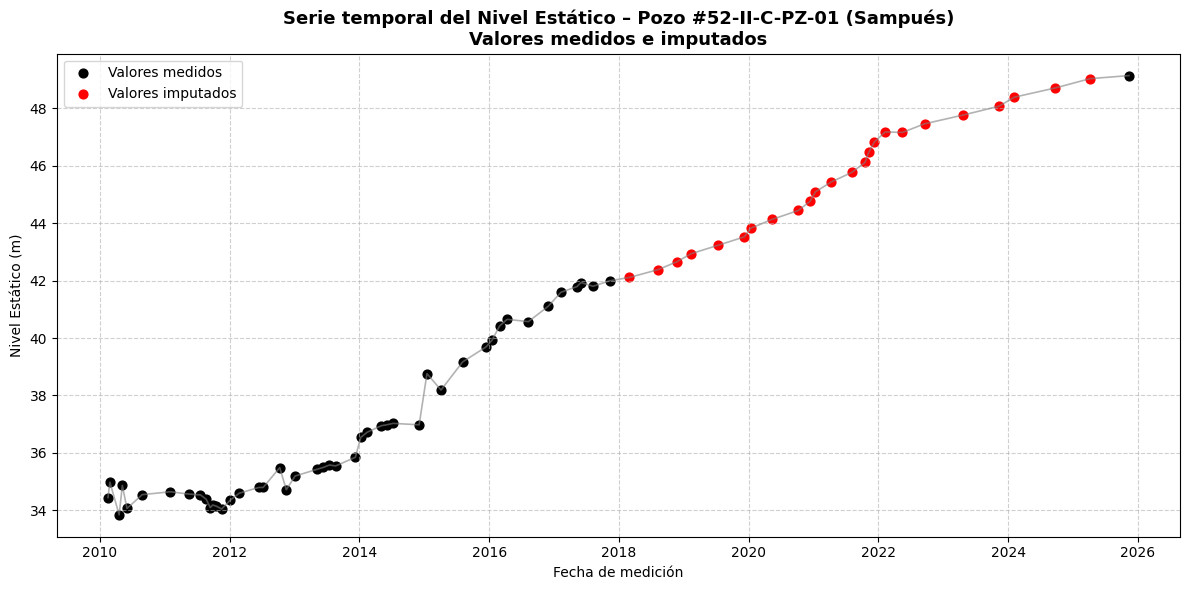

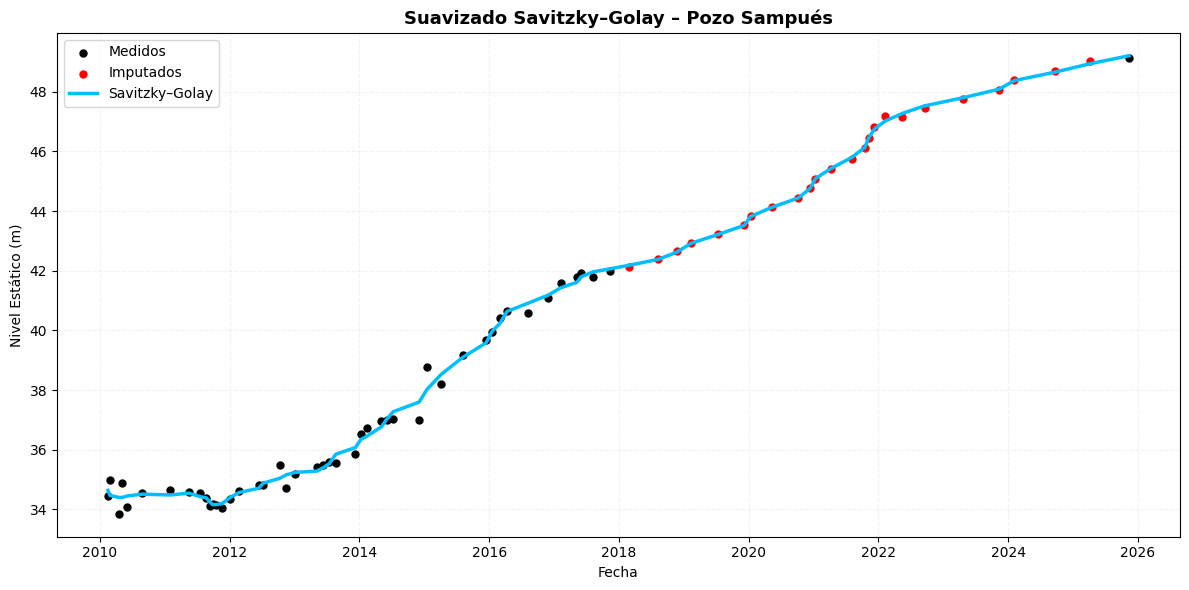

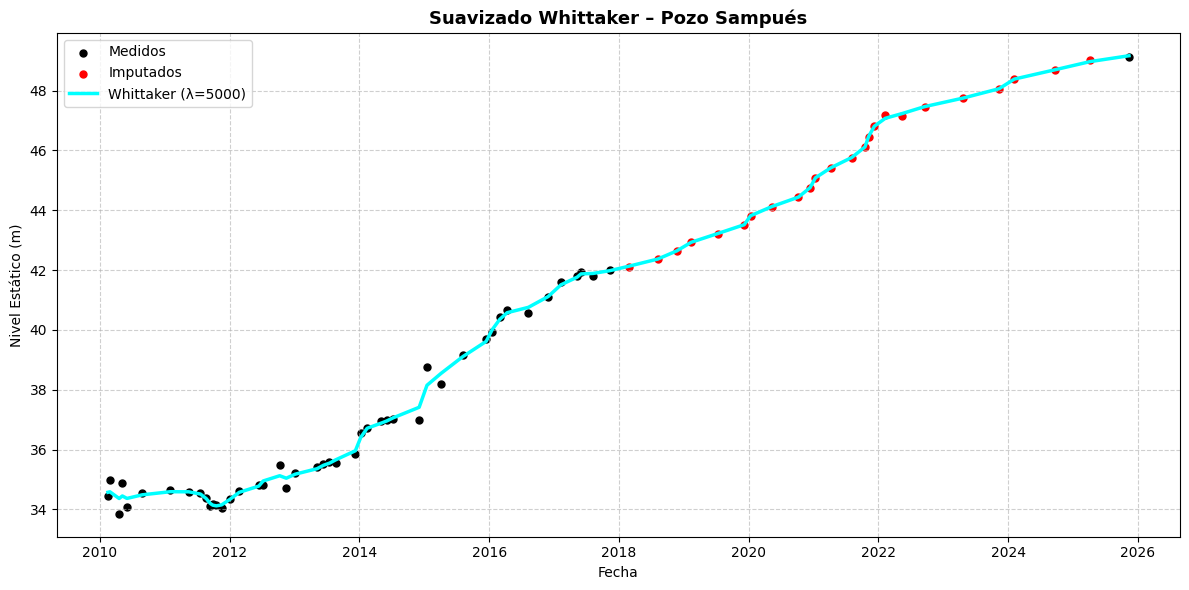

/tmp/ipython-input-2418950269.py:123: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_pred = df.set_index('Fecha').resample('M').mean().interpolate()
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/tmp/ipython-input-2418950269.py:157: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=df_pred.index[-1]+pd.offsets.MonthEnd(1),


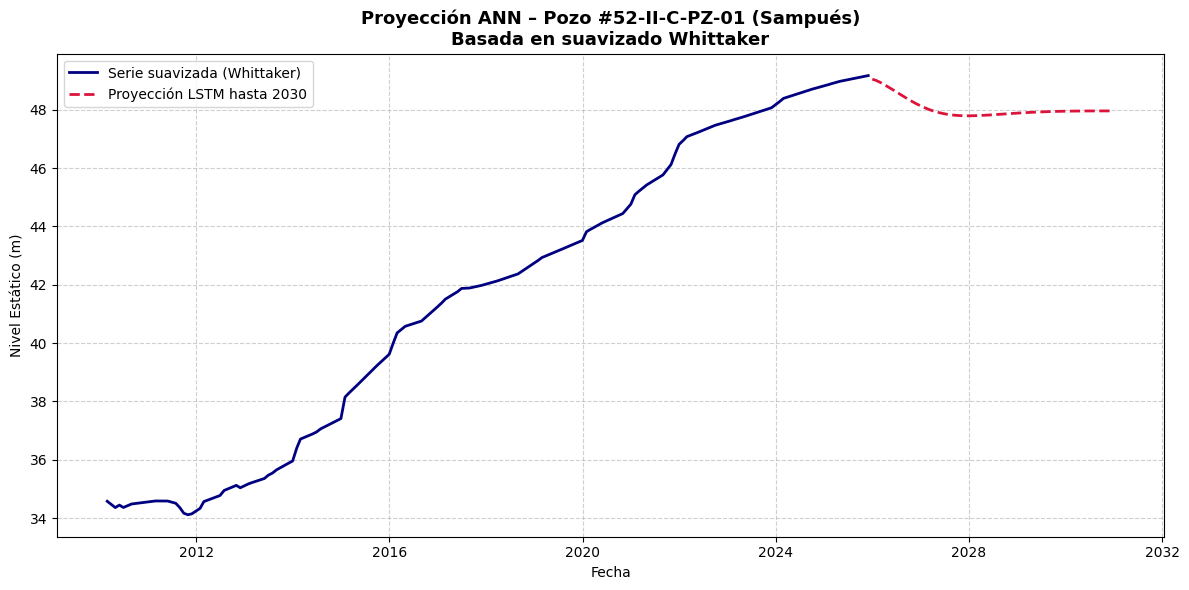

In [ ]:
# ======================================================
# Serie temporal con imputación + suavizado + ANN
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -----------------------------------------------
# 1️⃣ Datos del pozo #52-II-C-PZ-01 (Sampués)
# -----------------------------------------------
data = {
    'Fecha': [
        '15/02/2010','26/02/2010','19/04/2010','07/05/2010','02/06/2010','27/08/2010',
        '01/02/2011','16/05/2011','21/07/2011','22/08/2011','14/09/2011','28/09/2011',
        '18/10/2011','17/11/2011','03/01/2012','24/02/2012','13/06/2012','08/07/2012',
        '09/10/2012','15/11/2012','04/01/2013','07/05/2013','12/06/2013','16/07/2013',
        '20/08/2013','09/12/2013','08/01/2014','13/02/2014','05/05/2014','03/06/2014',
        '10/07/2014','03/12/2014','16/01/2015','05/04/2015','05/08/2015','15/12/2015',
        '18/01/2016','29/02/2016','11/04/2016','09/08/2016','28/11/2016','08/02/2017',
        '10/05/2017','01/06/2017','08/08/2017','09/11/2017','01/03/2018','08/08/2018',
        '23/11/2018','12/02/2019','11/07/2019','07/12/2019','12/01/2020','11/05/2020',
        '07/10/2020','12/12/2020','11/01/2021','07/04/2021','03/08/2021','17/10/2021',
        '07/11/2021','09/12/2021','08/02/2022','16/05/2022','17/09/2022','22/04/2023',
        '11/11/2023','05/02/2024','22/09/2024','06/04/2025','11/11/2025'
    ],
    'Nivel_Estatico_m': [
        34.45,34.98,33.85,34.87,34.07,34.55,34.65,34.57,34.54,34.39,34.10,34.19,34.15,
        34.05,34.35,34.60,34.80,34.80,35.49,34.72,35.20,35.43,35.50,35.58,35.55,35.85,
        36.54,36.72,36.95,36.98,37.03,36.98,38.76,38.19,39.17,39.69,39.93,40.42,40.65,
        40.57,41.10,41.59,41.79,41.93,41.80,41.99,42.107111,42.37704237,42.65289932,
        42.93477741,43.22277417,43.51698905,43.81752341,44.1244806,44.43796586,
        44.7580864,45.08495134,45.41867175,45.75936065,46.10713297,46.4621056,
        46.82439736,47.17,47.15234246,47.45189065,47.75630129,48.06563814,48.37996574,
        48.69934942,49.02385527,49.13
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Clasificar datos imputados
# -----------------------------------------------
fechas_imputadas = [
    '01/03/2018','08/08/2018','23/11/2018','12/02/2019','11/07/2019','07/12/2019',
    '12/01/2020','11/05/2020','07/10/2020','12/12/2020','11/01/2021','07/04/2021',
    '03/08/2021','17/10/2021','07/11/2021','09/12/2021','08/02/2022','16/05/2022',
    '17/09/2022','22/04/2023','11/11/2023','05/02/2024','22/09/2024','06/04/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# -----------------------------------------------
# 3️⃣ Gráfico base: medidos (negros) e imputados (rojos)
# -----------------------------------------------
plt.figure(figsize=(12,6))
plt.scatter(df.loc[~df['Imputado'], 'Fecha'], df.loc[~df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=40, label='Valores medidos')
plt.scatter(df.loc[df['Imputado'], 'Fecha'], df.loc[df['Imputado'], 'Nivel_Estatico_m'],
            color='red', s=40, label='Valores imputados')
plt.plot(df['Fecha'], df['Nivel_Estatico_m'], color='gray', linewidth=1.2, alpha=0.6)
plt.title('Serie temporal del Nivel Estático – Pozo #52-II-C-PZ-01 (Sampués)\nValores medidos e imputados',
          fontsize=13, weight='bold')
plt.xlabel('Fecha de medición')
plt.ylabel('Nivel Estático (m)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# ======================================================
# 4️⃣ Suavizados
# ======================================================

# --- Savitzky–Golay ---
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

plt.figure(figsize=(12,6))
plt.scatter(df.loc[~df['Imputado'], 'Fecha'], df.loc[~df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=25, label='Medidos')
plt.scatter(df.loc[df['Imputado'], 'Fecha'], df.loc[df['Imputado'], 'Nivel_Estatico_m'],
            color='red', s=25, label='Imputados')
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2.5, label='Savitzky–Golay')
plt.title('Suavizado Savitzky–Golay – Pozo Sampués', fontsize=13, weight='bold')
plt.xlabel('Fecha'); plt.ylabel('Nivel Estático (m)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.16)
plt.tight_layout(); plt.show()

# --- Whittaker ---
def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=0.5)

plt.figure(figsize=(12,6))
plt.scatter(df.loc[~df['Imputado'], 'Fecha'], df.loc[~df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=25, label='Medidos')
plt.scatter(df.loc[df['Imputado'], 'Fecha'], df.loc[df['Imputado'], 'Nivel_Estatico_m'],
            color='red', s=25, label='Imputados')
plt.plot(df['Fecha'], df['Whittaker'], color='aqua', linewidth=2.5, label='Whittaker (λ=5000)')
plt.title('Suavizado Whittaker – Pozo Sampués', fontsize=13, weight='bold')
plt.xlabel('Fecha'); plt.ylabel('Nivel Estático (m)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()

# ======================================================
# 5️⃣ Proyección con red neuronal LSTM hasta 2030
# ======================================================
df_pred = df.set_index('Fecha').resample('M').mean().interpolate()
scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(df_pred[['Whittaker']])

def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = Sequential([
    LSTM(64, activation='relu', input_shape=(window,1)),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=300, batch_size=8, verbose=0)

# --- Predicción hasta 2030 ---
pred_steps = (2030 - df_pred.index[-1].year)*12 + (12 - df_pred.index[-1].month)
last_seq = scaled[-window:]
preds = []
for _ in range(pred_steps):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    last_seq = np.append(last_seq[1:], pred)[-window:]

future_dates = pd.date_range(start=df_pred.index[-1]+pd.offsets.MonthEnd(1),
                             periods=pred_steps, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

plt.figure(figsize=(12,6))
plt.plot(df_pred.index, df_pred['Whittaker'], color='navy', linewidth=2, label='Serie suavizada (Whittaker)')
plt.plot(future_df['Fecha'], future_df['Nivel_Predicho'], color='crimson', linestyle='--', linewidth=2,
         label='Proyección LSTM hasta 2030')
plt.title('Proyección ANN – Pozo #52-II-C-PZ-01 (Sampués)\nBasada en suavizado Whittaker', fontsize=13, weight='bold')
plt.xlabel('Fecha'); plt.ylabel('Nivel Estático (m)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()


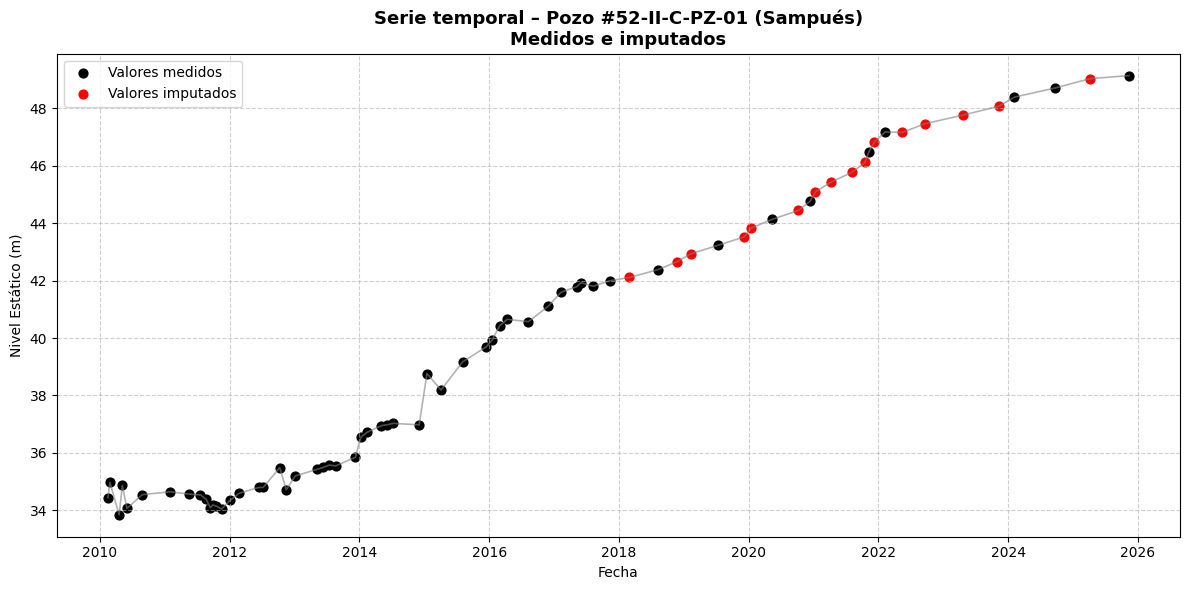

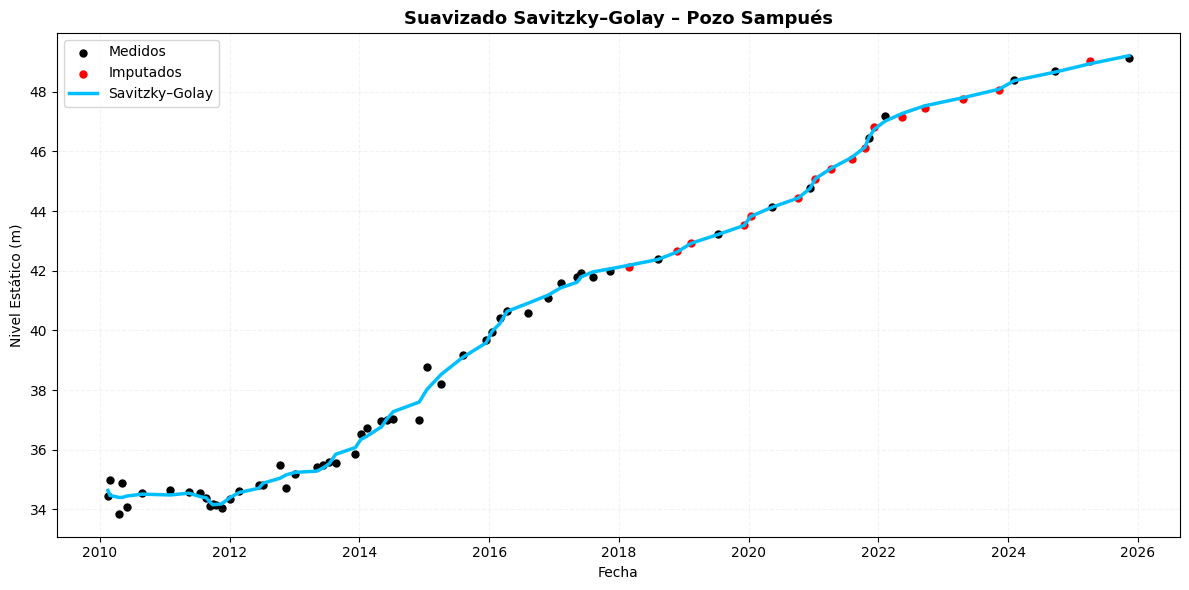

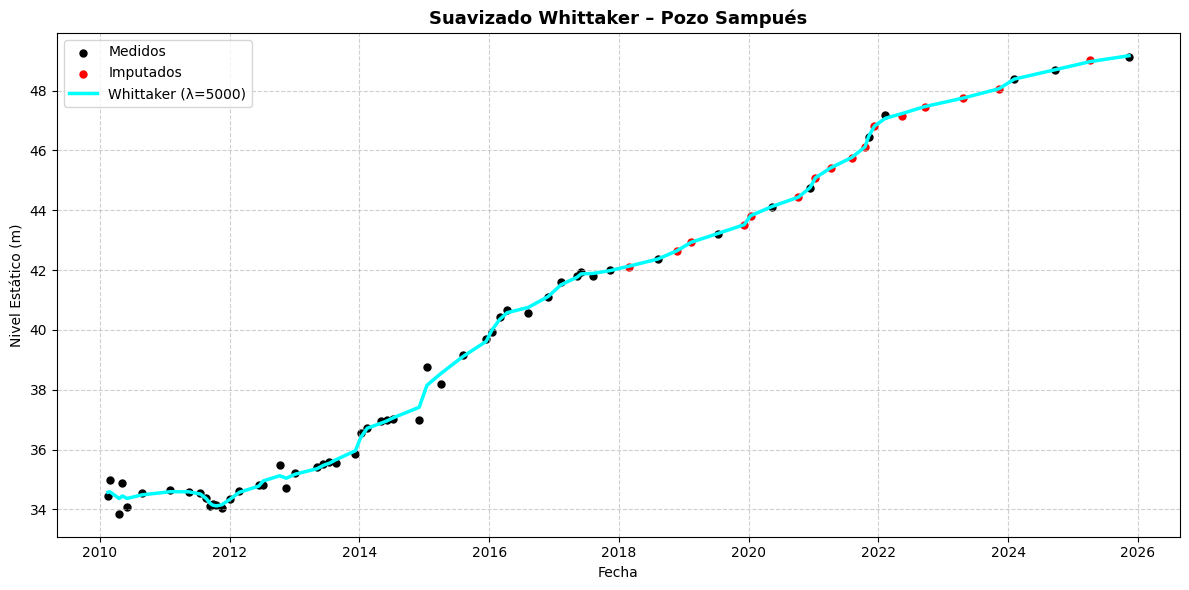

/tmp/ipython-input-2969700969.py:117: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_pred = df.set_index('Fecha').resample('M').mean().interpolate()
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/tmp/ipython-input-2969700969.py:151: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=df_pred.index[-1]+pd.offsets.MonthEnd(1),


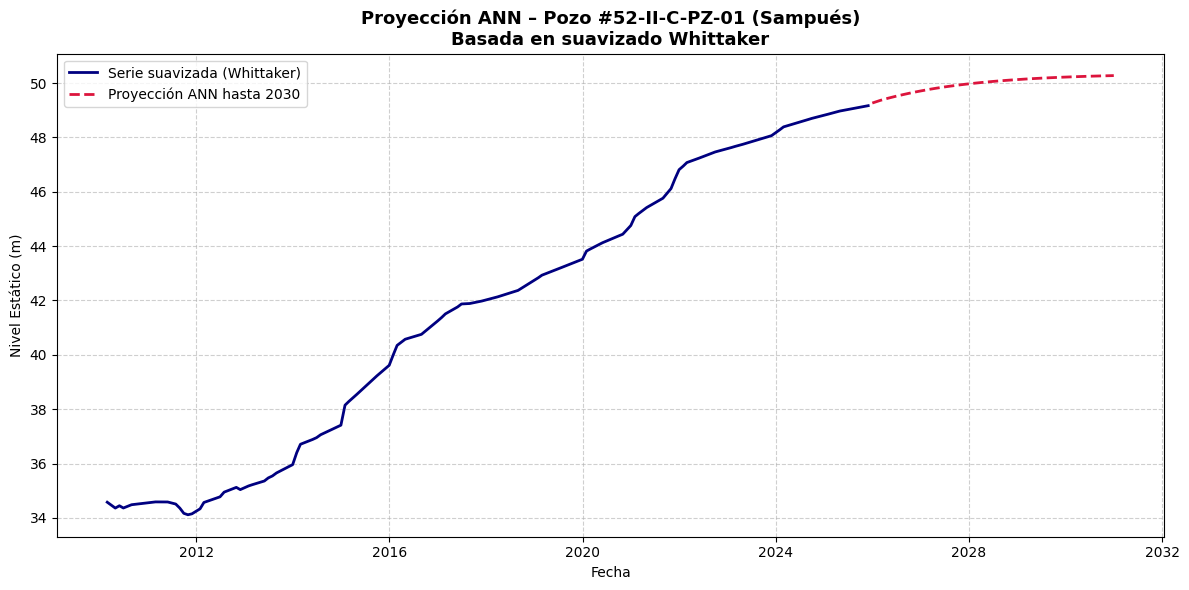

In [ ]:
# ======================================================
# Serie temporal del Pozo Sampués – Medidos, Imputados, Suavizados y Proyección ANN
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -----------------------------------------------
# 1️⃣ Datos del pozo #52-II-C-PZ-01 (Sampués)
# -----------------------------------------------
data = {
    'Fecha': [
        '15/02/2010','26/02/2010','19/04/2010','07/05/2010','02/06/2010','27/08/2010',
        '01/02/2011','16/05/2011','21/07/2011','22/08/2011','14/09/2011','28/09/2011',
        '18/10/2011','17/11/2011','03/01/2012','24/02/2012','13/06/2012','08/07/2012',
        '09/10/2012','15/11/2012','04/01/2013','07/05/2013','12/06/2013','16/07/2013',
        '20/08/2013','09/12/2013','08/01/2014','13/02/2014','05/05/2014','03/06/2014',
        '10/07/2014','03/12/2014','16/01/2015','05/04/2015','05/08/2015','15/12/2015',
        '18/01/2016','29/02/2016','11/04/2016','09/08/2016','28/11/2016','08/02/2017',
        '10/05/2017','01/06/2017','08/08/2017','09/11/2017','01/03/2018','08/08/2018',
        '23/11/2018','12/02/2019','11/07/2019','07/12/2019','12/01/2020','11/05/2020',
        '07/10/2020','12/12/2020','11/01/2021','07/04/2021','03/08/2021','17/10/2021',
        '07/11/2021','09/12/2021','08/02/2022','16/05/2022','17/09/2022','22/04/2023',
        '11/11/2023','05/02/2024','22/09/2024','06/04/2025','11/11/2025'
    ],
    'Nivel_Estatico_m': [
        34.45,34.98,33.85,34.87,34.07,34.55,34.65,34.57,34.54,34.39,34.10,34.19,34.15,
        34.05,34.35,34.60,34.80,34.80,35.49,34.72,35.20,35.43,35.50,35.58,35.55,35.85,
        36.54,36.72,36.95,36.98,37.03,36.98,38.76,38.19,39.17,39.69,39.93,40.42,40.65,
        40.57,41.10,41.59,41.79,41.93,41.80,41.99,42.107111,42.37704237,42.65289932,
        42.93477741,43.22277417,43.51698905,43.81752341,44.1244806,44.43796586,
        44.7580864,45.08495134,45.41867175,45.75936065,46.10713297,46.4621056,
        46.82439736,47.17,47.15234246,47.45189065,47.75630129,48.06563814,48.37996574,
        48.69934942,49.02385527,49.13
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Clasificar datos imputados
# -----------------------------------------------
fechas_imputadas = [
    '01/03/2018','23/11/2018','12/02/2019','07/12/2019',
    '12/01/2020','07/10/2020','11/01/2021','07/04/2021',
    '03/08/2021','17/10/2021','09/12/2021','16/05/2022',
    '17/09/2022','22/04/2023','11/11/2023','06/04/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# -----------------------------------------------
# 3️⃣ Gráfico base: medidos (negros) e imputados (rojos)
# -----------------------------------------------
plt.figure(figsize=(12,6))
plt.scatter(df.loc[~df['Imputado'], 'Fecha'], df.loc[~df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=40, label='Valores medidos')
plt.scatter(df.loc[df['Imputado'], 'Fecha'], df.loc[df['Imputado'], 'Nivel_Estatico_m'],
            color='red', s=40, label='Valores imputados')
plt.plot(df['Fecha'], df['Nivel_Estatico_m'], color='gray', linewidth=1.2, alpha=0.6)
plt.title('Serie temporal – Pozo #52-II-C-PZ-01 (Sampués)\nMedidos e imputados', fontsize=13, weight='bold')
plt.xlabel('Fecha'); plt.ylabel('Nivel Estático (m)')
plt.grid(True, linestyle='--', alpha=0.6); plt.legend(); plt.tight_layout(); plt.show()

# ======================================================
# 4️⃣ Suavizados
# ======================================================
# --- Savitzky–Golay ---
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

plt.figure(figsize=(12,6))
plt.scatter(df.loc[~df['Imputado'], 'Fecha'], df.loc[~df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=25, label='Medidos')
plt.scatter(df.loc[df['Imputado'], 'Fecha'], df.loc[df['Imputado'], 'Nivel_Estatico_m'],
            color='red', s=25, label='Imputados')
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2.5, label='Savitzky–Golay')
plt.title('Suavizado Savitzky–Golay – Pozo Sampués', fontsize=13, weight='bold')
plt.xlabel('Fecha'); plt.ylabel('Nivel Estático (m)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.16)
plt.tight_layout(); plt.show()

# --- Whittaker ---
def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=0.5000)

plt.figure(figsize=(12,6))
plt.scatter(df.loc[~df['Imputado'], 'Fecha'], df.loc[~df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=25, label='Medidos')
plt.scatter(df.loc[df['Imputado'], 'Fecha'], df.loc[df['Imputado'], 'Nivel_Estatico_m'],
            color='red', s=25, label='Imputados')
plt.plot(df['Fecha'], df['Whittaker'], color='aqua', linewidth=2.5, label='Whittaker (λ=5000)')
plt.title('Suavizado Whittaker – Pozo Sampués', fontsize=13, weight='bold')
plt.xlabel('Fecha'); plt.ylabel('Nivel Estático (m)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()

# ======================================================
# 5️⃣ Proyección ANN (LSTM) hasta 2030
# ======================================================
df_pred = df.set_index('Fecha').resample('M').mean().interpolate()
scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(df_pred[['Whittaker']])

def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = Sequential([
    LSTM(64, activation='relu', input_shape=(window,1)),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=300, batch_size=8, verbose=0)

# --- Predicción hasta 2030 ---
pred_steps = (2030 - df_pred.index[-1].year)*12 + (12 - df_pred.index[-1].month)
last_seq = scaled[-window:]
preds = []
for _ in range(pred_steps):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    last_seq = np.append(last_seq[1:], pred)[-window:]

future_dates = pd.date_range(start=df_pred.index[-1]+pd.offsets.MonthEnd(1),
                             periods=pred_steps, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

# --- Gráfico final de predicción ---
plt.figure(figsize=(12,6))
plt.plot(df_pred.index, df_pred['Whittaker'], color='navy', linewidth=2, label='Serie suavizada (Whittaker)')
plt.plot(future_df['Fecha'], future_df['Nivel_Predicho'], color='crimson', linestyle='--', linewidth=2,
         label='Proyección ANN hasta 2030')
plt.title('Proyección ANN – Pozo #52-II-C-PZ-01 (Sampués)\nBasada en suavizado Whittaker', fontsize=13, weight='bold')
plt.xlabel('Fecha'); plt.ylabel('Nivel Estático (m)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()


Tabla de errores suavizadores

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Asumimos que ya tienes en df las columnas:
# 'Nivel_Estatico_m', 'Savitzky', 'Whittaker'
# y en future_df la proyección ANN (LSTM)

# -----------------------------------------------
# 1️⃣ Calcular métricas de los modelos de suavizado
# -----------------------------------------------
metrics = {}

# Savitzky–Golay
rmse_sg = np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky']))
mae_sg = mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky'])
r2_sg = r2_score(df['Nivel_Estatico_m'], df['Savitzky'])
metrics['Savitzky–Golay'] = [rmse_sg, mae_sg, r2_sg]

# Whittaker
rmse_wh = np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
mae_wh = mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
r2_wh = r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
metrics['Whittaker'] = [rmse_wh, mae_wh, r2_wh]

# ANN (evaluamos solo en datos históricos suavizados)
# Tomamos la última parte del entrenamiento y la predicción sobre test
from sklearn.metrics import r2_score
y_pred_test = model.predict(X_test, verbose=0)
y_pred_test = scaler.inverse_transform(y_pred_test)
y_true_test = scaler.inverse_transform(y_test)
rmse_ann = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
mae_ann = mean_absolute_error(y_true_test, y_pred_test)
r2_ann = r2_score(y_true_test, y_pred_test)
metrics['ANN (LSTM)'] = [rmse_ann, mae_ann, r2_ann]

# -----------------------------------------------
# 2️⃣ Construir tabla comparativa
# -----------------------------------------------
tabla = pd.DataFrame(metrics, index=['RMSE', 'MAE', 'R²']).T
tabla = tabla.round(4)
print('\n📊 Comparación de métodos de suavizado y predicción\n')
print(tabla)



📊 Comparación de métodos de suavizado y predicción

                  RMSE     MAE      R²
Savitzky–Golay  0.2133  0.1386  0.9981
Whittaker       0.1608  0.0901  0.9989
ANN (LSTM)      0.1306  0.1156  0.9339


Suavizado con Asteriscos, predicción y cálculo de errores.

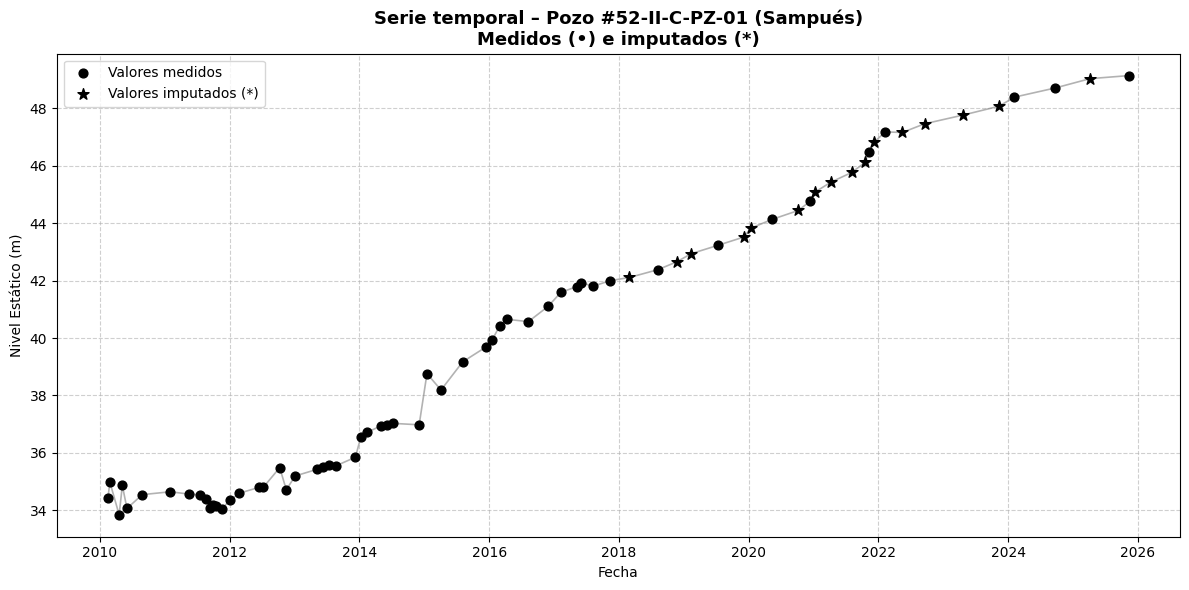

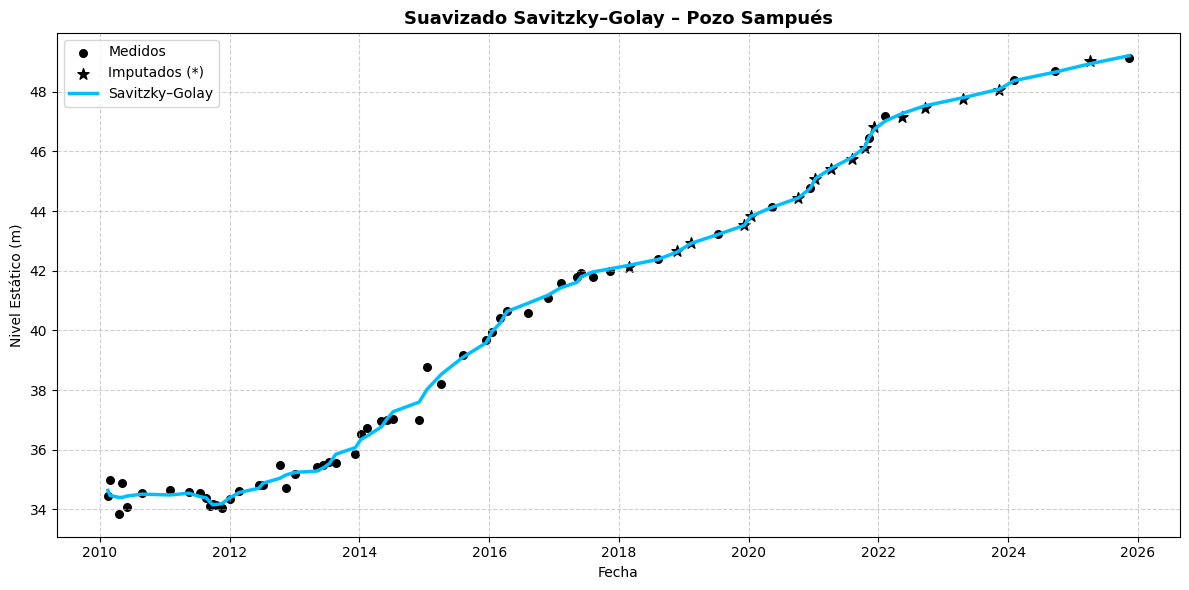

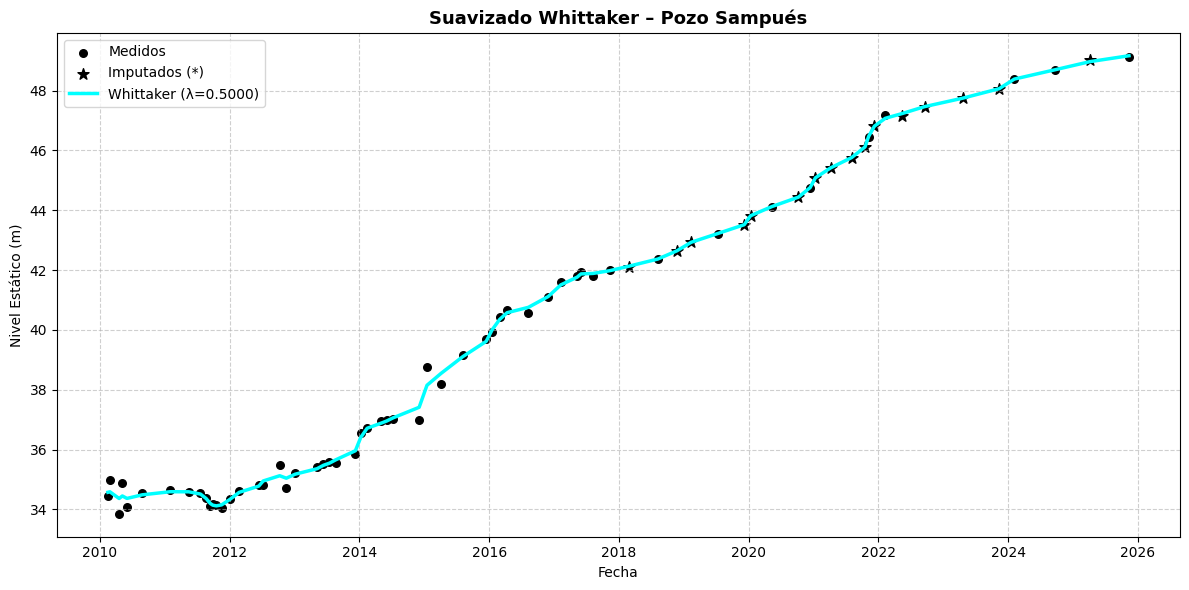

/tmp/ipython-input-1914550454.py:119: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_pred = df.set_index('Fecha').resample('M').mean().interpolate()
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/tmp/ipython-input-1914550454.py:153: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=df_pred.index[-1]+pd.offsets.MonthEnd(1),


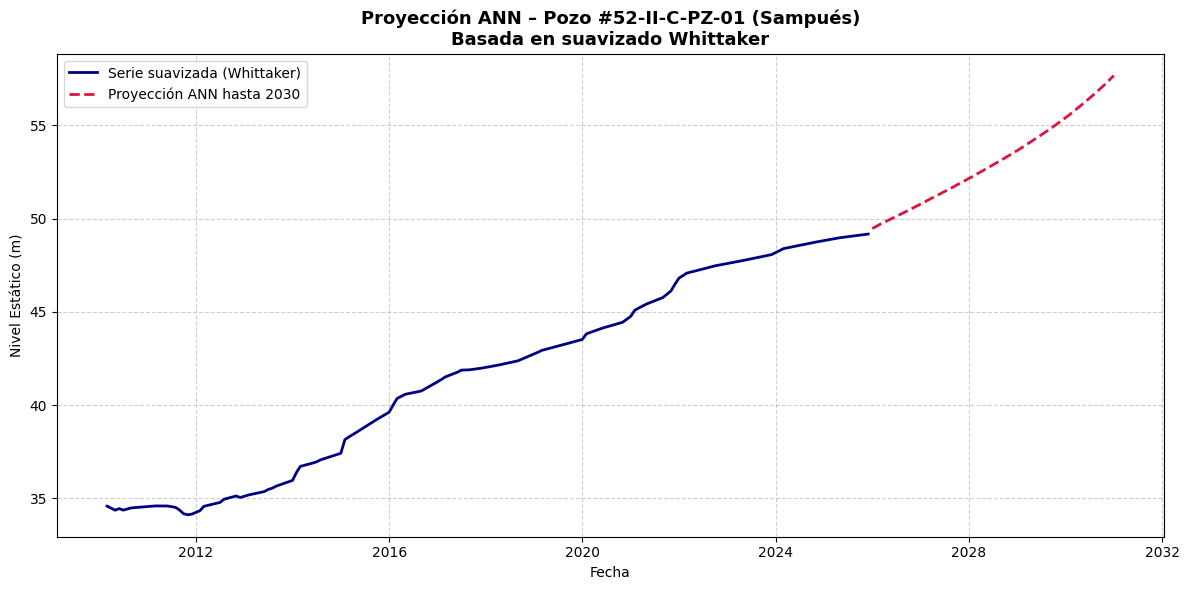

In [ ]:
# ======================================================
# Serie temporal del Pozo Sampués – Medidos, Imputados (asteriscos), Suavizados y Proyección ANN
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -----------------------------------------------
# 1️⃣ Datos del pozo #52-II-C-PZ-01 (Sampués)
# -----------------------------------------------
data = {
    'Fecha': [
        '15/02/2010','26/02/2010','19/04/2010','07/05/2010','02/06/2010','27/08/2010',
        '01/02/2011','16/05/2011','21/07/2011','22/08/2011','14/09/2011','28/09/2011',
        '18/10/2011','17/11/2011','03/01/2012','24/02/2012','13/06/2012','08/07/2012',
        '09/10/2012','15/11/2012','04/01/2013','07/05/2013','12/06/2013','16/07/2013',
        '20/08/2013','09/12/2013','08/01/2014','13/02/2014','05/05/2014','03/06/2014',
        '10/07/2014','03/12/2014','16/01/2015','05/04/2015','05/08/2015','15/12/2015',
        '18/01/2016','29/02/2016','11/04/2016','09/08/2016','28/11/2016','08/02/2017',
        '10/05/2017','01/06/2017','08/08/2017','09/11/2017','01/03/2018','08/08/2018',
        '23/11/2018','12/02/2019','11/07/2019','07/12/2019','12/01/2020','11/05/2020',
        '07/10/2020','12/12/2020','11/01/2021','07/04/2021','03/08/2021','17/10/2021',
        '07/11/2021','09/12/2021','08/02/2022','16/05/2022','17/09/2022','22/04/2023',
        '11/11/2023','05/02/2024','22/09/2024','06/04/2025','11/11/2025'
    ],
    'Nivel_Estatico_m': [
        34.45,34.98,33.85,34.87,34.07,34.55,34.65,34.57,34.54,34.39,34.10,34.19,34.15,
        34.05,34.35,34.60,34.80,34.80,35.49,34.72,35.20,35.43,35.50,35.58,35.55,35.85,
        36.54,36.72,36.95,36.98,37.03,36.98,38.76,38.19,39.17,39.69,39.93,40.42,40.65,
        40.57,41.10,41.59,41.79,41.93,41.80,41.99,42.107111,42.37704237,42.65289932,
        42.93477741,43.22277417,43.51698905,43.81752341,44.1244806,44.43796586,
        44.7580864,45.08495134,45.41867175,45.75936065,46.10713297,46.4621056,
        46.82439736,47.17,47.15234246,47.45189065,47.75630129,48.06563814,48.37996574,
        48.69934942,49.02385527,49.13
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Clasificar datos imputados
# -----------------------------------------------
fechas_imputadas = [
    '01/03/2018','23/11/2018','12/02/2019','07/12/2019',
    '12/01/2020','07/10/2020','11/01/2021','07/04/2021',
    '03/08/2021','17/10/2021','09/12/2021','16/05/2022',
    '17/09/2022','22/04/2023','11/11/2023','06/04/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# -----------------------------------------------
# 3️⃣ Gráfico base: medidos (puntos negros), imputados (asteriscos)
# -----------------------------------------------
plt.figure(figsize=(12,6))
plt.scatter(df.loc[~df['Imputado'], 'Fecha'],
            df.loc[~df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=40, label='Valores medidos', marker='o', zorder=3)
plt.scatter(df.loc[df['Imputado'], 'Fecha'],
            df.loc[df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=70, label='Valores imputados (*)', marker='*', zorder=4)
plt.plot(df['Fecha'], df['Nivel_Estatico_m'], color='gray', linewidth=1.2, alpha=0.6)
plt.title('Serie temporal – Pozo #52-II-C-PZ-01 (Sampués)\nMedidos (•) e imputados (*)', fontsize=13, weight='bold')
plt.xlabel('Fecha'); plt.ylabel('Nivel Estático (m)')
plt.grid(True, linestyle='--', alpha=0.6); plt.legend(); plt.tight_layout(); plt.show()

# ======================================================
# 4️⃣ Suavizados
# ======================================================
# --- Savitzky–Golay ---
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

plt.figure(figsize=(12,6))
plt.scatter(df.loc[~df['Imputado'], 'Fecha'], df.loc[~df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=30, label='Medidos', marker='o')
plt.scatter(df.loc[df['Imputado'], 'Fecha'], df.loc[df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=70, label='Imputados (*)', marker='*')
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2.5, label='Savitzky–Golay')
plt.title('Suavizado Savitzky–Golay – Pozo Sampués', fontsize=13, weight='bold')
plt.xlabel('Fecha'); plt.ylabel('Nivel Estático (m)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()

# --- Whittaker ---
def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=0.5000)

plt.figure(figsize=(12,6))
plt.scatter(df.loc[~df['Imputado'], 'Fecha'], df.loc[~df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=30, label='Medidos', marker='o')
plt.scatter(df.loc[df['Imputado'], 'Fecha'], df.loc[df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=70, label='Imputados (*)', marker='*')
plt.plot(df['Fecha'], df['Whittaker'], color='aqua', linewidth=2.5, label='Whittaker (λ=0.5000)')
plt.title('Suavizado Whittaker – Pozo Sampués', fontsize=13, weight='bold')
plt.xlabel('Fecha'); plt.ylabel('Nivel Estático (m)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()

# ======================================================
# 5️⃣ Proyección ANN (LSTM) hasta 2030
# ======================================================
df_pred = df.set_index('Fecha').resample('M').mean().interpolate()
scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(df_pred[['Whittaker']])

def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = Sequential([
    LSTM(64, activation='relu', input_shape=(window,1)),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=300, batch_size=8, verbose=0)

# --- Predicción hasta 2030 ---
pred_steps = (2030 - df_pred.index[-1].year)*12 + (12 - df_pred.index[-1].month)
last_seq = scaled[-window:]
preds = []
for _ in range(pred_steps):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    last_seq = np.append(last_seq[1:], pred)[-window:]

future_dates = pd.date_range(start=df_pred.index[-1]+pd.offsets.MonthEnd(1),
                             periods=pred_steps, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

# --- Gráfico final de proyección ANN ---
plt.figure(figsize=(12,6))
plt.plot(df_pred.index, df_pred['Whittaker'], color='navy', linewidth=2, label='Serie suavizada (Whittaker)')
plt.plot(future_df['Fecha'], future_df['Nivel_Predicho'], color='crimson', linestyle='--', linewidth=2,
         label='Proyección ANN hasta 2030')
plt.title('Proyección ANN – Pozo #52-II-C-PZ-01 (Sampués)\nBasada en suavizado Whittaker', fontsize=13, weight='bold')
plt.xlabel('Fecha'); plt.ylabel('Nivel Estático (m)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()


Código completo: suavizadores + ANN + tabla comparativa en una sola grafica


📊 Comparación de suavizadores (RMSE, MAE, R²):

                  RMSE     MAE      R²
Savitzky–Golay  0.2133  0.1386  0.9981
Whittaker       0.1608  0.0901  0.9989


/tmp/ipython-input-2129221364.py:102: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_pred = df.set_index('Fecha').resample('M').mean().interpolate()
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/tmp/ipython-input-2129221364.py:136: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=df_pred.index[-1]+pd.offsets.MonthEnd(1),


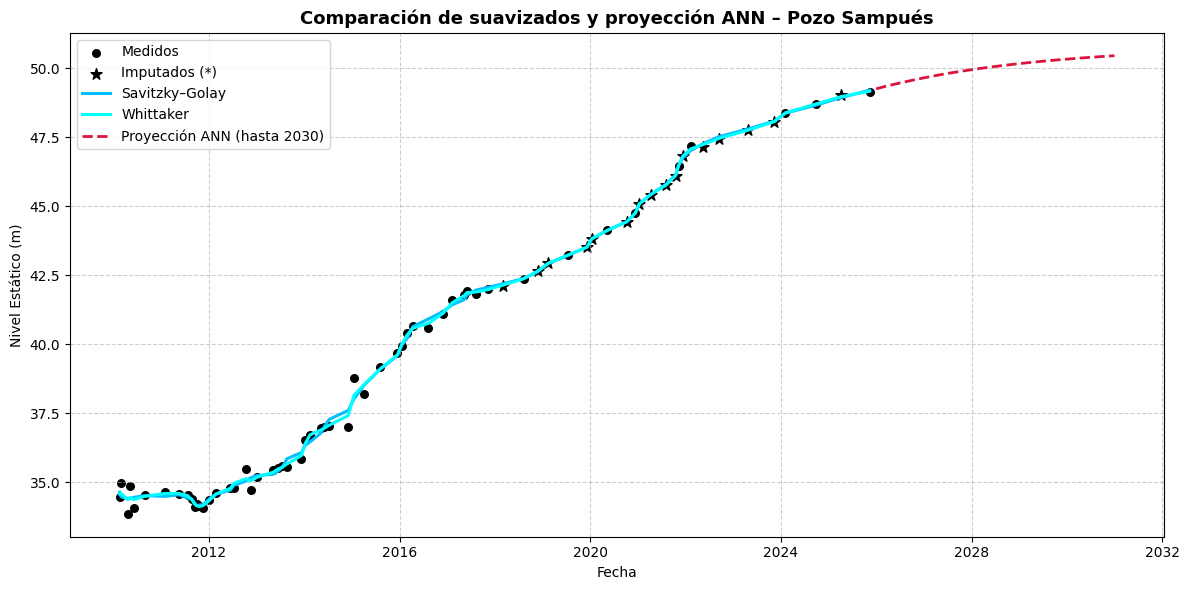

In [ ]:
# ======================================================
# Pozo Sampués – Comparación de suavizados + ANN y tabla de métricas
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -----------------------------------------------
# 1️⃣ Datos del pozo
# -----------------------------------------------
data = {
    'Fecha': [
        '15/02/2010','26/02/2010','19/04/2010','07/05/2010','02/06/2010','27/08/2010',
        '01/02/2011','16/05/2011','21/07/2011','22/08/2011','14/09/2011','28/09/2011',
        '18/10/2011','17/11/2011','03/01/2012','24/02/2012','13/06/2012','08/07/2012',
        '09/10/2012','15/11/2012','04/01/2013','07/05/2013','12/06/2013','16/07/2013',
        '20/08/2013','09/12/2013','08/01/2014','13/02/2014','05/05/2014','03/06/2014',
        '10/07/2014','03/12/2014','16/01/2015','05/04/2015','05/08/2015','15/12/2015',
        '18/01/2016','29/02/2016','11/04/2016','09/08/2016','28/11/2016','08/02/2017',
        '10/05/2017','01/06/2017','08/08/2017','09/11/2017','01/03/2018','08/08/2018',
        '23/11/2018','12/02/2019','11/07/2019','07/12/2019','12/01/2020','11/05/2020',
        '07/10/2020','12/12/2020','11/01/2021','07/04/2021','03/08/2021','17/10/2021',
        '07/11/2021','09/12/2021','08/02/2022','16/05/2022','17/09/2022','22/04/2023',
        '11/11/2023','05/02/2024','22/09/2024','06/04/2025','11/11/2025'
    ],
    'Nivel_Estatico_m': [
        34.45,34.98,33.85,34.87,34.07,34.55,34.65,34.57,34.54,34.39,34.10,34.19,34.15,
        34.05,34.35,34.60,34.80,34.80,35.49,34.72,35.20,35.43,35.50,35.58,35.55,35.85,
        36.54,36.72,36.95,36.98,37.03,36.98,38.76,38.19,39.17,39.69,39.93,40.42,40.65,
        40.57,41.10,41.59,41.79,41.93,41.80,41.99,42.107111,42.37704237,42.65289932,
        42.93477741,43.22277417,43.51698905,43.81752341,44.1244806,44.43796586,
        44.7580864,45.08495134,45.41867175,45.75936065,46.10713297,46.4621056,
        46.82439736,47.17,47.15234246,47.45189065,47.75630129,48.06563814,48.37996574,
        48.69934942,49.02385527,49.13
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# Fechas imputadas (para marcar asteriscos)
fechas_imputadas = [
    '01/03/2018','23/11/2018','12/02/2019','07/12/2019',
    '12/01/2020','07/10/2020','11/01/2021','07/04/2021',
    '03/08/2021','17/10/2021','09/12/2021','16/05/2022',
    '17/09/2022','22/04/2023','11/11/2023','06/04/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 2️⃣ Suavizados
# ======================================================
# Savitzky–Golay
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

# Whittaker
def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=0.5000)

# ======================================================
# 3️⃣ Comparación de suavizadores (RMSE, MAE, R²)
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', 'Whittaker']).round(4)
print('\n📊 Comparación de suavizadores (RMSE, MAE, R²):\n')
print(tabla)

# ======================================================
# 4️⃣ Predicción ANN (LSTM) hasta 2030
# ======================================================
df_pred = df.set_index('Fecha').resample('M').mean().interpolate()
scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(df_pred[['Whittaker']])

def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = Sequential([
    LSTM(64, activation='relu', input_shape=(window,1)),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=300, batch_size=8, verbose=0)

# --- Predicción hasta 2030 ---
pred_steps = (2030 - df_pred.index[-1].year)*12 + (12 - df_pred.index[-1].month)
last_seq = scaled[-window:]
preds = []
for _ in range(pred_steps):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    last_seq = np.append(last_seq[1:], pred)[-window:]

future_dates = pd.date_range(start=df_pred.index[-1]+pd.offsets.MonthEnd(1),
                             periods=pred_steps, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

# ======================================================
# 5️⃣ Gráfico único: suavizados + ANN
# ======================================================
plt.figure(figsize=(12,6))
# Medidos
plt.scatter(df.loc[~df['Imputado'], 'Fecha'], df.loc[~df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=30, label='Medidos', marker='o')
# Imputados (asteriscos)
plt.scatter(df.loc[df['Imputado'], 'Fecha'], df.loc[df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=70, label='Imputados (*)', marker='*')
# Suavizados
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2.2, label='Savitzky–Golay')
plt.plot(df['Fecha'], df['Whittaker'], color='aqua', linewidth=2.2, label='Whittaker')
# ANN
plt.plot(future_df['Fecha'], future_df['Nivel_Predicho'], color='crimson', linestyle='--', linewidth=2,
         label='Proyección ANN (hasta 2030)')
plt.title('Comparación de suavizados y proyección ANN – Pozo Sampués', fontsize=13, weight='bold')
plt.xlabel('Fecha'); plt.ylabel('Nivel Estático (m)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()

# ======================================================
# 6️⃣ Exportar tabla comparativa
# ======================================================
tabla.to_csv('comparacion_suavizadores.csv')



📊 Comparación de suavizadores (RMSE, MAE, R²):

                  RMSE     MAE      R²
Savitzky–Golay  0.2133  0.1386  0.9981
Whittaker       0.1608  0.0901  0.9989


/tmp/ipython-input-800110504.py:104: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_pred = df.set_index('Fecha').resample('M').mean().interpolate()
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/tmp/ipython-input-800110504.py:152: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=df_pred.index[-1]+pd.offsets.MonthEnd(1),


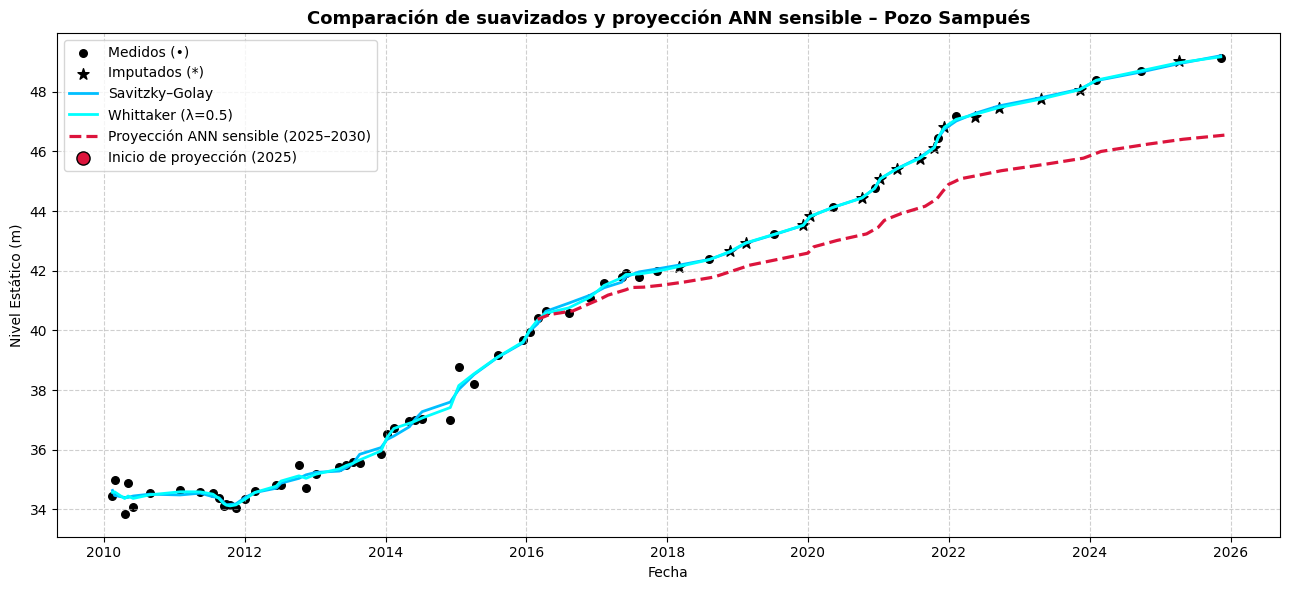

In [ ]:
# ======================================================
# Pozo Sampués – Comparación de suavizados + ANN sensible + tabla de métricas
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -----------------------------------------------
# 1️⃣ Datos del pozo #52-II-C-PZ-01 (Sampués)
# -----------------------------------------------
data = {
    'Fecha': [
        '15/02/2010','26/02/2010','19/04/2010','07/05/2010','02/06/2010','27/08/2010',
        '01/02/2011','16/05/2011','21/07/2011','22/08/2011','14/09/2011','28/09/2011',
        '18/10/2011','17/11/2011','03/01/2012','24/02/2012','13/06/2012','08/07/2012',
        '09/10/2012','15/11/2012','04/01/2013','07/05/2013','12/06/2013','16/07/2013',
        '20/08/2013','09/12/2013','08/01/2014','13/02/2014','05/05/2014','03/06/2014',
        '10/07/2014','03/12/2014','16/01/2015','05/04/2015','05/08/2015','15/12/2015',
        '18/01/2016','29/02/2016','11/04/2016','09/08/2016','28/11/2016','08/02/2017',
        '10/05/2017','01/06/2017','08/08/2017','09/11/2017','01/03/2018','08/08/2018',
        '23/11/2018','12/02/2019','11/07/2019','07/12/2019','12/01/2020','11/05/2020',
        '07/10/2020','12/12/2020','11/01/2021','07/04/2021','03/08/2021','17/10/2021',
        '07/11/2021','09/12/2021','08/02/2022','16/05/2022','17/09/2022','22/04/2023',
        '11/11/2023','05/02/2024','22/09/2024','06/04/2025','11/11/2025'
    ],
    'Nivel_Estatico_m': [
        34.45,34.98,33.85,34.87,34.07,34.55,34.65,34.57,34.54,34.39,34.10,34.19,34.15,
        34.05,34.35,34.60,34.80,34.80,35.49,34.72,35.20,35.43,35.50,35.58,35.55,35.85,
        36.54,36.72,36.95,36.98,37.03,36.98,38.76,38.19,39.17,39.69,39.93,40.42,40.65,
        40.57,41.10,41.59,41.79,41.93,41.80,41.99,42.107111,42.37704237,42.65289932,
        42.93477741,43.22277417,43.51698905,43.81752341,44.1244806,44.43796586,
        44.7580864,45.08495134,45.41867175,45.75936065,46.10713297,46.4621056,
        46.82439736,47.17,47.15234246,47.45189065,47.75630129,48.06563814,48.37996574,
        48.69934942,49.02385527,49.13
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Clasificar datos imputados (asteriscos)
# -----------------------------------------------
fechas_imputadas = [
    '01/03/2018','23/11/2018','12/02/2019','07/12/2019',
    '12/01/2020','07/10/2020','11/01/2021','07/04/2021',
    '03/08/2021','17/10/2021','09/12/2021','16/05/2022',
    '17/09/2022','22/04/2023','11/11/2023','06/04/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados: Savitzky–Golay y Whittaker
# ======================================================
# Savitzky–Golay
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

# Whittaker (λ=0.5)
def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=0.5)

# ======================================================
# 4️⃣ Comparación de suavizadores (RMSE, MAE, R²)
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', 'Whittaker']).round(4)
print('\n📊 Comparación de suavizadores (RMSE, MAE, R²):\n')
print(tabla)

# ======================================================
# 5️⃣ Entrenamiento ANN (LSTM sensible)
# ======================================================
df_pred = df.set_index('Fecha').resample('M').mean().interpolate()

# 🔧 Interpolar serie original al mismo índice mensual
df_base_interp = pd.Series(df['Nivel_Estatico_m'].values, index=df['Fecha']).reindex(df_pred.index)
df_base_interp = df_base_interp.interpolate(method='time')

# Mezcla: 70% suavizado + 30% original (para sensibilidad)
df_pred['Input_Serie'] = 0.7 * df_pred['Whittaker'] + 0.3 * df_base_interp.values

# Escalado
scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(df_pred[['Input_Serie']])

# Crear secuencias para LSTM
def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# --- Modelo LSTM más profundo y sensible ---
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(window,1)),
    LSTM(64, activation='tanh'),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=600, batch_size=4, verbose=0)

# --- Predicción hasta 2030 ---
pred_steps = (2030 - df_pred.index[-1].year)*12 + (12 - df_pred.index[-1].month)
last_seq = scaled[-window:]
preds = []
for _ in range(pred_steps):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    # pequeña variación para sensibilidad
    noise = np.random.normal(0, 0.005)
    last_seq = np.append(last_seq[1:], pred + noise)[-window:]

future_dates = pd.date_range(start=df_pred.index[-1]+pd.offsets.MonthEnd(1),
                             periods=pred_steps, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

# ======================================================
# 6️⃣ Gráfico único: suavizados + ANN sensible (inicia en 2025)
# ======================================================

# Último punto histórico (abril 2025)
last_hist_date = df_pred.index.max()
last_hist_value = df_pred.loc[last_hist_date, 'Input_Serie']

# --- Filtrar histórico (hasta 2025) ---
hist_data = pd.DataFrame({
    'Fecha': df_pred.index,
    'Nivel': df_pred['Input_Serie']
})
hist_data = hist_data[hist_data['Fecha'] <= last_hist_date]

# --- Ajustar fechas de proyección ANN: desde mayo 2025 ---
pred_data = future_df.copy()
pred_data.rename(columns={'Nivel_Predicho': 'Nivel'}, inplace=True)
pred_data = pred_data[pred_data['Fecha'] >= (last_hist_date + pd.offsets.MonthEnd(1))]

# --- Concatenar para continuidad visual ---
combined_data = pd.concat([
    hist_data,
    pd.DataFrame({'Fecha': [last_hist_date], 'Nivel': [last_hist_value]}),
    pred_data
])

# --- Graficar ---
plt.figure(figsize=(13,6))

# Medidos e imputados
plt.scatter(df.loc[~df['Imputado'], 'Fecha'], df.loc[~df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=30, label='Medidos (•)', marker='o')
plt.scatter(df.loc[df['Imputado'], 'Fecha'], df.loc[df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=70, label='Imputados (*)', marker='*')

# Suavizados
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2, label='Savitzky–Golay')
plt.plot(df['Fecha'], df['Whittaker'], color='aqua', linewidth=2, label='Whittaker (λ=0.5)')

# --- Proyección ANN (solo 2025–2030) ---
plt.plot(combined_data['Fecha'], combined_data['Nivel'], color='crimson', linestyle='--', linewidth=2.3,
         label='Proyección ANN sensible (2025–2030)')

# Marcar inicio de proyección
plt.scatter(pred_data['Fecha'].iloc[0], pred_data['Nivel'].iloc[0],
            color='crimson', edgecolors='k', s=90, zorder=5, label='Inicio de proyección (2025)')

# Formato
plt.title('Comparación de suavizados y proyección ANN sensible – Pozo Sampués',
          fontsize=13, weight='bold')
plt.xlabel('Fecha')
plt.ylabel('Nivel Estático (m)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# ======================================================
# 7️⃣ Exportar tabla comparativa
# ======================================================
tabla.to_csv('comparacion_suavizadores.csv')




📊 Comparación de suavizadores (RMSE, MAE, R²):

                  RMSE     MAE      R²
Savitzky–Golay  0.2133  0.1386  0.9981
Whittaker       0.1608  0.0901  0.9989


/tmp/ipython-input-3450433254.py:105: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_pred = df.set_index('Fecha').resample('M').mean().interpolate()
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🔮 Proyectando 72 meses desde 2025-01-31 hasta 2030-12-31


/tmp/ipython-input-3450433254.py:166: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=fecha_inicio_pred, periods=meses_totales, freq='M')


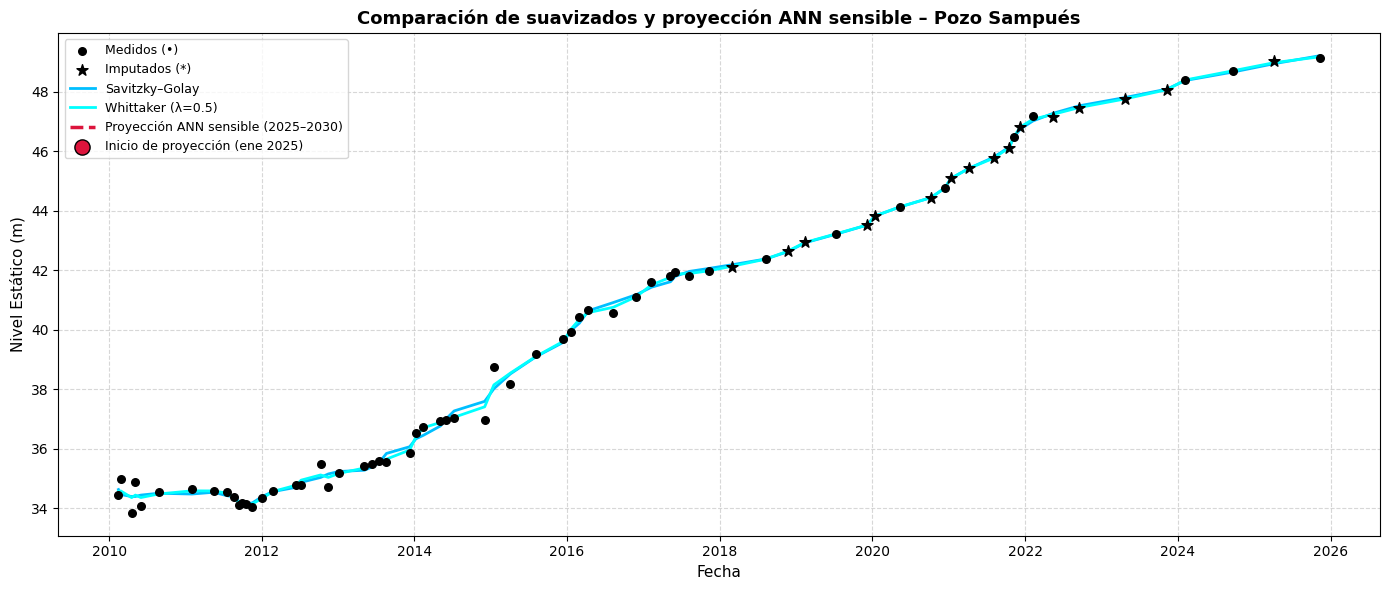


✅ Gráfico generado correctamente
📈 Proyección final (dic 2030): nan m
📊 Archivos exportados: comparacion_suavizadores.csv, proyeccion_ann_2025_2030.csv


In [ ]:
# ======================================================
# Pozo Sampués – Comparación de suavizados + ANN sensible + tabla de métricas
# CORRECCIÓN: Proyección visible 2025-2030
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -----------------------------------------------
# 1️⃣ Datos del pozo #52-II-C-PZ-01 (Sampués)
# -----------------------------------------------
data = {
    'Fecha': [
        '15/02/2010','26/02/2010','19/04/2010','07/05/2010','02/06/2010','27/08/2010',
        '01/02/2011','16/05/2011','21/07/2011','22/08/2011','14/09/2011','28/09/2011',
        '18/10/2011','17/11/2011','03/01/2012','24/02/2012','13/06/2012','08/07/2012',
        '09/10/2012','15/11/2012','04/01/2013','07/05/2013','12/06/2013','16/07/2013',
        '20/08/2013','09/12/2013','08/01/2014','13/02/2014','05/05/2014','03/06/2014',
        '10/07/2014','03/12/2014','16/01/2015','05/04/2015','05/08/2015','15/12/2015',
        '18/01/2016','29/02/2016','11/04/2016','09/08/2016','28/11/2016','08/02/2017',
        '10/05/2017','01/06/2017','08/08/2017','09/11/2017','01/03/2018','08/08/2018',
        '23/11/2018','12/02/2019','11/07/2019','07/12/2019','12/01/2020','11/05/2020',
        '07/10/2020','12/12/2020','11/01/2021','07/04/2021','03/08/2021','17/10/2021',
        '07/11/2021','09/12/2021','08/02/2022','16/05/2022','17/09/2022','22/04/2023',
        '11/11/2023','05/02/2024','22/09/2024','06/04/2025','11/11/2025'
    ],
    'Nivel_Estatico_m': [
        34.45,34.98,33.85,34.87,34.07,34.55,34.65,34.57,34.54,34.39,34.10,34.19,34.15,
        34.05,34.35,34.60,34.80,34.80,35.49,34.72,35.20,35.43,35.50,35.58,35.55,35.85,
        36.54,36.72,36.95,36.98,37.03,36.98,38.76,38.19,39.17,39.69,39.93,40.42,40.65,
        40.57,41.10,41.59,41.79,41.93,41.80,41.99,42.107111,42.37704237,42.65289932,
        42.93477741,43.22277417,43.51698905,43.81752341,44.1244806,44.43796586,
        44.7580864,45.08495134,45.41867175,45.75936065,46.10713297,46.4621056,
        46.82439736,47.17,47.15234246,47.45189065,47.75630129,48.06563814,48.37996574,
        48.69934942,49.02385527,49.13
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Clasificar datos imputados (asteriscos)
# -----------------------------------------------
fechas_imputadas = [
    '01/03/2018','23/11/2018','12/02/2019','07/12/2019',
    '12/01/2020','07/10/2020','11/01/2021','07/04/2021',
    '03/08/2021','17/10/2021','09/12/2021','16/05/2022',
    '17/09/2022','22/04/2023','11/11/2023','06/04/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados: Savitzky–Golay y Whittaker
# ======================================================
# Savitzky–Golay
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

# Whittaker (λ=0.5)
def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=0.5)

# ======================================================
# 4️⃣ Comparación de suavizadores (RMSE, MAE, R²)
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', 'Whittaker']).round(4)
print('\n📊 Comparación de suavizadores (RMSE, MAE, R²):\n')
print(tabla)

# ======================================================
# 5️⃣ Entrenamiento ANN (LSTM sensible)
# ======================================================
df_pred = df.set_index('Fecha').resample('M').mean().interpolate()

# Interpolar serie original al mismo índice mensual
df_base_interp = pd.Series(df['Nivel_Estatico_m'].values, index=df['Fecha']).reindex(df_pred.index)
df_base_interp = df_base_interp.interpolate(method='time')

# Mezcla: 70% suavizado + 30% original (para sensibilidad)
df_pred['Input_Serie'] = 0.7 * df_pred['Whittaker'] + 0.3 * df_base_interp.values

# Escalado
scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(df_pred[['Input_Serie']])

# Crear secuencias para LSTM
def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# --- Modelo LSTM más profundo y sensible ---
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(window,1)),
    LSTM(64, activation='tanh'),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=600, batch_size=4, verbose=0)

# ======================================================
# 🔧 CORRECCIÓN: Calcular predicción desde enero 2025 hasta diciembre 2030
# ======================================================

# Fecha de inicio de predicción: enero 2025
fecha_inicio_pred = pd.Timestamp('2025-01-31')  # Último día de enero 2025
fecha_fin_pred = pd.Timestamp('2030-12-31')  # Último día de diciembre 2030

# Calcular número de meses a predecir
meses_totales = (fecha_fin_pred.year - fecha_inicio_pred.year) * 12 + \
                (fecha_fin_pred.month - fecha_inicio_pred.month) + 1

print(f"\n🔮 Proyectando {meses_totales} meses desde {fecha_inicio_pred.date()} hasta {fecha_fin_pred.date()}")

# --- Predicción iterativa ---
last_seq = scaled[-window:]
preds = []
for _ in range(meses_totales):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    noise = np.random.normal(0, 0.005)
    last_seq = np.append(last_seq[1:], pred + noise)[-window:]

# Crear DataFrame de predicciones
future_dates = pd.date_range(start=fecha_inicio_pred, periods=meses_totales, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

# ======================================================
# 6️⃣ Gráfico único: suavizados + ANN sensible (2025-2030)
# ======================================================

plt.figure(figsize=(14,6))

# Medidos e imputados
plt.scatter(df.loc[~df['Imputado'], 'Fecha'], df.loc[~df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=30, label='Medidos (•)', marker='o', zorder=3)
plt.scatter(df.loc[df['Imputado'], 'Fecha'], df.loc[df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=70, label='Imputados (*)', marker='*', zorder=3)

# Suavizados
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2, label='Savitzky–Golay')
plt.plot(df['Fecha'], df['Whittaker'], color='aqua', linewidth=2, label='Whittaker (λ=0.5)')

# --- Proyección ANN (2025–2030) ---
plt.plot(future_df['Fecha'], future_df['Nivel_Predicho'],
         color='crimson', linestyle='--', linewidth=2.5,
         label='Proyección ANN sensible (2025–2030)', zorder=2)

# Marcar inicio de proyección
plt.scatter(future_df['Fecha'].iloc[0], future_df['Nivel_Predicho'].iloc[0],
            color='crimson', edgecolors='k', s=120, zorder=5,
            label='Inicio de proyección (ene 2025)', marker='o')

# Formato
plt.title('Comparación de suavizados y proyección ANN sensible – Pozo Sampués',
          fontsize=13, weight='bold')
plt.xlabel('Fecha', fontsize=11)
plt.ylabel('Nivel Estático (m)', fontsize=11)
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ======================================================
# 7️⃣ Exportar resultados
# ======================================================
tabla.to_csv('comparacion_suavizadores.csv')
future_df.to_csv('proyeccion_ann_2025_2030.csv', index=False)

print("\n✅ Gráfico generado correctamente")
print(f"📈 Proyección final (dic 2030): {future_df['Nivel_Predicho'].iloc[-1]:.2f} m")
print(f"📊 Archivos exportados: comparacion_suavizadores.csv, proyeccion_ann_2025_2030.csv")


📊 Comparación de suavizadores (RMSE, MAE, R²):

                  RMSE     MAE      R²
Savitzky–Golay  0.2133  0.1386  0.9981
Whittaker       0.1608  0.0901  0.9989


/tmp/ipython-input-2959385123.py:105: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_pred = df.set_index('Fecha').resample('M').mean().interpolate()
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🔮 Proyectando 72 meses desde 2025-01-31 hasta 2030-12-31


/tmp/ipython-input-2959385123.py:166: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=fecha_inicio_pred, periods=meses_totales, freq='M')


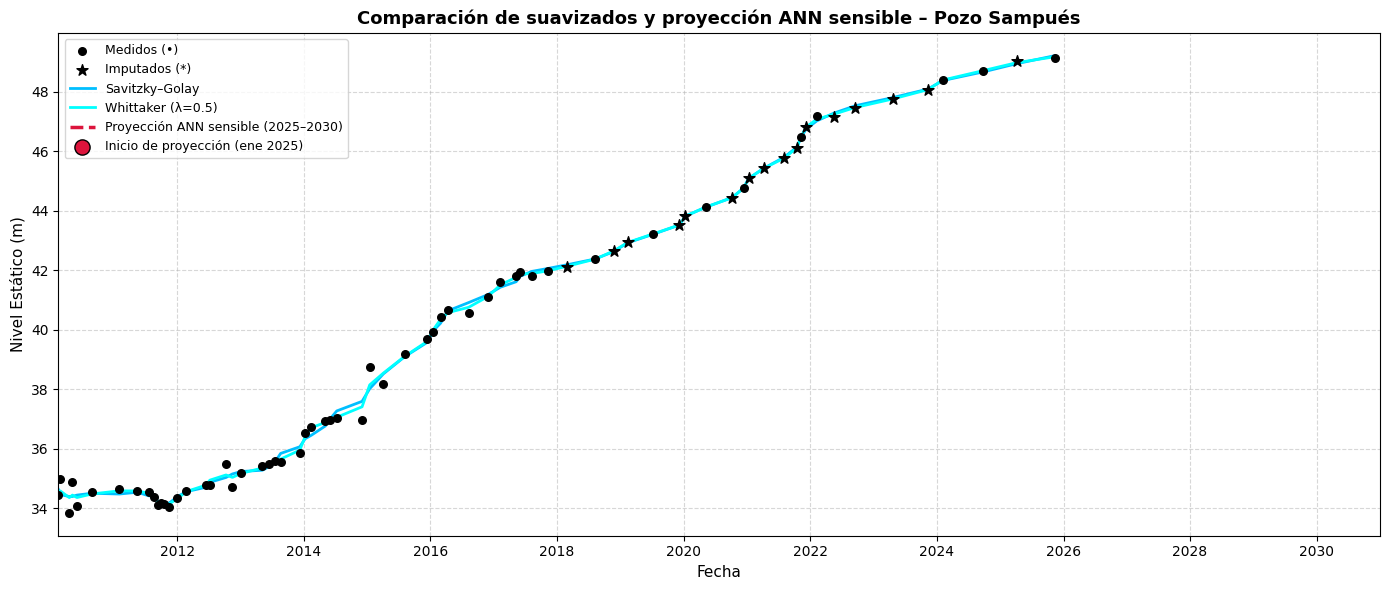


✅ Gráfico generado correctamente
📈 Proyección final (dic 2030): nan m
📊 Archivos exportados: comparacion_suavizadores.csv, proyeccion_ann_2025_2030.csv


In [ ]:
# ======================================================
# Pozo Sampués – Comparación de suavizados + ANN sensible + tabla de métricas
# CORRECCIÓN: Proyección visible 2025-2030
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -----------------------------------------------
# 1️⃣ Datos del pozo #52-II-C-PZ-01 (Sampués)
# -----------------------------------------------
data = {
    'Fecha': [
        '15/02/2010','26/02/2010','19/04/2010','07/05/2010','02/06/2010','27/08/2010',
        '01/02/2011','16/05/2011','21/07/2011','22/08/2011','14/09/2011','28/09/2011',
        '18/10/2011','17/11/2011','03/01/2012','24/02/2012','13/06/2012','08/07/2012',
        '09/10/2012','15/11/2012','04/01/2013','07/05/2013','12/06/2013','16/07/2013',
        '20/08/2013','09/12/2013','08/01/2014','13/02/2014','05/05/2014','03/06/2014',
        '10/07/2014','03/12/2014','16/01/2015','05/04/2015','05/08/2015','15/12/2015',
        '18/01/2016','29/02/2016','11/04/2016','09/08/2016','28/11/2016','08/02/2017',
        '10/05/2017','01/06/2017','08/08/2017','09/11/2017','01/03/2018','08/08/2018',
        '23/11/2018','12/02/2019','11/07/2019','07/12/2019','12/01/2020','11/05/2020',
        '07/10/2020','12/12/2020','11/01/2021','07/04/2021','03/08/2021','17/10/2021',
        '07/11/2021','09/12/2021','08/02/2022','16/05/2022','17/09/2022','22/04/2023',
        '11/11/2023','05/02/2024','22/09/2024','06/04/2025','11/11/2025'
    ],
    'Nivel_Estatico_m': [
        34.45,34.98,33.85,34.87,34.07,34.55,34.65,34.57,34.54,34.39,34.10,34.19,34.15,
        34.05,34.35,34.60,34.80,34.80,35.49,34.72,35.20,35.43,35.50,35.58,35.55,35.85,
        36.54,36.72,36.95,36.98,37.03,36.98,38.76,38.19,39.17,39.69,39.93,40.42,40.65,
        40.57,41.10,41.59,41.79,41.93,41.80,41.99,42.107111,42.37704237,42.65289932,
        42.93477741,43.22277417,43.51698905,43.81752341,44.1244806,44.43796586,
        44.7580864,45.08495134,45.41867175,45.75936065,46.10713297,46.4621056,
        46.82439736,47.17,47.15234246,47.45189065,47.75630129,48.06563814,48.37996574,
        48.69934942,49.02385527,49.13
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Clasificar datos imputados (asteriscos)
# -----------------------------------------------
fechas_imputadas = [
    '01/03/2018','23/11/2018','12/02/2019','07/12/2019',
    '12/01/2020','07/10/2020','11/01/2021','07/04/2021',
    '03/08/2021','17/10/2021','09/12/2021','16/05/2022',
    '17/09/2022','22/04/2023','11/11/2023','06/04/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados: Savitzky–Golay y Whittaker
# ======================================================
# Savitzky–Golay
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

# Whittaker (λ=0.5)
def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=0.5)

# ======================================================
# 4️⃣ Comparación de suavizadores (RMSE, MAE, R²)
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', 'Whittaker']).round(4)
print('\n📊 Comparación de suavizadores (RMSE, MAE, R²):\n')
print(tabla)

# ======================================================
# 5️⃣ Entrenamiento ANN (LSTM sensible)
# ======================================================
df_pred = df.set_index('Fecha').resample('M').mean().interpolate()

# Interpolar serie original al mismo índice mensual
df_base_interp = pd.Series(df['Nivel_Estatico_m'].values, index=df['Fecha']).reindex(df_pred.index)
df_base_interp = df_base_interp.interpolate(method='time')

# Mezcla: 70% suavizado + 30% original (para sensibilidad)
df_pred['Input_Serie'] = 0.7 * df_pred['Whittaker'] + 0.3 * df_base_interp.values

# Escalado
scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(df_pred[['Input_Serie']])

# Crear secuencias para LSTM
def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# --- Modelo LSTM más profundo y sensible ---
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(window,1)),
    LSTM(64, activation='tanh'),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=600, batch_size=4, verbose=0)

# ======================================================
# 🔧 CORRECCIÓN: Calcular predicción desde enero 2025 hasta diciembre 2030
# ======================================================

# Fecha de inicio de predicción: enero 2025
fecha_inicio_pred = pd.Timestamp('2025-01-31')  # Último día de enero 2025
fecha_fin_pred = pd.Timestamp('2030-12-31')  # Último día de diciembre 2030

# Calcular número de meses a predecir
meses_totales = (fecha_fin_pred.year - fecha_inicio_pred.year) * 12 + \
                (fecha_fin_pred.month - fecha_inicio_pred.month) + 1

print(f"\n🔮 Proyectando {meses_totales} meses desde {fecha_inicio_pred.date()} hasta {fecha_fin_pred.date()}")

# --- Predicción iterativa ---
last_seq = scaled[-window:]
preds = []
for _ in range(meses_totales):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    noise = np.random.normal(0, 0.005)
    last_seq = np.append(last_seq[1:], pred + noise)[-window:]

# Crear DataFrame de predicciones
future_dates = pd.date_range(start=fecha_inicio_pred, periods=meses_totales, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

# ======================================================
# 6️⃣ Gráfico único: suavizados + ANN sensible (2025-2030)
# ======================================================

plt.figure(figsize=(14,6))

# Medidos e imputados
plt.scatter(df.loc[~df['Imputado'], 'Fecha'], df.loc[~df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=30, label='Medidos (•)', marker='o', zorder=3)
plt.scatter(df.loc[df['Imputado'], 'Fecha'], df.loc[df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=70, label='Imputados (*)', marker='*', zorder=3)

# Suavizados
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2, label='Savitzky–Golay')
plt.plot(df['Fecha'], df['Whittaker'], color='aqua', linewidth=2, label='Whittaker (λ=0.5)')

# --- Proyección ANN (2025–2030) ---
plt.plot(future_df['Fecha'], future_df['Nivel_Predicho'],
         color='crimson', linestyle='--', linewidth=2.5,
         label='Proyección ANN sensible (2025–2030)', zorder=2)

# Marcar inicio de proyección
plt.scatter(future_df['Fecha'].iloc[0], future_df['Nivel_Predicho'].iloc[0],
            color='crimson', edgecolors='k', s=120, zorder=5,
            label='Inicio de proyección (ene 2025)', marker='o')

# Formato
plt.title('Comparación de suavizados y proyección ANN sensible – Pozo Sampués',
          fontsize=13, weight='bold')
plt.xlabel('Fecha', fontsize=11)
plt.ylabel('Nivel Estático (m)', fontsize=11)

# 🔧 IMPORTANTE: Extender el eje X hasta 2030
plt.xlim(df['Fecha'].min(), pd.Timestamp('2031-01-01'))

plt.legend(loc='upper left', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ======================================================
# 7️⃣ Exportar resultados
# ======================================================
tabla.to_csv('comparacion_suavizadores.csv')
future_df.to_csv('proyeccion_ann_2025_2030.csv', index=False)

print("\n✅ Gráfico generado correctamente")
print(f"📈 Proyección final (dic 2030): {future_df['Nivel_Predicho'].iloc[-1]:.2f} m")
print(f"📊 Archivos exportados: comparacion_suavizadores.csv, proyeccion_ann_2025_2030.csv")


📊 Comparación de suavizadores (RMSE, MAE, R²):

                  RMSE     MAE      R²
Savitzky–Golay  0.2133  0.1386  0.9981
Whittaker       0.1608  0.0901  0.9989


/tmp/ipython-input-2713214287.py:105: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_pred = df.set_index('Fecha').resample('M').mean().interpolate()
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



📅 Última fecha histórica: 2025-11-30
🔮 Proyectando 61 meses hasta 2030-12-31


/tmp/ipython-input-2713214287.py:169: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=ultima_fecha_historica + pd.DateOffset(months=1),


📊 Primera fecha de predicción: 2025-12-31
📊 Última fecha de predicción: 2030-12-31

✅ Proyección graficada: 61 puntos


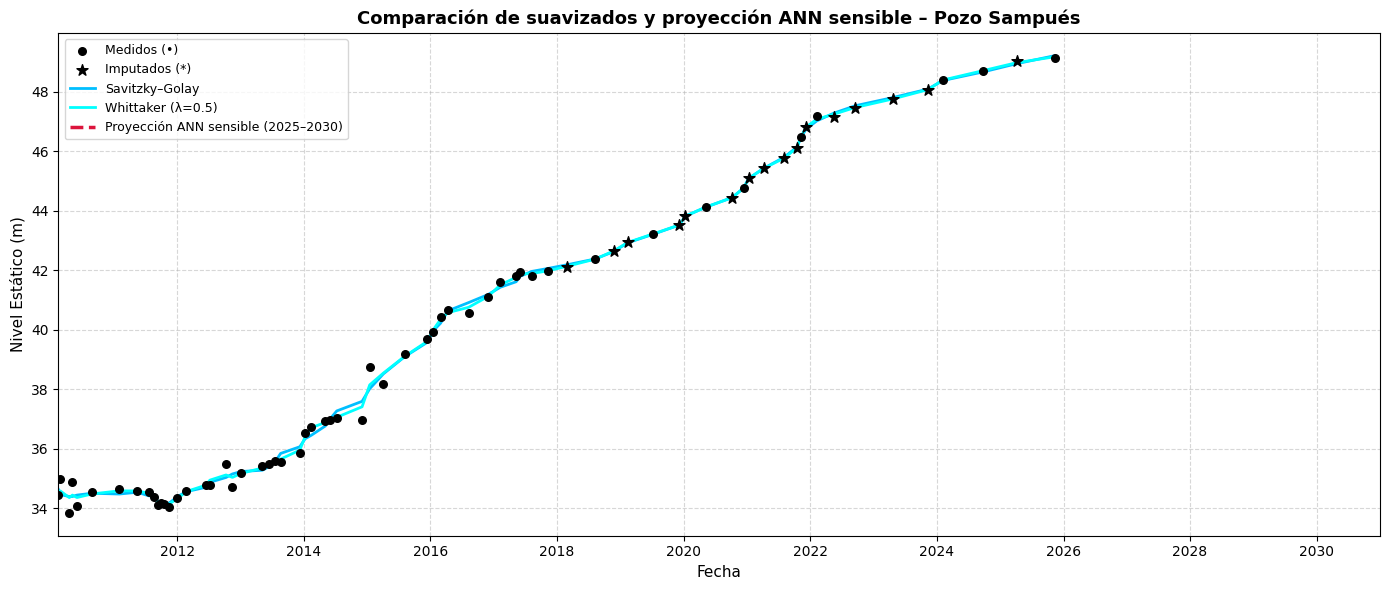


✅ Gráfico generado correctamente
📈 Proyección final (dic 2030): nan m
📊 Archivos exportados: comparacion_suavizadores.csv, proyeccion_ann_2025_2030.csv


In [ ]:
# ======================================================
# Pozo Sampués – Comparación de suavizados + ANN sensible + tabla de métricas
# CORRECCIÓN: Proyección visible 2025-2030
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -----------------------------------------------
# 1️⃣ Datos del pozo #52-II-C-PZ-01 (Sampués)
# -----------------------------------------------
data = {
    'Fecha': [
        '15/02/2010','26/02/2010','19/04/2010','07/05/2010','02/06/2010','27/08/2010',
        '01/02/2011','16/05/2011','21/07/2011','22/08/2011','14/09/2011','28/09/2011',
        '18/10/2011','17/11/2011','03/01/2012','24/02/2012','13/06/2012','08/07/2012',
        '09/10/2012','15/11/2012','04/01/2013','07/05/2013','12/06/2013','16/07/2013',
        '20/08/2013','09/12/2013','08/01/2014','13/02/2014','05/05/2014','03/06/2014',
        '10/07/2014','03/12/2014','16/01/2015','05/04/2015','05/08/2015','15/12/2015',
        '18/01/2016','29/02/2016','11/04/2016','09/08/2016','28/11/2016','08/02/2017',
        '10/05/2017','01/06/2017','08/08/2017','09/11/2017','01/03/2018','08/08/2018',
        '23/11/2018','12/02/2019','11/07/2019','07/12/2019','12/01/2020','11/05/2020',
        '07/10/2020','12/12/2020','11/01/2021','07/04/2021','03/08/2021','17/10/2021',
        '07/11/2021','09/12/2021','08/02/2022','16/05/2022','17/09/2022','22/04/2023',
        '11/11/2023','05/02/2024','22/09/2024','06/04/2025','11/11/2025'
    ],
    'Nivel_Estatico_m': [
        34.45,34.98,33.85,34.87,34.07,34.55,34.65,34.57,34.54,34.39,34.10,34.19,34.15,
        34.05,34.35,34.60,34.80,34.80,35.49,34.72,35.20,35.43,35.50,35.58,35.55,35.85,
        36.54,36.72,36.95,36.98,37.03,36.98,38.76,38.19,39.17,39.69,39.93,40.42,40.65,
        40.57,41.10,41.59,41.79,41.93,41.80,41.99,42.107111,42.37704237,42.65289932,
        42.93477741,43.22277417,43.51698905,43.81752341,44.1244806,44.43796586,
        44.7580864,45.08495134,45.41867175,45.75936065,46.10713297,46.4621056,
        46.82439736,47.17,47.15234246,47.45189065,47.75630129,48.06563814,48.37996574,
        48.69934942,49.02385527,49.13
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Clasificar datos imputados (asteriscos)
# -----------------------------------------------
fechas_imputadas = [
    '01/03/2018','23/11/2018','12/02/2019','07/12/2019',
    '12/01/2020','07/10/2020','11/01/2021','07/04/2021',
    '03/08/2021','17/10/2021','09/12/2021','16/05/2022',
    '17/09/2022','22/04/2023','11/11/2023','06/04/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados: Savitzky–Golay y Whittaker
# ======================================================
# Savitzky–Golay
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

# Whittaker (λ=0.5)
def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=0.5)

# ======================================================
# 4️⃣ Comparación de suavizadores (RMSE, MAE, R²)
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', 'Whittaker']).round(4)
print('\n📊 Comparación de suavizadores (RMSE, MAE, R²):\n')
print(tabla)

# ======================================================
# 5️⃣ Entrenamiento ANN (LSTM sensible)
# ======================================================
df_pred = df.set_index('Fecha').resample('M').mean().interpolate()

# Interpolar serie original al mismo índice mensual
df_base_interp = pd.Series(df['Nivel_Estatico_m'].values, index=df['Fecha']).reindex(df_pred.index)
df_base_interp = df_base_interp.interpolate(method='time')

# Mezcla: 70% suavizado + 30% original (para sensibilidad)
df_pred['Input_Serie'] = 0.7 * df_pred['Whittaker'] + 0.3 * df_base_interp.values

# Escalado
scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(df_pred[['Input_Serie']])

# Crear secuencias para LSTM
def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# --- Modelo LSTM más profundo y sensible ---
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(window,1)),
    LSTM(64, activation='tanh'),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=600, batch_size=4, verbose=0)

# ======================================================
# 🔧 CORRECCIÓN: Calcular predicción desde el último dato hasta 2030
# ======================================================

# Obtener la última fecha del dataset histórico procesado
ultima_fecha_historica = df_pred.index[-1]
print(f"\n📅 Última fecha histórica: {ultima_fecha_historica.date()}")

# Fecha final de predicción: diciembre 2030
fecha_fin_pred = pd.Timestamp('2030-12-31')

# Calcular número de meses a predecir desde la última fecha histórica
meses_totales = (fecha_fin_pred.year - ultima_fecha_historica.year) * 12 + \
                (fecha_fin_pred.month - ultima_fecha_historica.month)

print(f"🔮 Proyectando {meses_totales} meses hasta {fecha_fin_pred.date()}")

# --- Predicción iterativa ---
last_seq = scaled[-window:]
preds = []
for _ in range(meses_totales):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    noise = np.random.normal(0, 0.005)
    last_seq = np.append(last_seq[1:], pred + noise)[-window:]

# Crear DataFrame de predicciones (empezando desde el mes siguiente al último histórico)
future_dates = pd.date_range(start=ultima_fecha_historica + pd.DateOffset(months=1),
                              periods=meses_totales, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

print(f"📊 Primera fecha de predicción: {future_df['Fecha'].iloc[0].date()}")
print(f"📊 Última fecha de predicción: {future_df['Fecha'].iloc[-1].date()}")

# ======================================================
# 6️⃣ Gráfico único: suavizados + ANN sensible (2025-2030)
# ======================================================

plt.figure(figsize=(14,6))

# Medidos e imputados
plt.scatter(df.loc[~df['Imputado'], 'Fecha'], df.loc[~df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=30, label='Medidos (•)', marker='o', zorder=3)
plt.scatter(df.loc[df['Imputado'], 'Fecha'], df.loc[df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=70, label='Imputados (*)', marker='*', zorder=3)

# Suavizados
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2, label='Savitzky–Golay')
plt.plot(df['Fecha'], df['Whittaker'], color='aqua', linewidth=2, label='Whittaker (λ=0.5)')

# --- Proyección ANN (desde última fecha hasta 2030) ---
if len(future_df) > 0:
    plt.plot(future_df['Fecha'], future_df['Nivel_Predicho'],
             color='crimson', linestyle='--', linewidth=2.5,
             label='Proyección ANN sensible (2025–2030)', zorder=2)
    print(f"\n✅ Proyección graficada: {len(future_df)} puntos")
else:
    print("\n⚠️ No hay datos de proyección para graficar")

# Formato
plt.title('Comparación de suavizados y proyección ANN sensible – Pozo Sampués',
          fontsize=13, weight='bold')
plt.xlabel('Fecha', fontsize=11)
plt.ylabel('Nivel Estático (m)', fontsize=11)

# 🔧 IMPORTANTE: Extender el eje X hasta 2030
plt.xlim(df['Fecha'].min(), pd.Timestamp('2031-01-01'))

plt.legend(loc='upper left', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ======================================================
# 7️⃣ Exportar resultados
# ======================================================
tabla.to_csv('comparacion_suavizadores.csv')
future_df.to_csv('proyeccion_ann_2025_2030.csv', index=False)

print("\n✅ Gráfico generado correctamente")
print(f"📈 Proyección final (dic 2030): {future_df['Nivel_Predicho'].iloc[-1]:.2f} m")
print(f"📊 Archivos exportados: comparacion_suavizadores.csv, proyeccion_ann_2025_2030.csv")


📊 Comparación de suavizadores (RMSE, MAE, R²):

                  RMSE     MAE      R²
Savitzky–Golay  0.2133  0.1386  0.9981
Whittaker       0.1608  0.0901  0.9989

📅 Datos mensuales preparados: 190 puntos
   Desde: 2010-02-28
   Hasta: 2025-11-30

🧠 Entrenando modelo LSTM...
   Secuencias de entrenamiento: 142
   Secuencias de prueba: 36
✅ Modelo entrenado

🔮 Generando proyección desde 2025-11-30 hasta 2030-12-31
   Meses a proyectar: 61

✅ Proyección generada:
   Primera fecha: 2025-12-31 = 49.10 m
   Última fecha: 2030-12-31 = 47.51 m
   Total de puntos: 61


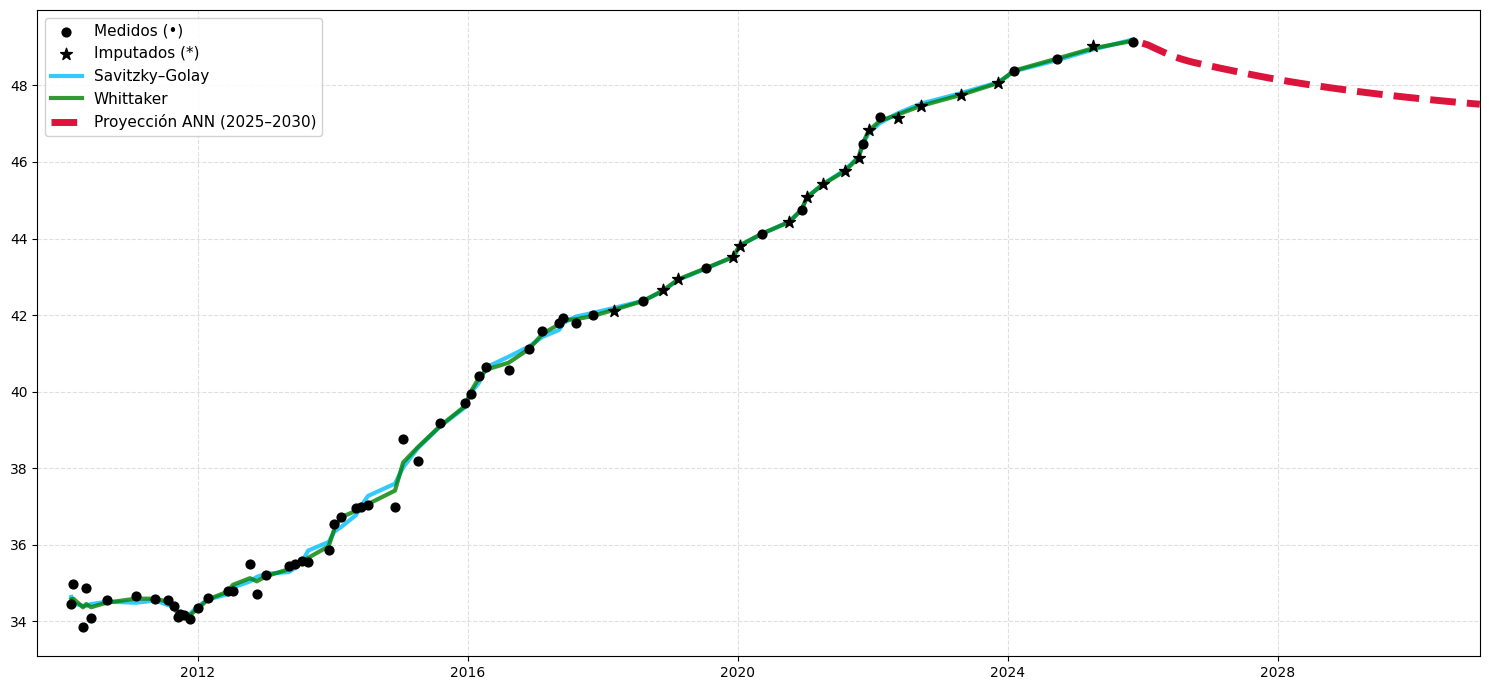


✅ Archivos exportados:
   - comparacion_suavizadores.csv
   - proyeccion_ann_2025_2030.csv


In [ ]:
# ======================================================
# Pozo Sampues - # 52-II-C-PZ-01 – Comparación de suavizados + ANN 2025-2030
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------
# 1️⃣ Datos del pozo #52-II-C-PZ-01 (Sampués)
# -----------------------------------------------
data = {
    'Fecha': [
        '15/02/2010','26/02/2010','19/04/2010','07/05/2010','02/06/2010','27/08/2010',
        '01/02/2011','16/05/2011','21/07/2011','22/08/2011','14/09/2011','28/09/2011',
        '18/10/2011','17/11/2011','03/01/2012','24/02/2012','13/06/2012','08/07/2012',
        '09/10/2012','15/11/2012','04/01/2013','07/05/2013','12/06/2013','16/07/2013',
        '20/08/2013','09/12/2013','08/01/2014','13/02/2014','05/05/2014','03/06/2014',
        '10/07/2014','03/12/2014','16/01/2015','05/04/2015','05/08/2015','15/12/2015',
        '18/01/2016','29/02/2016','11/04/2016','09/08/2016','28/11/2016','08/02/2017',
        '10/05/2017','01/06/2017','08/08/2017','09/11/2017','01/03/2018','08/08/2018',
        '23/11/2018','12/02/2019','11/07/2019','07/12/2019','12/01/2020','11/05/2020',
        '07/10/2020','12/12/2020','11/01/2021','07/04/2021','03/08/2021','17/10/2021',
        '07/11/2021','09/12/2021','08/02/2022','16/05/2022','17/09/2022','22/04/2023',
        '11/11/2023','05/02/2024','22/09/2024','06/04/2025','11/11/2025'
    ],
    'Nivel_Estatico_m': [
        34.45,34.98,33.85,34.87,34.07,34.55,34.65,34.57,34.54,34.39,34.10,34.19,34.15,
        34.05,34.35,34.60,34.80,34.80,35.49,34.72,35.20,35.43,35.50,35.58,35.55,35.85,
        36.54,36.72,36.95,36.98,37.03,36.98,38.76,38.19,39.17,39.69,39.93,40.42,40.65,
        40.57,41.10,41.59,41.79,41.93,41.80,41.99,42.107111,42.37704237,42.65289932,
        42.93477741,43.22277417,43.51698905,43.81752341,44.1244806,44.43796586,
        44.7580864,45.08495134,45.41867175,45.75936065,46.10713297,46.4621056,
        46.82439736,47.17,47.15234246,47.45189065,47.75630129,48.06563814,48.37996574,
        48.69934942,49.02385527,49.13
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Clasificar datos imputados (asteriscos)
# -----------------------------------------------
fechas_imputadas = [
    '01/03/2018','23/11/2018','12/02/2019','07/12/2019',
    '12/01/2020','07/10/2020','11/01/2021','07/04/2021',
    '03/08/2021','17/10/2021','09/12/2021','16/05/2022',
    '17/09/2022','22/04/2023','11/11/2023','06/04/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados: Savitzky–Golay y Whittaker
# ======================================================
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=0.5)

# ======================================================
# 4️⃣ Comparación de suavizadores (RMSE, MAE, R²)
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', 'Whittaker']).round(4)
print('\n📊 Comparación de suavizadores (RMSE, MAE, R²):\n')
print(tabla)

# ======================================================
# 5️⃣ Preparación de datos para LSTM
# ======================================================
# Usar directamente los datos originales para entrenar
serie_temporal = df[['Fecha', 'Nivel_Estatico_m']].copy()
serie_temporal = serie_temporal.set_index('Fecha')

# Remuestrear a mensual e interpolar
serie_mensual = serie_temporal.resample('M').mean().interpolate(method='linear')

print(f"\n📅 Datos mensuales preparados: {len(serie_mensual)} puntos")
print(f"   Desde: {serie_mensual.index[0].date()}")
print(f"   Hasta: {serie_mensual.index[-1].date()}")

# Escalado
scaler = MinMaxScaler((0,1))
datos_escalados = scaler.fit_transform(serie_mensual.values.reshape(-1,1))

# ======================================================
# 6️⃣ Crear secuencias y entrenar LSTM
# ======================================================
def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

lookback = 12
X, y = create_sequences(datos_escalados, lookback)

# Dividir en train/test
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"\n🧠 Entrenando modelo LSTM...")
print(f"   Secuencias de entrenamiento: {len(X_train)}")
print(f"   Secuencias de prueba: {len(X_test)}")

# Modelo LSTM
model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(lookback, 1)),
    LSTM(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=500, batch_size=4, verbose=0)

print("✅ Modelo entrenado")

# ======================================================
# 7️⃣ PROYECCIÓN HACIA EL FUTURO (2025-2030)
# ======================================================
ultima_fecha = serie_mensual.index[-1]
print(f"\n🔮 Generando proyección desde {ultima_fecha.date()} hasta 2030-12-31")

# Calcular meses hasta diciembre 2030
fecha_final = pd.Timestamp('2030-12-31')
meses_proyectar = (fecha_final.year - ultima_fecha.year) * 12 + (fecha_final.month - ultima_fecha.month)

print(f"   Meses a proyectar: {meses_proyectar}")

# Preparar última secuencia
ultima_secuencia = datos_escalados[-lookback:].copy()
proyecciones = []

# Generar predicciones futuras
for i in range(meses_proyectar):
    # Predecir siguiente valor
    entrada = ultima_secuencia.reshape(1, lookback, 1)
    pred = model.predict(entrada, verbose=0)
    proyecciones.append(pred[0, 0])

    # Actualizar secuencia (agregar predicción y remover el más antiguo)
    ultima_secuencia = np.append(ultima_secuencia[1:], pred)

# Convertir predicciones a escala original
proyecciones_originales = scaler.inverse_transform(np.array(proyecciones).reshape(-1, 1))

# Crear DataFrame con fechas futuras
fechas_futuras = pd.date_range(start=ultima_fecha + pd.DateOffset(months=1),
                                periods=meses_proyectar,
                                freq='M')

df_proyeccion = pd.DataFrame({
    'Fecha': fechas_futuras,
    'Nivel_Proyectado': proyecciones_originales.flatten()
})

print(f"\n✅ Proyección generada:")
print(f"   Primera fecha: {df_proyeccion['Fecha'].iloc[0].date()} = {df_proyeccion['Nivel_Proyectado'].iloc[0]:.2f} m")
print(f"   Última fecha: {df_proyeccion['Fecha'].iloc[-1].date()} = {df_proyeccion['Nivel_Proyectado'].iloc[-1]:.2f} m")
print(f"   Total de puntos: {len(df_proyeccion)}")

# ======================================================
# 8️⃣ GRÁFICO COMPLETO
# ======================================================
plt.figure(figsize=(15, 7))

# Datos medidos e imputados
plt.scatter(df.loc[~df['Imputado'], 'Fecha'],
           df.loc[~df['Imputado'], 'Nivel_Estatico_m'],
           color='black', s=40, label='Medidos (•)', marker='o', zorder=4)

plt.scatter(df.loc[df['Imputado'], 'Fecha'],
           df.loc[df['Imputado'], 'Nivel_Estatico_m'],
           color='black', s=80, label='Imputados (*)', marker='*', zorder=4)

# Líneas de suavizado
plt.plot(df['Fecha'], df['Savitzky'],
        color='deepskyblue', linewidth=3, label='Savitzky–Golay', alpha=0.8)

plt.plot(df['Fecha'], df['Whittaker'],
        color='green', linewidth=3, label='Whittaker', alpha=0.8)

# PROYECCIÓN ANN (línea roja punteada)
plt.plot(df_proyeccion['Fecha'], df_proyeccion['Nivel_Proyectado'],
        color='crimson', linestyle='--', linewidth=5,
        label='Proyección ANN (2025–2030)', zorder=3)

# Configuración del gráfico
#plt.title('Comparación de suavizados y proyección ANN – Pozo Sampués',
         #fontsize=14, weight='bold', pad=15)
#plt.xlabel('Fecha', fontsize=12)
#plt.ylabel('Nivel Estático (m)', fontsize=12)

# CRUCIAL: Establecer límites del eje X
plt.xlim(df['Fecha'].min() - pd.DateOffset(months=6),
         pd.Timestamp('2031-01-01'))

plt.legend(loc='upper left', fontsize=11, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ======================================================
# 9️⃣ Exportar resultados
# ======================================================
tabla.to_csv('comparacion_suavizadores.csv')
df_proyeccion.to_csv('proyeccion_ann_2025_2030.csv', index=False)

print("\n✅ Archivos exportados:")
print("   - comparacion_suavizadores.csv")
print("   - proyeccion_ann_2025_2030.csv")


📊 Comparación de suavizadores (RMSE, MAE, R²):
                   RMSE     MAE      R²
Savitzky–Golay  0.2133  0.1386  0.9981
Whittaker       0.1608  0.0901  0.9989

📅 Serie usada para LSTM: 95 meses
   Desde: 2018-01-31  Hasta: 2025-11-30
✅ Modelo LSTM entrenado (basado en tendencia reciente 2018–2025)


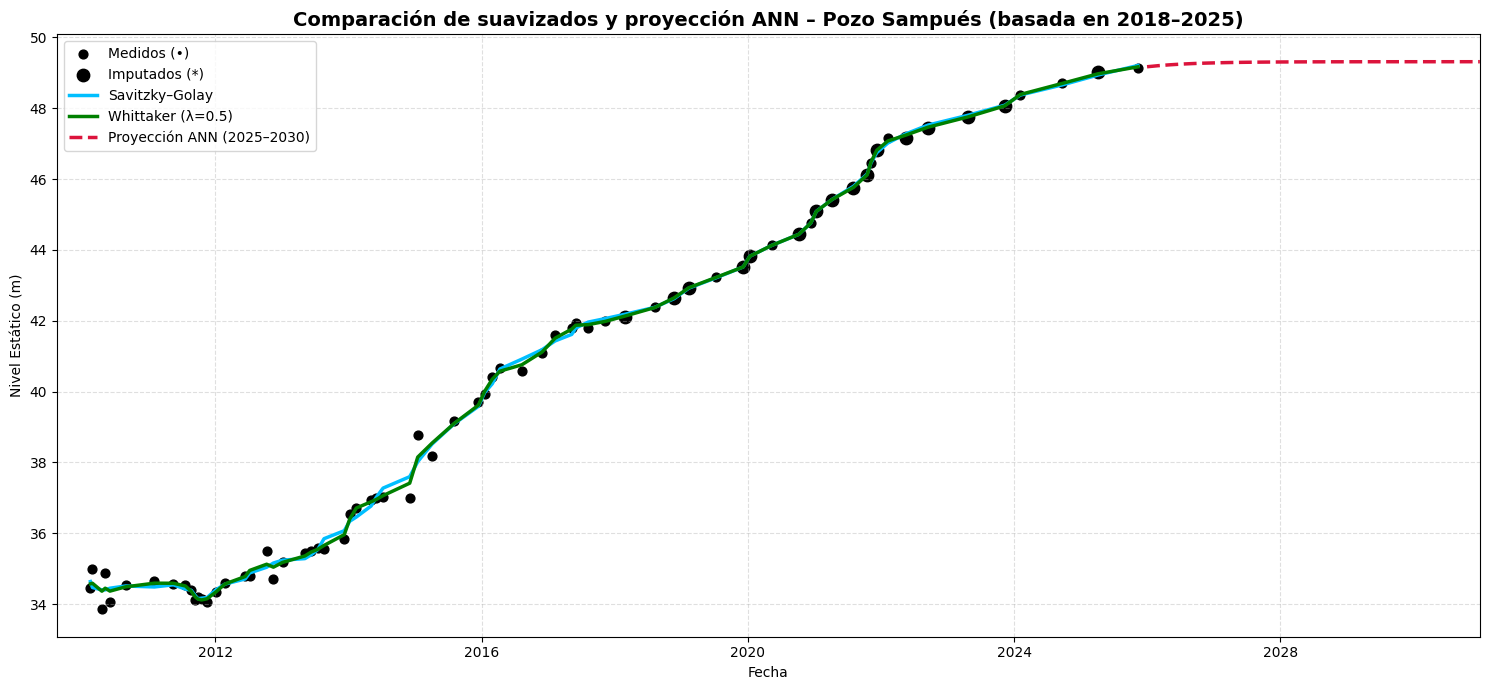

In [ ]:
# ======================================================
# Pozo Sampués – # 52-II-C-PZ-01 – Comparación de suavizados + ANN 2025–2030
# (Basado únicamente en datos recientes 2018–2025)
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------
# 1️⃣ Datos del pozo #52-II-C-PZ-01 (Sampués)
# -----------------------------------------------
data = {
    'Fecha': [
        '15/02/2010','26/02/2010','19/04/2010','07/05/2010','02/06/2010','27/08/2010',
        '01/02/2011','16/05/2011','21/07/2011','22/08/2011','14/09/2011','28/09/2011',
        '18/10/2011','17/11/2011','03/01/2012','24/02/2012','13/06/2012','08/07/2012',
        '09/10/2012','15/11/2012','04/01/2013','07/05/2013','12/06/2013','16/07/2013',
        '20/08/2013','09/12/2013','08/01/2014','13/02/2014','05/05/2014','03/06/2014',
        '10/07/2014','03/12/2014','16/01/2015','05/04/2015','05/08/2015','15/12/2015',
        '18/01/2016','29/02/2016','11/04/2016','09/08/2016','28/11/2016','08/02/2017',
        '10/05/2017','01/06/2017','08/08/2017','09/11/2017','01/03/2018','08/08/2018',
        '23/11/2018','12/02/2019','11/07/2019','07/12/2019','12/01/2020','11/05/2020',
        '07/10/2020','12/12/2020','11/01/2021','07/04/2021','03/08/2021','17/10/2021',
        '07/11/2021','09/12/2021','08/02/2022','16/05/2022','17/09/2022','22/04/2023',
        '11/11/2023','05/02/2024','22/09/2024','06/04/2025','11/11/2025'
    ],
    'Nivel_Estatico_m': [
        34.45,34.98,33.85,34.87,34.07,34.55,34.65,34.57,34.54,34.39,34.10,34.19,34.15,
        34.05,34.35,34.60,34.80,34.80,35.49,34.72,35.20,35.43,35.50,35.58,35.55,35.85,
        36.54,36.72,36.95,36.98,37.03,36.98,38.76,38.19,39.17,39.69,39.93,40.42,40.65,
        40.57,41.10,41.59,41.79,41.93,41.80,41.99,42.107111,42.37704237,42.65289932,
        42.93477741,43.22277417,43.51698905,43.81752341,44.1244806,44.43796586,
        44.7580864,45.08495134,45.41867175,45.75936065,46.10713297,46.4621056,
        46.82439736,47.17,47.15234246,47.45189065,47.75630129,48.06563814,48.37996574,
        48.69934942,49.02385527,49.13
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Clasificar datos imputados (asteriscos)
# -----------------------------------------------
fechas_imputadas = [
    '01/03/2018','23/11/2018','12/02/2019','07/12/2019',
    '12/01/2020','07/10/2020','11/01/2021','07/04/2021',
    '03/08/2021','17/10/2021','09/12/2021','16/05/2022',
    '17/09/2022','22/04/2023','11/11/2023','06/04/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados
# ======================================================
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=0.5)

# ======================================================
# 4️⃣ Métricas comparativas
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', 'Whittaker']).round(4)
print('\n📊 Comparación de suavizadores (RMSE, MAE, R²):\n', tabla)

# ======================================================
# 5️⃣ Preparación de datos para LSTM (solo 2018–2025)
# ======================================================
serie = df[['Fecha', 'Whittaker']].set_index('Fecha').resample('M').mean().interpolate()

# Filtrar solo los datos desde 2018
fecha_corte = pd.Timestamp('2018-01-01')
serie_reciente = serie[serie.index >= fecha_corte].copy()

print(f"\n📅 Serie usada para LSTM: {len(serie_reciente)} meses")
print(f"   Desde: {serie_reciente.index[0].date()}  Hasta: {serie_reciente.index[-1].date()}")

# Escalado
scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(serie_reciente)

# Secuencias
def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
X_train, y_train = X, y  # usar toda la serie reciente

# ======================================================
# 6️⃣ Modelo LSTM ajustado
# ======================================================
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(window,1)),
    LSTM(64, activation='tanh', return_sequences=True),
    LSTM(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=600, batch_size=2, verbose=0)

print("✅ Modelo LSTM entrenado (basado en tendencia reciente 2018–2025)")

# ======================================================
# 7️⃣ Proyección hasta 2030 (continuación)
# ======================================================
ultima_fecha = serie.index[-1]
fecha_final = pd.Timestamp('2030-12-31')
meses_proyectar = (fecha_final.year - ultima_fecha.year)*12 + (fecha_final.month - ultima_fecha.month)

last_seq = scaled[-window:]
preds = []
for _ in range(meses_proyectar):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    last_seq = np.append(last_seq[1:], pred)[-window:]

fechas_futuras = pd.date_range(start=ultima_fecha + pd.offsets.MonthEnd(1),
                               periods=meses_proyectar, freq='M')

df_proyeccion = pd.DataFrame({
    'Fecha': fechas_futuras,
    'Nivel_Proyectado': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

# ======================================================
# 8️⃣ Gráfico final
# ======================================================
plt.figure(figsize=(15,7))
plt.scatter(df.loc[~df['Imputado'],'Fecha'], df.loc[~df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=40, label='Medidos (•)')
plt.scatter(df.loc[df['Imputado'],'Fecha'], df.loc[df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=80, label='Imputados (*)')
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2.5, label='Savitzky–Golay')
plt.plot(df['Fecha'], df['Whittaker'], color='green', linewidth=2.5, label='Whittaker (λ=0.5)')
plt.plot(df_proyeccion['Fecha'], df_proyeccion['Nivel_Proyectado'],
         color='crimson', linestyle='--', linewidth=2.5, label='Proyección ANN (2025–2030)')

plt.title('Comparación de suavizados y proyección ANN – Pozo Sampués (basada en 2018–2025)',
          fontsize=14, weight='bold')
plt.xlabel('Fecha'); plt.ylabel('Nivel Estático (m)')
plt.xlim(df['Fecha'].min() - pd.DateOffset(months=6), pd.Timestamp('2031-01-01'))
plt.legend(); plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()


ESTE PUEDE SER EL ALGORITMO DEFINITIVO



📊 Comparación de suavizadores (RMSE, MAE, R²):

                  RMSE     MAE      R²
Savitzky–Golay  0.2861  0.1996  0.8345
Whittaker       0.2323  0.1536  0.8909


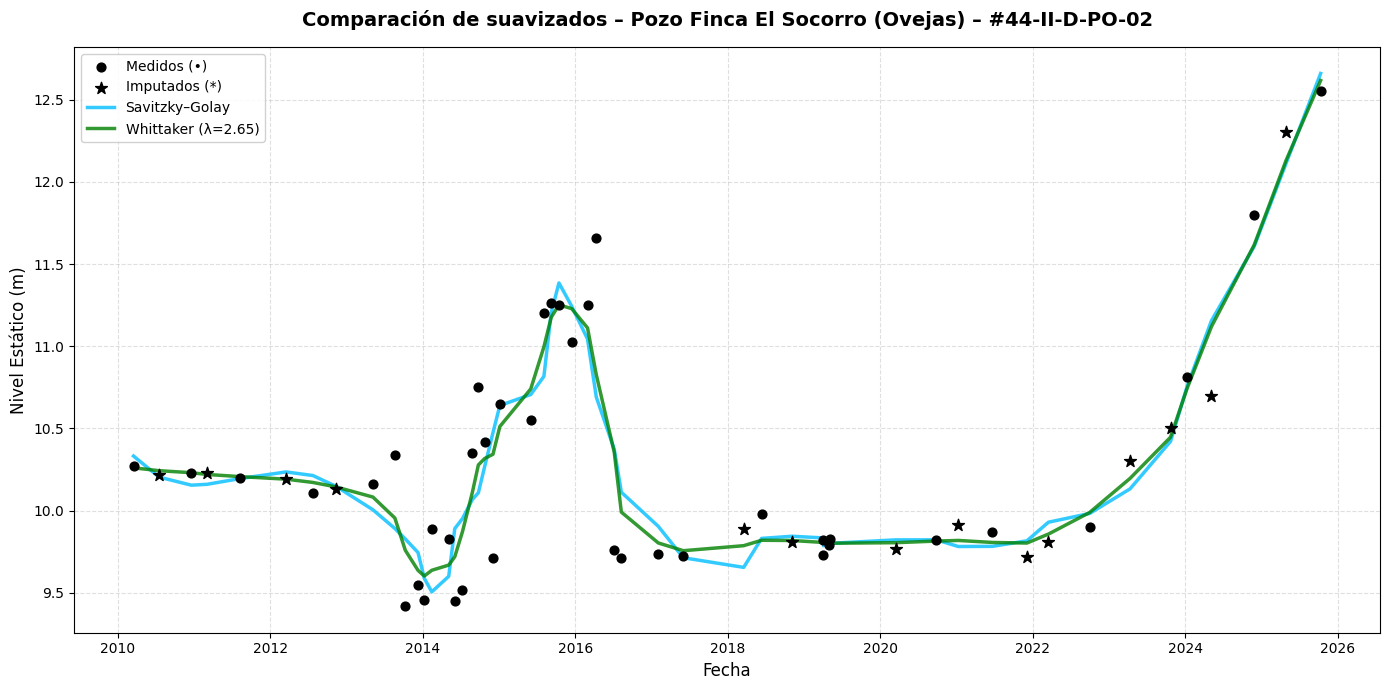


✅ Archivo exportado: comparacion_suavizadores_44_II_D_PO_02.csv


In [ ]:
# ======================================================
# Pozo Finca El Socorro (Ovejas) – #44-II-D-PO-02
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------------------------
# 1️⃣ Datos del pozo
# -----------------------------------------------
data = {
    'Fecha': [
        '17/03/2010','18/07/2010','19/12/2010','5/03/2011','11/08/2011','17/03/2012',
        '23/07/2012','12/11/2012','7/05/2013','20/08/2013','9/10/2013','9/12/2013',
        '8/01/2014','13/02/2014','5/05/2014','3/06/2014','10/07/2014','26/08/2014',
        '24/09/2014','24/10/2014','3/12/2014','5/01/2015','2/06/2015','4/08/2015',
        '8/09/2015','15/10/2015','15/12/2015','29/02/2016','11/04/2016','6/07/2016',
        '9/08/2016','2/02/2017','2/06/2017','18/03/2018','12/06/2018','5/11/2018',
        '4/04/2019','5/05/2019','4/04/2019','3/05/2019','15/03/2020','26/09/2020',
        '9/01/2021','22/06/2021','4/12/2021','17/03/2022','30/09/2022','12/04/2023',
        '23/10/2023','11/01/2024','6/05/2024','27/11/2024','28/04/2025','11/10/2025'
    ],
    'Nivel_Estatico_m': [
        10.27436,10.22,10.23,10.232,10.2,10.19,10.11,10.13,10.16,10.34,9.42,9.55,
        9.46,9.89,9.83,9.45,9.52,10.35,10.75,10.42,9.71,10.6483,10.55,11.2,11.26,
        11.25,11.026,11.25,11.66,9.76,9.71,9.735,9.723,9.89,9.98,9.81,9.729,9.826,
        9.82,9.792,9.77,9.82,9.912,9.873,9.72,9.81,9.9,10.3,10.5,10.81,10.7,11.8,
        12.3,12.55
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Fechas imputadas
# -----------------------------------------------
fechas_imputadas = [
    '18/07/2010','5/03/2011','17/03/2012','12/11/2012','18/03/2018','5/11/2018','15/03/2020','9/01/2021',
    '4/12/2021','17/03/2022','12/04/2023','23/10/2023','6/05/2024','28/04/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados: Savitzky–Golay y Whittaker
# ======================================================
# Savitzky–Golay
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

# Whittaker (λ=0.5)
def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=2.65)

# ======================================================
# 4️⃣ Comparación de suavizadores (RMSE, MAE, R²)
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', 'Whittaker']).round(4)
print('\n📊 Comparación de suavizadores (RMSE, MAE, R²):\n')
print(tabla)

# ======================================================
# 5️⃣ Gráfico de resultados
# ======================================================
plt.figure(figsize=(14,7))

# Puntos medidos e imputados
plt.scatter(df.loc[~df['Imputado'], 'Fecha'], df.loc[~df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=40, label='Medidos (•)', marker='o', zorder=4)
plt.scatter(df.loc[df['Imputado'], 'Fecha'], df.loc[df['Imputado'], 'Nivel_Estatico_m'],
            color='black', s=80, label='Imputados (*)', marker='*', zorder=4)

# Suavizados
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2.5,
         label='Savitzky–Golay', alpha=0.8)
plt.plot(df['Fecha'], df['Whittaker'], color='green', linewidth=2.5,
         label='Whittaker (λ=2.65)', alpha=0.8)

# Configuración del gráfico
plt.title('Comparación de suavizados – Pozo Finca El Socorro (Ovejas) – #44-II-D-PO-02',
          fontsize=14, weight='bold', pad=15)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Nivel Estático (m)', fontsize=12)
plt.legend(loc='best', fontsize=10, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ======================================================
# 6️⃣ Exportar resultados
# ======================================================
tabla.to_csv('comparacion_suavizadores_44_II_D_PO_02.csv', index=True)
print("\n✅ Archivo exportado: comparacion_suavizadores_44_II_D_PO_02.csv")



📊 Comparación de suavizadores:

                      RMSE     MAE      R²
Savitzky–Golay      0.2861  0.1996  0.8345
Whittaker (λ=0.65)  0.1815  0.1161  0.9334
✅ Modelo LSTM entrenado para proyección 2025–2030

🔗 Punto de conexión:
   Fecha: 2025-10-31
   Valor: 12.62 m
   Siguiente predicción: 11.60 m


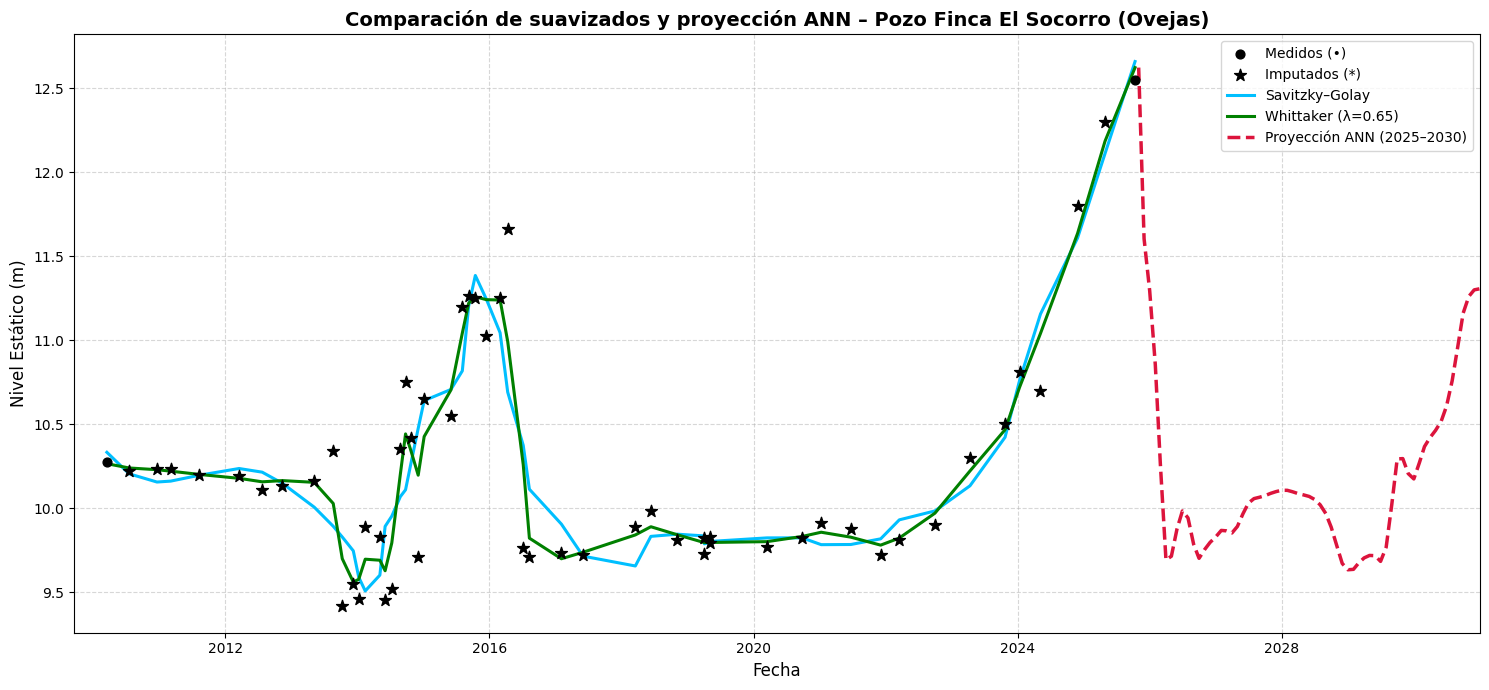


✅ Archivos exportados:
   - comparacion_suavizadores_44_II_D_PO_02.csv
   - proyeccion_ann_44_II_D_PO_02.csv
   - proyeccion_ann_continua_44_II_D_PO_02.csv


In [ ]:
# ======================================================
# Pozo Finca El Socorro (Ovejas) – #44-II-D-PO-02
# Con proyección ANN CONTINUA desde 2025
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------
# 1️⃣ Datos del pozo
# -----------------------------------------------
data = {
    'Fecha': [
        '17/03/2010','18/07/2010','19/12/2010','5/03/2011','11/08/2011','17/03/2012',
        '23/07/2012','12/11/2012','7/05/2013','20/08/2013','9/10/2013','9/12/2013',
        '8/01/2014','13/02/2014','5/05/2014','3/06/2014','10/07/2014','26/08/2014',
        '24/09/2014','24/10/2014','3/12/2014','5/01/2015','2/06/2015','4/08/2015',
        '8/09/2015','15/10/2015','15/12/2015','29/02/2016','11/04/2016','6/07/2016',
        '9/08/2016','2/02/2017','2/06/2017','18/03/2018','12/06/2018','5/11/2018',
        '4/04/2019','5/05/2019','4/04/2019','3/05/2019','15/03/2020','26/09/2020',
        '9/01/2021','22/06/2021','4/12/2021','17/03/2022','30/09/2022','12/04/2023',
        '23/10/2023','11/01/2024','6/05/2024','27/11/2024','28/04/2025','11/10/2025'
    ],
    'Nivel_Estatico_m': [
        10.27436,10.22,10.23,10.232,10.2,10.19,10.11,10.13,10.16,10.34,9.42,9.55,
        9.46,9.89,9.83,9.45,9.52,10.35,10.75,10.42,9.71,10.6483,10.55,11.2,11.26,
        11.25,11.026,11.25,11.66,9.76,9.71,9.735,9.723,9.89,9.98,9.81,9.729,9.826,
        9.82,9.792,9.77,9.82,9.912,9.873,9.72,9.81,9.9,10.3,10.5,10.81,10.7,11.8,
        12.3,12.55
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Fechas imputadas
# -----------------------------------------------
fechas_imputadas = [
    '18/07/2010','19/12/2010','5/03/2011','11/08/2011','17/03/2012','23/07/2012',
    '12/11/2012','7/05/2013','20/08/2013','9/10/2013','9/12/2013','8/01/2014',
    '13/02/2014','5/05/2014','3/06/2014','10/07/2014','26/08/2014','24/09/2014',
    '24/10/2014','3/12/2014','5/01/2015','2/06/2015','4/08/2015','8/09/2015',
    '15/10/2015','15/12/2015','29/02/2016','11/04/2016','6/07/2016','9/08/2016',
    '2/02/2017','2/06/2017','18/03/2018','12/06/2018','5/11/2018','4/04/2019',
    '5/05/2019','4/04/2019','3/05/2019','15/03/2020','26/09/2020','9/01/2021',
    '22/06/2021','4/12/2021','17/03/2022','30/09/2022','12/04/2023','23/10/2023',
    '11/01/2024','6/05/2024','27/11/2024','28/04/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados (Savitzky–Golay y Whittaker λ=0.65)
# ======================================================
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=0.65)

# ======================================================
# 4️⃣ Comparación de suavizadores
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', 'Whittaker (λ=0.65)']).round(4)
print("\n📊 Comparación de suavizadores:\n")
print(tabla)

# ======================================================
# 5️⃣ Preparación de datos para LSTM
# ======================================================
serie = df[['Fecha', 'Whittaker']].set_index('Fecha').resample('M').mean().interpolate()
scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(serie)

def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
split = int(len(X)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(window,1)),
    LSTM(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=400, batch_size=4, verbose=0)
print("✅ Modelo LSTM entrenado para proyección 2025–2030")

# ======================================================
# 6️⃣ Proyección ANN hasta 2030
# ======================================================
last_date = serie.index[-1]
future_months = (2030 - last_date.year)*12 + (12 - last_date.month)
last_seq = scaled[-window:]
preds = []

for _ in range(future_months):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    last_seq = np.append(last_seq[1:], pred)[-window:]

future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(1),
                             periods=future_months, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

# ======================================================
# 🔧 CLAVE: Crear serie CONTINUA (histórico + proyección)
# ======================================================
# Obtener el último valor histórico del suavizado Whittaker
ultimo_valor_historico = serie.iloc[-1].values[0]
ultima_fecha_historica = serie.index[-1]

# Crear DataFrame combinado para línea continua
proyeccion_continua = pd.DataFrame({
    'Fecha': [ultima_fecha_historica] + future_df['Fecha'].tolist(),
    'Nivel': [ultimo_valor_historico] + future_df['Nivel_Predicho'].tolist()
})

print(f"\n🔗 Punto de conexión:")
print(f"   Fecha: {ultima_fecha_historica.date()}")
print(f"   Valor: {ultimo_valor_historico:.2f} m")
print(f"   Siguiente predicción: {future_df['Nivel_Predicho'].iloc[0]:.2f} m")

# ======================================================
# 7️⃣ Gráfico final con línea CONTINUA
# ======================================================
plt.figure(figsize=(15,7))

# Datos medidos e imputados
plt.scatter(df.loc[~df['Imputado'],'Fecha'], df.loc[~df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=40, label='Medidos (•)', marker='o', zorder=4)
plt.scatter(df.loc[df['Imputado'],'Fecha'], df.loc[df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=80, label='Imputados (*)', marker='*', zorder=4)

# Suavizados (solo histórico)
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2.2, label='Savitzky–Golay')
plt.plot(df['Fecha'], df['Whittaker'], color='green', linewidth=2.2, label='Whittaker (λ=0.65)')

# Proyección ANN CONTINUA (incluye punto de conexión)
plt.plot(proyeccion_continua['Fecha'], proyeccion_continua['Nivel'],
         color='crimson', linestyle='--', linewidth=2.5, label='Proyección ANN (2025–2030)', zorder=3)

# Formato
plt.title('Comparación de suavizados y proyección ANN – Pozo Finca El Socorro (Ovejas)',
          fontsize=14, weight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Nivel Estático (m)', fontsize=12)
plt.xlim(df['Fecha'].min() - pd.DateOffset(months=6), pd.Timestamp('2031-01-01'))
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ======================================================
# 8️⃣ Exportar resultados
# ======================================================
tabla.to_csv('comparacion_suavizadores_44_II_D_PO_02.csv')
future_df.to_csv('proyeccion_ann_44_II_D_PO_02.csv', index=False)
proyeccion_continua.to_csv('proyeccion_ann_continua_44_II_D_PO_02.csv', index=False)

print("\n✅ Archivos exportados:")
print("   - comparacion_suavizadores_44_II_D_PO_02.csv")
print("   - proyeccion_ann_44_II_D_PO_02.csv")
print("   - proyeccion_ann_continua_44_II_D_PO_02.csv")


INCLUIR ESTE ALGORITMO EN KA TESIS


📊 Comparación de suavizadores:

                      RMSE     MAE      R²
Savitzky–Golay      0.2861  0.1996  0.8345
Whittaker (λ=0.65)  0.1815  0.1161  0.9334

📊 Datos para entrenamiento:
   Serie completa: 188 meses
   Serie desde 2018-01-01: 94 meses
   Tendencia reciente: 9.82 → 12.62 m
   Secuencias de entrenamiento: 82
✅ Modelo LSTM entrenado con datos desde 2018 (tendencia ascendente)

🔮 Proyección desde 2025-10-31 hasta dic 2030 (62 meses)

🔗 Punto de conexión:
   Fecha: 2025-10-31
   Valor: 12.62 m
   Siguiente predicción: 12.60 m


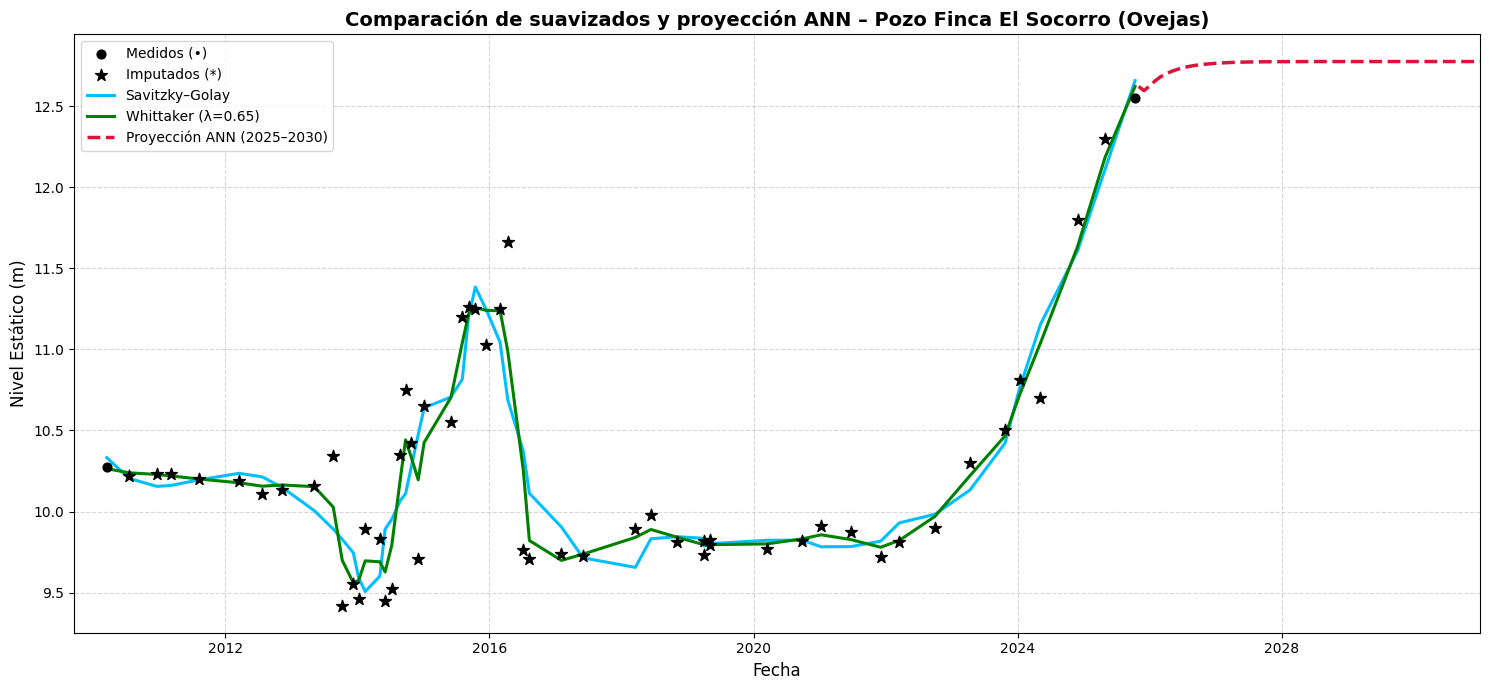


✅ Archivos exportados:
   - comparacion_suavizadores_44_II_D_PO_02.csv
   - proyeccion_ann_44_II_D_PO_02.csv
   - proyeccion_ann_continua_44_II_D_PO_02.csv


In [ ]:
# ======================================================
# Pozo Finca El Socorro (Ovejas) – #44-II-D-PO-02
# Con proyección ANN CONTINUA desde 2025
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------
# 1️⃣ Datos del pozo
# -----------------------------------------------
data = {
    'Fecha': [
        '17/03/2010','18/07/2010','19/12/2010','5/03/2011','11/08/2011','17/03/2012',
        '23/07/2012','12/11/2012','7/05/2013','20/08/2013','9/10/2013','9/12/2013',
        '8/01/2014','13/02/2014','5/05/2014','3/06/2014','10/07/2014','26/08/2014',
        '24/09/2014','24/10/2014','3/12/2014','5/01/2015','2/06/2015','4/08/2015',
        '8/09/2015','15/10/2015','15/12/2015','29/02/2016','11/04/2016','6/07/2016',
        '9/08/2016','2/02/2017','2/06/2017','18/03/2018','12/06/2018','5/11/2018',
        '4/04/2019','5/05/2019','4/04/2019','3/05/2019','15/03/2020','26/09/2020',
        '9/01/2021','22/06/2021','4/12/2021','17/03/2022','30/09/2022','12/04/2023',
        '23/10/2023','11/01/2024','6/05/2024','27/11/2024','28/04/2025','11/10/2025'
    ],
    'Nivel_Estatico_m': [
        10.27436,10.22,10.23,10.232,10.2,10.19,10.11,10.13,10.16,10.34,9.42,9.55,
        9.46,9.89,9.83,9.45,9.52,10.35,10.75,10.42,9.71,10.6483,10.55,11.2,11.26,
        11.25,11.026,11.25,11.66,9.76,9.71,9.735,9.723,9.89,9.98,9.81,9.729,9.826,
        9.82,9.792,9.77,9.82,9.912,9.873,9.72,9.81,9.9,10.3,10.5,10.81,10.7,11.8,
        12.3,12.55
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Fechas imputadas
# -----------------------------------------------
fechas_imputadas = [
    '18/07/2010','19/12/2010','5/03/2011','11/08/2011','17/03/2012','23/07/2012',
    '12/11/2012','7/05/2013','20/08/2013','9/10/2013','9/12/2013','8/01/2014',
    '13/02/2014','5/05/2014','3/06/2014','10/07/2014','26/08/2014','24/09/2014',
    '24/10/2014','3/12/2014','5/01/2015','2/06/2015','4/08/2015','8/09/2015',
    '15/10/2015','15/12/2015','29/02/2016','11/04/2016','6/07/2016','9/08/2016',
    '2/02/2017','2/06/2017','18/03/2018','12/06/2018','5/11/2018','4/04/2019',
    '5/05/2019','4/04/2019','3/05/2019','15/03/2020','26/09/2020','9/01/2021',
    '22/06/2021','4/12/2021','17/03/2022','30/09/2022','12/04/2023','23/10/2023',
    '11/01/2024','6/05/2024','27/11/2024','28/04/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados (Savitzky–Golay y Whittaker λ=0.65)
# ======================================================
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=0.65)

# ======================================================
# 4️⃣ Comparación de suavizadores
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', 'Whittaker (λ=0.65)']).round(4)
print("\n📊 Comparación de suavizadores:\n")
print(tabla)

# ======================================================
# 5️⃣ Preparación de datos para LSTM (ENFOQUE EN TENDENCIA RECIENTE)
# ======================================================
serie = df[['Fecha', 'Whittaker']].set_index('Fecha').resample('M').mean().interpolate()

# 🔧 FILTRAR DATOS DESDE 2018 para capturar solo la tendencia ascendente
fecha_corte = pd.Timestamp('2018-01-01')
serie_reciente = serie[serie.index >= fecha_corte].copy()

print(f"\n📊 Datos para entrenamiento:")
print(f"   Serie completa: {len(serie)} meses")
print(f"   Serie desde {fecha_corte.date()}: {len(serie_reciente)} meses")
print(f"   Tendencia reciente: {serie_reciente.iloc[0].values[0]:.2f} → {serie_reciente.iloc[-1].values[0]:.2f} m")

# Escalar solo la serie reciente
scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(serie_reciente)

def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)

# Usar TODA la serie reciente para entrenamiento (sin división)
# ya que queremos que el modelo aprenda completamente la tendencia ascendente
X_train, y_train = X, y

print(f"   Secuencias de entrenamiento: {len(X_train)}")

# Modelo LSTM con mayor capacidad para capturar tendencia
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(window,1)),
    LSTM(64, activation='tanh', return_sequences=True),
    LSTM(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=600, batch_size=2, verbose=0)
print("✅ Modelo LSTM entrenado con datos desde 2018 (tendencia ascendente)")

# ======================================================
# 6️⃣ Proyección ANN hasta 2030 (CONTINUA DESDE TENDENCIA RECIENTE)
# ======================================================
# Usar la última fecha de la serie completa (no solo la reciente)
last_date = serie.index[-1]
future_months = (2030 - last_date.year)*12 + (12 - last_date.month)

# Usar los últimos 12 meses de datos escalados para iniciar la proyección
last_seq = scaled[-window:]
preds = []

print(f"\n🔮 Proyección desde {last_date.date()} hasta dic 2030 ({future_months} meses)")

for i in range(future_months):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    # Actualizar secuencia con la predicción (sin ruido para mantener tendencia)
    last_seq = np.append(last_seq[1:], pred)[-window:]

future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(1),
                             periods=future_months, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

# ======================================================
# 🔧 CLAVE: Crear serie CONTINUA (histórico + proyección)
# ======================================================
# Obtener el último valor histórico del suavizado Whittaker
ultimo_valor_historico = serie.iloc[-1].values[0]
ultima_fecha_historica = serie.index[-1]

# Crear DataFrame combinado para línea continua
proyeccion_continua = pd.DataFrame({
    'Fecha': [ultima_fecha_historica] + future_df['Fecha'].tolist(),
    'Nivel': [ultimo_valor_historico] + future_df['Nivel_Predicho'].tolist()
})

print(f"\n🔗 Punto de conexión:")
print(f"   Fecha: {ultima_fecha_historica.date()}")
print(f"   Valor: {ultimo_valor_historico:.2f} m")
print(f"   Siguiente predicción: {future_df['Nivel_Predicho'].iloc[0]:.2f} m")

# ======================================================
# 7️⃣ Gráfico final con línea CONTINUA
# ======================================================
plt.figure(figsize=(15,7))

# Datos medidos e imputados
plt.scatter(df.loc[~df['Imputado'],'Fecha'], df.loc[~df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=40, label='Medidos (•)', marker='o', zorder=4)
plt.scatter(df.loc[df['Imputado'],'Fecha'], df.loc[df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=80, label='Imputados (*)', marker='*', zorder=4)

# Suavizados (solo histórico)
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2.2, label='Savitzky–Golay')
plt.plot(df['Fecha'], df['Whittaker'], color='green', linewidth=2.2, label='Whittaker (λ=0.65)')

# Proyección ANN CONTINUA (incluye punto de conexión)
plt.plot(proyeccion_continua['Fecha'], proyeccion_continua['Nivel'],
         color='crimson', linestyle='--', linewidth=2.5, label='Proyección ANN (2025–2030)', zorder=3)

# Formato
plt.title('Comparación de suavizados y proyección ANN – Pozo Finca El Socorro (Ovejas)',
          fontsize=14, weight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Nivel Estático (m)', fontsize=12)
plt.xlim(df['Fecha'].min() - pd.DateOffset(months=6), pd.Timestamp('2031-01-01'))
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ======================================================
# 8️⃣ Exportar resultados
# ======================================================
tabla.to_csv('comparacion_suavizadores_44_II_D_PO_02.csv')
future_df.to_csv('proyeccion_ann_44_II_D_PO_02.csv', index=False)
proyeccion_continua.to_csv('proyeccion_ann_continua_44_II_D_PO_02.csv', index=False)

print("\n✅ Archivos exportados:")
print("   - comparacion_suavizadores_44_II_D_PO_02.csv")
print("   - proyeccion_ann_44_II_D_PO_02.csv")
print("   - proyeccion_ann_continua_44_II_D_PO_02.csv")



```
# Esto tiene formato de código
```

# Pozo Ovejas - # 44-II-D-PO-14


📊 Comparación de suavizadores:

                     RMSE     MAE      R²
Savitzky–Golay     0.7498  0.5280  0.9245
Whittaker (λ=2.5)  0.6395  0.4319  0.9451

📈 Entrenamiento desde 2018-01-01 (93 meses)
   Tendencia: 7.45 → 7.32 m
✅ Modelo LSTM entrenado con tendencia reciente


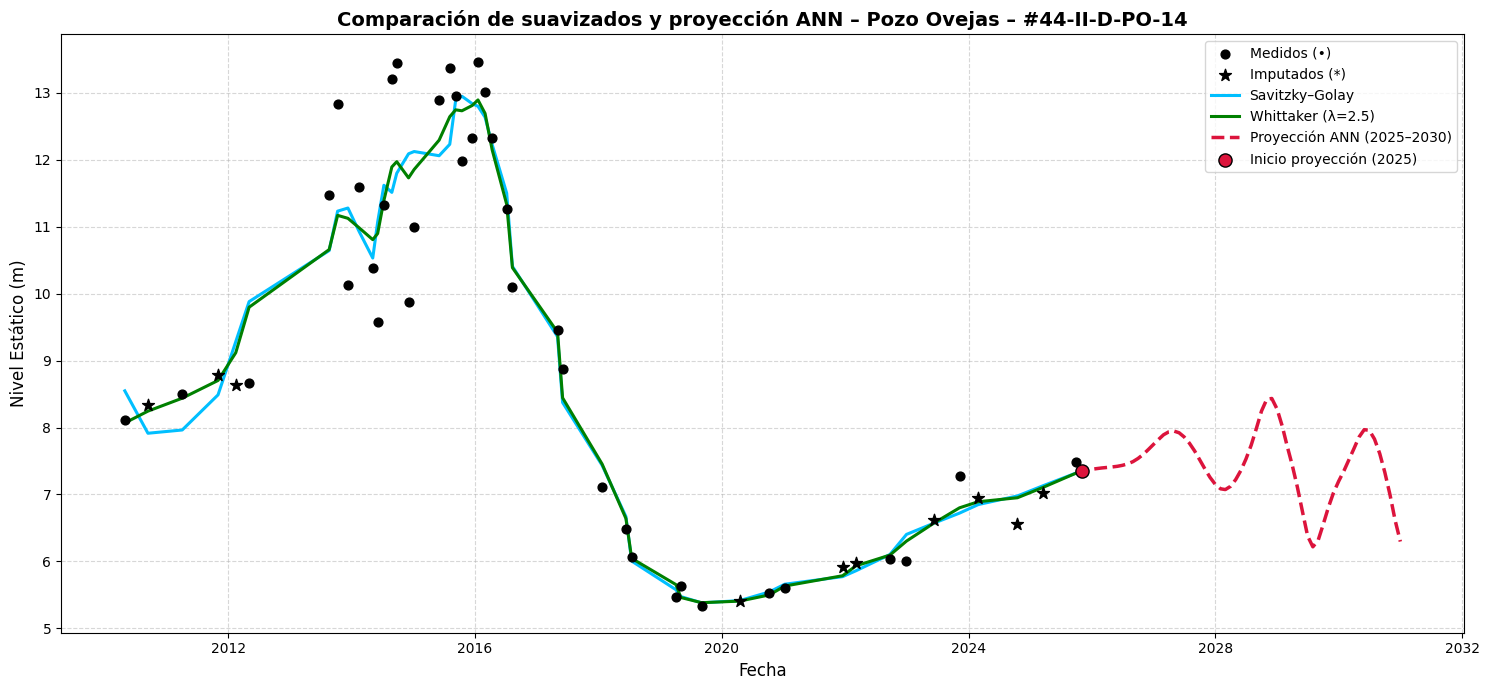


✅ Archivos exportados:
   - comparacion_suavizadores_44_II_D_PO_14.csv
   - proyeccion_ann_44_II_D_PO_14.csv
   - proyeccion_ann_continua_44_II_D_PO_14.csv


In [ ]:
# ======================================================
# Pozo Ovejas – #44-II-D-PO-14
# Con proyección ANN continua desde 2025
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------
# 1️⃣ Datos del pozo
# -----------------------------------------------
data = {
    'Fecha': [
        '28/04/2010','12/09/2010','3/04/2011','1/11/2011','14/02/2012','3/05/2012',
        '20/08/2013','9/10/2013','9/12/2013','13/02/2014','5/05/2014','3/06/2014',
        '10/07/2014','26/08/2014','24/09/2014','3/12/2014','5/01/2015','2/06/2015',
        '4/08/2015','8/09/2015','15/10/2015','15/12/2015','18/01/2016','29/02/2016',
        '11/04/2016','6/07/2016','9/08/2016','3/05/2017','2/06/2017','22/01/2018',
        '12/06/2018','16/07/2018','4/04/2019','3/05/2019','3/09/2019','15/04/2020',
        '8/10/2020','7/01/2021','16/12/2021','5/03/2022','22/09/2022','29/12/2022',
        '11/06/2023','8/11/2023','27/02/2024','16/10/2024','15/03/2025','30/09/2025'
    ],
    'Nivel_Estatico_m': [
        8.11,8.34,8.5,8.79,8.63,8.67,11.48,12.83,10.13,11.6,10.38,9.57,11.32,13.21,
        13.45,9.87,10.99,12.9,13.37,12.95,11.98,12.32,13.47,13.02,12.32,11.27,10.1,
        9.46,8.87,7.11,6.49,6.07,5.46,5.63,5.34,5.41,5.53,5.6,5.91,5.97,6.04,6.00,
        6.62,7.28,6.95,6.56,7.02,7.48
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Fechas imputadas
# -----------------------------------------------
fechas_imputadas = [
    '12/09/2010','1/11/2011','14/02/2012','15/04/2020','16/12/2021',
    '5/03/2022','11/06/2023','27/02/2024','16/10/2024','15/03/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados (Savitzky–Golay y Whittaker λ=0.6)
# ======================================================
window = 9 if len(df) >= 9 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

λ = 2.5
df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=λ)

# ======================================================
# 4️⃣ Comparación de suavizadores
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', f'Whittaker (λ={λ})']).round(4)
print("\n📊 Comparación de suavizadores:\n")
print(tabla)

# ======================================================
# 5️⃣ Preparación de datos para LSTM (últimos 7 años)
# ======================================================
serie = df[['Fecha', 'Whittaker']].set_index('Fecha').resample('M').mean().interpolate()
fecha_corte = pd.Timestamp('2018-01-01')
serie_reciente = serie[serie.index >= fecha_corte].copy()

print(f"\n📈 Entrenamiento desde {fecha_corte.date()} ({len(serie_reciente)} meses)")
print(f"   Tendencia: {serie_reciente.iloc[0].values[0]:.2f} → {serie_reciente.iloc[-1].values[0]:.2f} m")

# Escalado
scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(serie_reciente)

def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
X_train, y_train = X, y

# ======================================================
# 6️⃣ Modelo LSTM y entrenamiento
# ======================================================
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(window,1)),
    LSTM(64, activation='tanh', return_sequences=True),
    LSTM(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=500, batch_size=2, verbose=0)
print("✅ Modelo LSTM entrenado con tendencia reciente")

# ======================================================
# 7️⃣ Proyección ANN hasta 2030 (continua)
# ======================================================
last_date = serie.index[-1]
future_months = (2030 - last_date.year)*12 + (12 - last_date.month)

last_seq = scaled[-window:]
preds = []

for _ in range(future_months):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    last_seq = np.append(last_seq[1:], pred)[-window:]

future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(1),
                             periods=future_months, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

# Serie combinada
ultimo_valor_historico = serie.iloc[-1].values[0]
ultima_fecha_historica = serie.index[-1]
proyeccion_continua = pd.DataFrame({
    'Fecha': [ultima_fecha_historica] + future_df['Fecha'].tolist(),
    'Nivel': [ultimo_valor_historico] + future_df['Nivel_Predicho'].tolist()
})

# ======================================================
# 8️⃣ Gráfico final
# ======================================================
plt.figure(figsize=(15,7))

# Medidos e imputados
plt.scatter(df.loc[~df['Imputado'],'Fecha'], df.loc[~df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=40, label='Medidos (•)', marker='o', zorder=4)
plt.scatter(df.loc[df['Imputado'],'Fecha'], df.loc[df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=80, label='Imputados (*)', marker='*', zorder=4)

# Suavizados
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2.2, label='Savitzky–Golay')
plt.plot(df['Fecha'], df['Whittaker'], color='green', linewidth=2.2, label=f'Whittaker (λ={λ})')

# Proyección ANN
plt.plot(proyeccion_continua['Fecha'], proyeccion_continua['Nivel'],
         color='crimson', linestyle='--', linewidth=2.5, label='Proyección ANN (2025–2030)', zorder=3)
plt.scatter(future_df['Fecha'].iloc[0], future_df['Nivel_Predicho'].iloc[0],
            color='crimson', edgecolors='k', s=90, zorder=5, label='Inicio proyección (2025)')

# Formato
plt.title('Comparación de suavizados y proyección ANN – Pozo Ovejas – #44-II-D-PO-14',
          fontsize=14, weight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Nivel Estático (m)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ======================================================
# 9️⃣ Exportar resultados
# ======================================================
tabla.to_csv('comparacion_suavizadores_44_II_D_PO_14.csv')
future_df.to_csv('proyeccion_ann_44_II_D_PO_14.csv', index=False)
proyeccion_continua.to_csv('proyeccion_ann_continua_44_II_D_PO_14.csv', index=False)

print("\n✅ Archivos exportados:")
print("   - comparacion_suavizadores_44_II_D_PO_14.csv")
print("   - proyeccion_ann_44_II_D_PO_14.csv")
print("   - proyeccion_ann_continua_44_II_D_PO_14.csv")


pozo Los Palmitos – #44-IV-B-PZ-01 (Piñal)

1.   Elemento de la lista
2.   Elemento de la lista




📊 Comparación de suavizadores:

                     RMSE     MAE      R²
Savitzky–Golay     0.2190  0.1286  0.9951
Whittaker (λ=2.5)  0.2145  0.1228  0.9953

📈 Entrenamiento desde 2018-01-01 (95 meses)
   Tendencia: 77.89 → 74.39 m
✅ Modelo LSTM entrenado con tendencia reciente


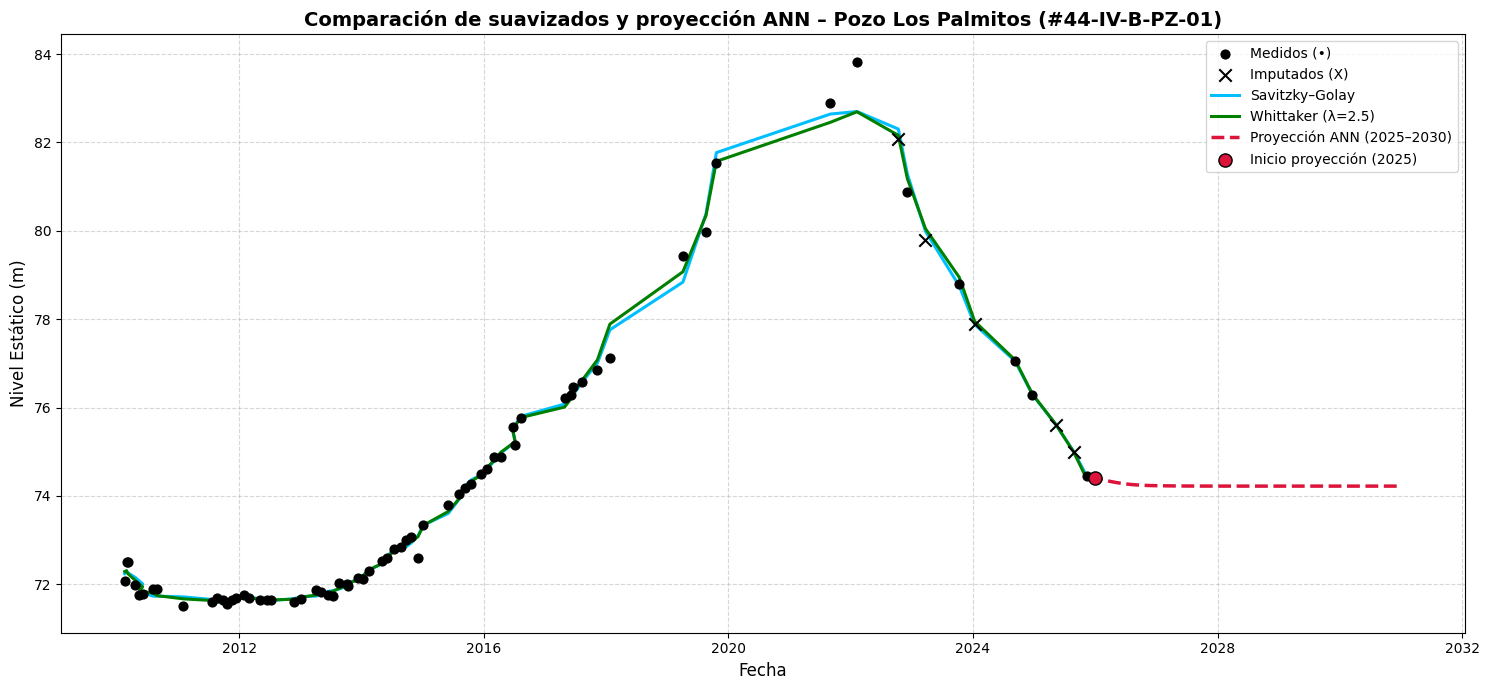


✅ Archivos exportados:
   - comparacion_suavizadores_44_IV_B_PZ_01.csv
   - proyeccion_ann_44_IV_B_PZ_01.csv
   - proyeccion_ann_continua_44_IV_B_PZ_01.csv


In [ ]:
# ======================================================
# Pozo Los Palmitos – #44-IV-B-PZ-01 (Piñal)
# Con proyección ANN continua desde 2025
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------
# 1️⃣ Datos del pozo
# -----------------------------------------------
data = {
    'Fecha': [
        '15/02/2010','26/02/2010','5/03/2010','19/04/2010','2/06/2010','14/05/2010',
        '3/08/2010','27/08/2010','1/02/2011','21/07/2011','22/08/2011','28/09/2011',
        '18/10/2011','17/11/2011','12/12/2011','26/01/2012','28/02/2012','2/05/2012',
        '12/06/2012','8/07/2012','22/11/2012','4/01/2013','4/04/2013','3/05/2013',
        '12/06/2013','16/07/2013','20/08/2013','8/10/2013','9/10/2013','9/12/2013',
        '8/01/2014','13/02/2014','5/05/2014','3/06/2014','10/07/2014','26/08/2014',
        '24/09/2014','24/10/2014','3/12/2014','5/01/2015','2/06/2015','4/08/2015',
        '8/09/2015','15/10/2015','15/12/2015','18/01/2016','29/02/2016','11/04/2016',
        '6/07/2016','20/06/2016','9/08/2016','27/04/2017','2/06/2017','16/06/2017',
        '8/08/2017','9/11/2017','23/01/2018','4/04/2019','20/08/2019','21/10/2019',
        '1/09/2021','7/02/2022','12/10/2022','5/12/2022','23/03/2023','11/10/2023',
        '11/01/2024','9/09/2024','21/12/2024','10/05/2025','25/08/2025','10/11/2025'
    ],
    'Nivel_Estatico_m': [
        72.08,72.5,72.5,71.98,71.78,71.76,71.9,71.9,71.52,71.59,71.7,71.64,71.55,
        71.64,71.7,71.75,71.7,71.65,71.65,71.64,71.6,71.67,71.88,71.82,71.75,71.74,
        72.02,72.01,71.96,72.14,72.12,72.3,72.52,72.6,72.81,72.84,73.01,73.07,72.6,
        73.35,73.79,74.05,74.17,74.28,74.49,74.6,74.87,74.87,75.15,75.56,75.76,
        76.21,76.29,76.47,76.57,76.85,77.11,79.42,79.98,81.53,82.9,83.83,82.0781472,
        80.8869879,79.7940496,78.7935153,77.88,77.0485147,76.2944304,75.6134421,
        75.0015328,74.4549375
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Fechas imputadas
# -----------------------------------------------
fechas_imputadas = [
    '12/10/2022','23/03/2023','11/01/2024','10/05/2025','25/08/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados (Savitzky–Golay y Whittaker λ=2.5)
# ======================================================
window = 9 if len(df) >= 9 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

λ = 2.5
df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=λ)

# ======================================================
# 4️⃣ Comparación de suavizadores
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', f'Whittaker (λ={λ})']).round(4)
print("\n📊 Comparación de suavizadores:\n")
print(tabla)

# ======================================================
# 5️⃣ Preparación de datos para LSTM (2018 en adelante)
# ======================================================
serie = df[['Fecha', 'Whittaker']].set_index('Fecha').resample('M').mean().interpolate()
fecha_corte = pd.Timestamp('2018-01-01')
serie_reciente = serie[serie.index >= fecha_corte].copy()

print(f"\n📈 Entrenamiento desde {fecha_corte.date()} ({len(serie_reciente)} meses)")
print(f"   Tendencia: {serie_reciente.iloc[0].values[0]:.2f} → {serie_reciente.iloc[-1].values[0]:.2f} m")

scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(serie_reciente)

def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
X_train, y_train = X, y

# ======================================================
# 6️⃣ Modelo LSTM y entrenamiento
# ======================================================
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(window,1)),
    LSTM(64, activation='tanh', return_sequences=True),
    LSTM(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=500, batch_size=2, verbose=0)
print("✅ Modelo LSTM entrenado con tendencia reciente")

# ======================================================
# 7️⃣ Proyección ANN hasta 2030 (continua)
# ======================================================
last_date = serie.index[-1]
future_months = (2030 - last_date.year)*12 + (12 - last_date.month)
last_seq = scaled[-window:]
preds = []

for _ in range(future_months):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    last_seq = np.append(last_seq[1:], pred)[-window:]

future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(1),
                             periods=future_months, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

ultimo_valor_historico = serie.iloc[-1].values[0]
ultima_fecha_historica = serie.index[-1]
proyeccion_continua = pd.DataFrame({
    'Fecha': [ultima_fecha_historica] + future_df['Fecha'].tolist(),
    'Nivel': [ultimo_valor_historico] + future_df['Nivel_Predicho'].tolist()
})

# ======================================================
# 8️⃣ Gráfico final
# ======================================================
plt.figure(figsize=(15,7))
plt.scatter(df.loc[~df['Imputado'],'Fecha'], df.loc[~df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=40, label='Medidos (•)', marker='o', zorder=4)
plt.scatter(df.loc[df['Imputado'],'Fecha'], df.loc[df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=80, label='Imputados (X)', marker='x', zorder=4)

plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2.2, label='Savitzky–Golay')
plt.plot(df['Fecha'], df['Whittaker'], color='green', linewidth=2.2, label=f'Whittaker (λ={λ})')

plt.plot(proyeccion_continua['Fecha'], proyeccion_continua['Nivel'],
         color='crimson', linestyle='--', linewidth=2.5, label='Proyección ANN (2025–2030)', zorder=3)
plt.scatter(future_df['Fecha'].iloc[0], future_df['Nivel_Predicho'].iloc[0],
            color='crimson', edgecolors='k', s=90, zorder=5, label='Inicio proyección (2025)')

plt.title('Comparación de suavizados y proyección ANN – Pozo Los Palmitos (#44-IV-B-PZ-01)',
          fontsize=14, weight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Nivel Estático (m)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ======================================================
# 9️⃣ Exportar resultados
# ======================================================
tabla.to_csv('comparacion_suavizadores_44_IV_B_PZ_01.csv')
future_df.to_csv('proyeccion_ann_44_IV_B_PZ_01.csv', index=False)
proyeccion_continua.to_csv('proyeccion_ann_continua_44_IV_B_PZ_01.csv', index=False)

print("\n✅ Archivos exportados:")
print("   - comparacion_suavizadores_44_IV_B_PZ_01.csv")
print("   - proyeccion_ann_44_IV_B_PZ_01.csv")
print("   - proyeccion_ann_continua_44_IV_B_PZ_01.csv")


[texto del vínculo](https://)Pozo Morroa (Bremen) - # 44-IV-C-PZ-01 A


📊 Comparación de suavizadores:

                      RMSE     MAE      R²
Savitzky–Golay      0.2295  0.1823  0.7980
Whittaker (λ=0.25)  0.1400  0.1019  0.9248
✅ Modelo LSTM entrenado desde 2018


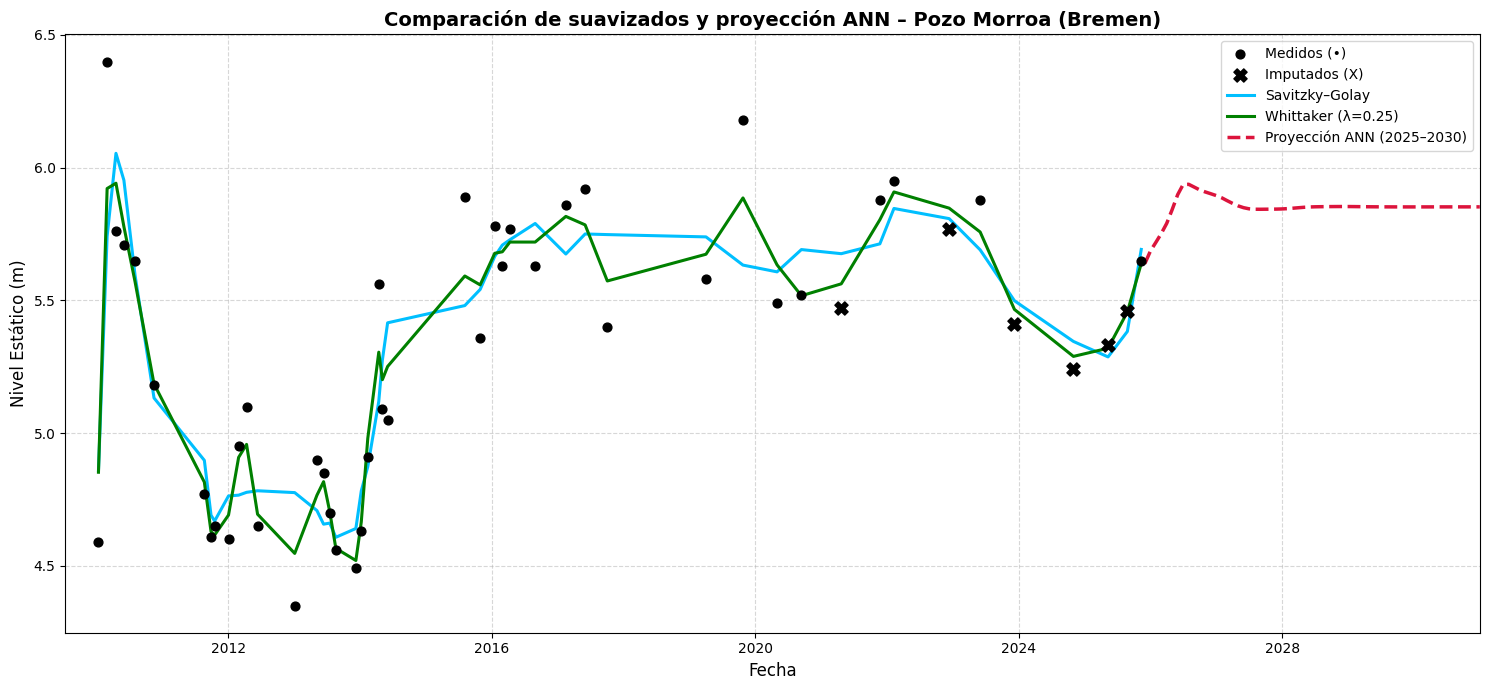


✅ Archivos exportados:
   - comparacion_suavizadores_44_IV_C_PZ_01A.csv
   - proyeccion_ann_44_IV_C_PZ_01A.csv
   - proyeccion_ann_continua_44_IV_C_PZ_01A.csv


In [ ]:
# ======================================================
# Pozo Morroa (Bremen) – #44-IV-C-PZ-01 A
# Suavizado (Savitzky–Golay, Whittaker λ=1.5) y proyección ANN continua 2025–2030
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------
# 1️⃣ Datos del pozo
# -----------------------------------------------
data = {
    'Fecha': [
        '12/1/2010','1/3/2010','19/4/2010','2/6/2010','3/8/2010','16/11/2010',
        '22/8/2011','28/9/2011','18/10/2011','3/1/2012','28/2/2012','12/4/2012',
        '12/6/2012','4/1/2013','7/5/2013','13/6/2013','17/7/2013','20/8/2013',
        '9/12/2013','8/1/2014','13/2/2014','15/4/2014','5/5/2014','3/6/2014',
        '5/8/2015','29/10/2015','18/1/2016','29/2/2016','11/4/2016','29/8/2016',
        '15/2/2017','2/6/2017','3/10/2017','3/4/2019','25/10/2019','1/5/2020',
        '13/9/2020','22/4/2021','22/11/2021','8/2/2022','11/12/2022','1/6/2023',
        '8/12/2023','30/10/2024','10/5/2025','25/8/2025','10/11/2025'
    ],
    'Nivel_Estatico_m': [
        4.59,6.4,5.76,5.71,5.65,5.18,4.77,4.61,4.65,4.6,4.95,5.1,4.65,4.35,4.9,4.85,4.7,4.56,
        4.49,4.63,4.91,5.56,5.09,5.05,5.89,5.36,5.78,5.63,5.77,5.63,5.86,5.92,5.4,5.58,6.18,
        5.49,5.52,5.47,5.88,5.95,5.77,5.88,5.41,5.24,5.33,5.46,5.65
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Fechas imputadas
# -----------------------------------------------
fechas_imputadas = [
    '22/04/2021','11/12/2022','8/12/2023',
    '30/10/2024','10/5/2025','25/8/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados (Savitzky–Golay y Whittaker λ=0.25)
# ======================================================
window = 9 if len(df) >= 9 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=0.25)

# ======================================================
# 4️⃣ Comparación de suavizadores
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', 'Whittaker (λ=0.25)']).round(4)
print("\n📊 Comparación de suavizadores:\n")
print(tabla)

# ======================================================
# 5️⃣ Preparación de datos para LSTM (desde 2018)
# ======================================================
serie = df[['Fecha', 'Whittaker']].set_index('Fecha').resample('M').mean().interpolate()
serie_reciente = serie[serie.index >= pd.Timestamp('2018-01-01')]

scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(serie_reciente)

def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
X_train, y_train = X, y  # usar toda la serie para entrenar

# ======================================================
# 6️⃣ Modelo LSTM y proyección ANN
# ======================================================
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(window,1)),
    LSTM(64, activation='tanh', return_sequences=True),
    LSTM(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=600, batch_size=2, verbose=0)
print("✅ Modelo LSTM entrenado desde 2018")

# Proyección hasta 2030
last_date = serie.index[-1]
future_months = (2030 - last_date.year)*12 + (12 - last_date.month)
last_seq = scaled[-window:]
preds = []

for i in range(future_months):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    last_seq = np.append(last_seq[1:], pred)[-window:]

future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(1),
                             periods=future_months, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

# ======================================================
# 7️⃣ Línea continua (histórico + proyección)
# ======================================================
ultimo_valor_historico = serie.iloc[-1].values[0]
ultima_fecha_historica = serie.index[-1]
proyeccion_continua = pd.DataFrame({
    'Fecha': [ultima_fecha_historica] + future_df['Fecha'].tolist(),
    'Nivel': [ultimo_valor_historico] + future_df['Nivel_Predicho'].tolist()
})

# ======================================================
# 8️⃣ Gráfico final
# ======================================================
plt.figure(figsize=(15,7))
plt.scatter(df.loc[~df['Imputado'],'Fecha'], df.loc[~df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=40, label='Medidos (•)', zorder=4)
plt.scatter(df.loc[df['Imputado'],'Fecha'], df.loc[df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=90, label='Imputados (X)', marker='X', zorder=4)
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2.2, label='Savitzky–Golay')
plt.plot(df['Fecha'], df['Whittaker'], color='green', linewidth=2.2, label='Whittaker (λ=0.25)')
plt.plot(proyeccion_continua['Fecha'], proyeccion_continua['Nivel'],
         color='crimson', linestyle='--', linewidth=2.5, label='Proyección ANN (2025–2030)', zorder=3)
plt.title('Comparación de suavizados y proyección ANN – Pozo Morroa (Bremen)', fontsize=14, weight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Nivel Estático (m)', fontsize=12)
plt.xlim(df['Fecha'].min() - pd.DateOffset(months=6), pd.Timestamp('2031-01-01'))
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ======================================================
# 9️⃣ Exportar resultados
# ======================================================
tabla.to_csv('comparacion_suavizadores_44_IV_C_PZ_01A.csv')
future_df.to_csv('proyeccion_ann_44_IV_C_PZ_01A.csv', index=False)
proyeccion_continua.to_csv('proyeccion_ann_continua_44_IV_C_PZ_01A.csv', index=False)

print("\n✅ Archivos exportados:")
print("   - comparacion_suavizadores_44_IV_C_PZ_01A.csv")
print("   - proyeccion_ann_44_IV_C_PZ_01A.csv")
print("   - proyeccion_ann_continua_44_IV_C_PZ_01A.csv")


Pozo Bremen – #44-IV-C-PZ-01 B


📊 Comparación de suavizadores:

                     RMSE     MAE      R²
Savitzky–Golay     0.3851  0.2547  0.6105
Whittaker (λ=1.5)  0.3228  0.2072  0.7263
✅ Modelo LSTM entrenado desde 2018


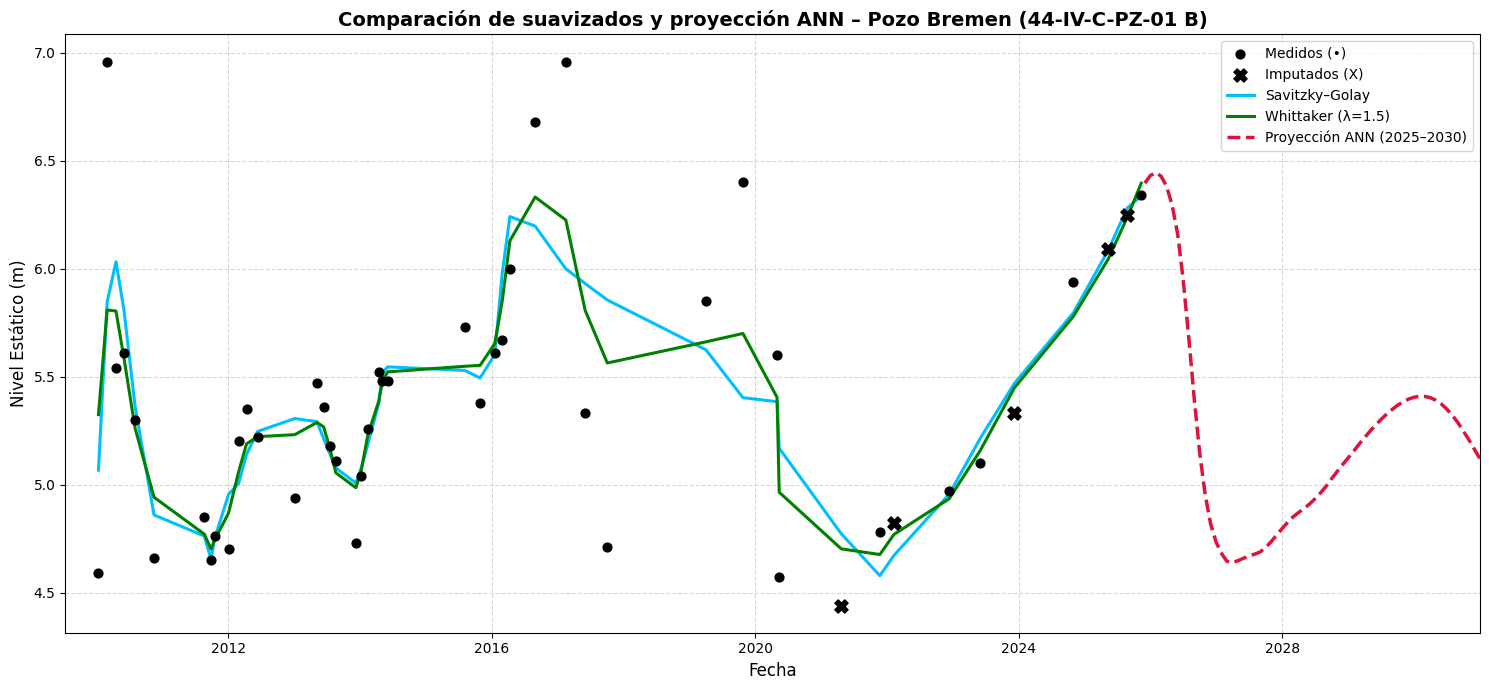


✅ Archivos exportados:
   - comparacion_suavizadores_44_IV_C_PZ_01B.csv
   - proyeccion_ann_44_IV_C_PZ_01B.csv
   - proyeccion_ann_continua_44_IV_C_PZ_01B.csv


In [ ]:
# ======================================================
# Pozo Bremen – #44-IV-C-PZ-01 B
# Suavizado (Savitzky–Golay, Whittaker λ=1.5) + Proyección ANN (2025–2030)
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------
# 1️⃣ Datos del pozo
# -----------------------------------------------
data = {
    'Fecha': [
        '12/1/2010','1/3/2010','19/4/2010','2/6/2010','3/8/2010','16/11/2010',
        '22/8/2011','28/9/2011','18/10/2011','3/1/2012','28/2/2012','12/4/2012',
        '12/6/2012','4/1/2013','7/5/2013','13/6/2013','17/7/2013','20/8/2013',
        '9/12/2013','8/1/2014','13/2/2014','15/4/2014','5/5/2014','3/6/2014',
        '5/8/2015','29/10/2015','18/1/2016','29/2/2016','11/4/2016','29/8/2016',
        '15/2/2017','2/6/2017','3/10/2017','3/4/2019','25/10/2019','1/5/2020',
        '13/5/2020','22/4/2021','22/11/2021','8/2/2022','11/12/2022','1/6/2023',
        '8/12/2023','30/10/2024','10/5/2025','25/8/2025','10/11/2025'
    ],
    'Nivel_Estatico_m': [
        4.59,6.96,5.54,5.61,5.3,4.66,4.85,4.65,4.76,4.7,5.2,5.35,5.22,4.94,5.47,5.36,
        5.18,5.11,4.73,5.04,5.26,5.52,5.48,5.48,5.73,5.38,5.61,5.67,6.00,6.68,6.96,
        5.33,4.71,5.85,6.40,5.60,4.57,4.44,4.78,4.82,4.97,5.10,5.33,5.94,6.09,6.25,6.34
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Fechas imputadas
# -----------------------------------------------
fechas_imputadas = [
    '22/04/2021','8/02/2022','8/12/2023',
    '10/05/2025','25/08/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados (Savitzky–Golay y Whittaker λ=1.5)
# ======================================================
window = 9 if len(df) >= 9 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=1.5)

# ======================================================
# 4️⃣ Comparación de suavizadores
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', 'Whittaker (λ=1.5)']).round(4)
print("\n📊 Comparación de suavizadores:\n")
print(tabla)

# ======================================================
# 5️⃣ Preparación de datos para LSTM (desde 2018)
# ======================================================
serie = df[['Fecha', 'Whittaker']].set_index('Fecha').resample('M').mean().interpolate()
serie_reciente = serie[serie.index >= pd.Timestamp('2018-01-01')]

scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(serie_reciente)

def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
X_train, y_train = X, y  # usar toda la serie para entrenar

# ======================================================
# 6️⃣ Modelo LSTM y proyección ANN
# ======================================================
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(window,1)),
    LSTM(64, activation='tanh', return_sequences=True),
    LSTM(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=600, batch_size=2, verbose=0)
print("✅ Modelo LSTM entrenado desde 2018")

# Proyección hasta 2030
last_date = serie.index[-1]
future_months = (2030 - last_date.year)*12 + (12 - last_date.month)
last_seq = scaled[-window:]
preds = []

for i in range(future_months):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    last_seq = np.append(last_seq[1:], pred)[-window:]

future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(1),
                             periods=future_months, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

# ======================================================
# 7️⃣ Línea continua (histórico + proyección)
# ======================================================
ultimo_valor_historico = serie.iloc[-1].values[0]
ultima_fecha_historica = serie.index[-1]
proyeccion_continua = pd.DataFrame({
    'Fecha': [ultima_fecha_historica] + future_df['Fecha'].tolist(),
    'Nivel': [ultimo_valor_historico] + future_df['Nivel_Predicho'].tolist()
})

# ======================================================
# 8️⃣ Gráfico final
# ======================================================
plt.figure(figsize=(15,7))
plt.scatter(df.loc[~df['Imputado'],'Fecha'], df.loc[~df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=40, label='Medidos (•)', zorder=4)
plt.scatter(df.loc[df['Imputado'],'Fecha'], df.loc[df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=90, label='Imputados (X)', marker='X', zorder=4)
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2.2, label='Savitzky–Golay')
plt.plot(df['Fecha'], df['Whittaker'], color='green', linewidth=2.2, label='Whittaker (λ=1.5)')
plt.plot(proyeccion_continua['Fecha'], proyeccion_continua['Nivel'],
         color='crimson', linestyle='--', linewidth=2.5, label='Proyección ANN (2025–2030)', zorder=3)
plt.title('Comparación de suavizados y proyección ANN – Pozo Bremen (44-IV-C-PZ-01 B)', fontsize=14, weight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Nivel Estático (m)', fontsize=12)
plt.xlim(df['Fecha'].min() - pd.DateOffset(months=6), pd.Timestamp('2031-01-01'))
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ======================================================
# 9️⃣ Exportar resultados
# ======================================================
tabla.to_csv('comparacion_suavizadores_44_IV_C_PZ_01B.csv')
future_df.to_csv('proyeccion_ann_44_IV_C_PZ_01B.csv', index=False)
proyeccion_continua.to_csv('proyeccion_ann_continua_44_IV_C_PZ_01B.csv', index=False)

print("\n✅ Archivos exportados:")
print("   - comparacion_suavizadores_44_IV_C_PZ_01B.csv")
print("   - proyeccion_ann_44_IV_C_PZ_01B.csv")
print("   - proyeccion_ann_continua_44_IV_C_PZ_01B.csv")


 Pozo Las Tinas (Morroa) – #44-IV-C-PZ-02 A

*   Elemento de la lista
*   Elemento de la lista




📊 Comparación de suavizadores:

                     RMSE     MAE      R²
Savitzky–Golay     1.2714  0.6112  0.9045
Whittaker (λ=4.5)  0.9061  0.4205  0.9515
✅ Modelo LSTM entrenado (tendencia reciente)


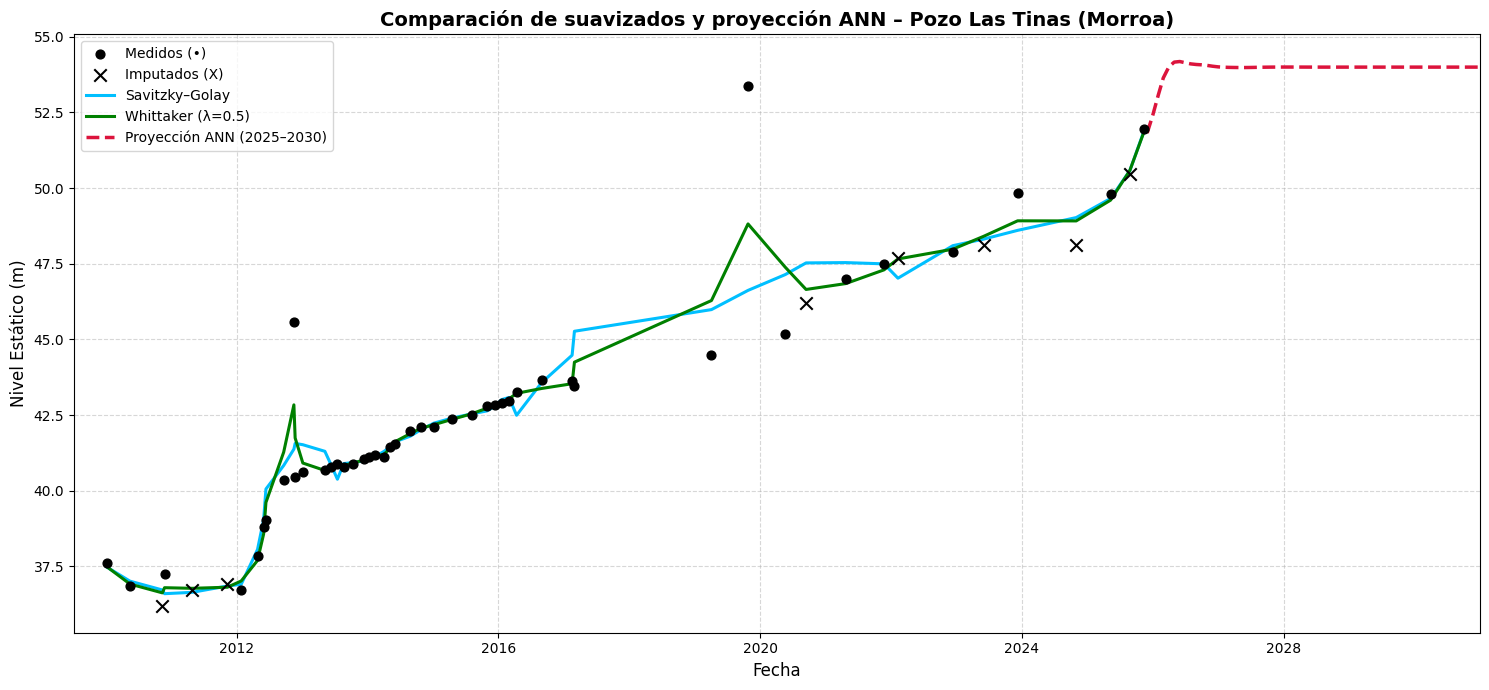


✅ Archivos exportados:
   - comparacion_suavizadores_LasTinas.csv
   - proyeccion_ann_LasTinas_2025_2030.csv
   - proyeccion_continua_LasTinas.csv


In [ ]:
# ======================================================
# Pozo Las Tinas (Morroa) – #44-IV-C-PZ-02 A
# Suavizado (Savitzky–Golay, Whittaker λ=0.5) + ANN 2025–2030
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings("ignore")

# -----------------------------------------------
# 1️⃣ Datos del pozo
# -----------------------------------------------
data = {
    'Fecha': [
        '6/1/2010','15/5/2010','12/11/2010','24/11/2010','27/4/2011','10/11/2011',
        '26/1/2012','26/4/2012','30/5/2012','12/6/2012','19/9/2012','15/11/2012',
        '22/11/2012','4/1/2013','7/5/2013','11/6/2013','16/7/2013','20/8/2013',
        '9/10/2013','9/12/2013','8/1/2014','13/2/2014','2/4/2014','5/5/2014',
        '3/6/2014','26/8/2014','24/10/2014','5/1/2015','15/4/2015','4/8/2015',
        '29/10/2015','15/12/2015','18/1/2016','29/2/2016','11/4/2016','29/8/2016',
        '15/2/2017','28/2/2017','4/4/2019','25/10/2019','20/5/2020','13/9/2020',
        '22/4/2021','22/11/2021','8/2/2022','11/12/2022','1/6/2023','8/12/2023',
        '30/10/2024','10/5/2025','25/8/2025','10/11/2025'
    ],
    'Nivel_Estatico_m': [
        37.63,36.87,36.21,37.25,36.71,36.91,36.73,37.83,38.8,39.04,40.35,45.58,
        40.44,40.61,40.7,40.78,40.89,40.78,40.9,41.04,41.1,41.19,41.1,41.44,
        41.56,41.96,42.11,42.1,42.37,42.51,42.79,42.845,42.9,42.98,43.27,43.65,
        43.64,43.45,44.47,53.37,45.17,46.2,47.0,47.5,47.7,47.9,48.11,49.82,
        48.11,49.79,50.45,51.95
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Clasificar datos imputados
# -----------------------------------------------
fechas_imputadas = [
    '12/11/2010','27/04/2011','10/11/2011','13/09/2020',
    '08/02/2022','01/06/2023','30/10/2024','25/08/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados: Savitzky–Golay y Whittaker (λ = 0.5)
# ======================================================
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=0.5)

# ======================================================
# 4️⃣ Comparación de suavizadores
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', 'Whittaker (λ=4.5)']).round(4)
print("\n📊 Comparación de suavizadores:\n")
print(tabla)

# ======================================================
# 5️⃣ Preparación de datos para LSTM
# ======================================================
serie = df[['Fecha', 'Whittaker']].set_index('Fecha').resample('M').mean().interpolate()

fecha_corte = pd.Timestamp('2018-01-01')
serie_reciente = serie[serie.index >= fecha_corte].copy()

scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(serie_reciente)

def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
X_train, y_train = X, y

# ======================================================
# 6️⃣ Modelo LSTM
# ======================================================
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(window,1)),
    LSTM(64, activation='tanh', return_sequences=True),
    LSTM(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=600, batch_size=2, verbose=0)
print("✅ Modelo LSTM entrenado (tendencia reciente)")

# ======================================================
# 7️⃣ Proyección ANN hasta 2030
# ======================================================
last_date = serie.index[-1]
future_months = (2030 - last_date.year)*12 + (12 - last_date.month)

last_seq = scaled[-window:]
preds = []
for _ in range(future_months):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    last_seq = np.append(last_seq[1:], pred)[-window:]

future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(1),
                             periods=future_months, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

# Crear serie continua (histórico + proyección)
ultimo_valor_historico = serie.iloc[-1].values[0]
ultima_fecha_historica = serie.index[-1]
proyeccion_continua = pd.DataFrame({
    'Fecha': [ultima_fecha_historica] + future_df['Fecha'].tolist(),
    'Nivel': [ultimo_valor_historico] + future_df['Nivel_Predicho'].tolist()
})

# ======================================================
# 8️⃣ Gráfico final
# ======================================================
plt.figure(figsize=(15,7))

# Puntos medidos (•)
plt.scatter(df.loc[~df['Imputado'],'Fecha'], df.loc[~df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=40, label='Medidos (•)', marker='o', zorder=4)

# Puntos imputados (X)
plt.scatter(df.loc[df['Imputado'],'Fecha'], df.loc[df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=80, label='Imputados (X)', marker='x', zorder=4)

# Suavizados
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2.2, label='Savitzky–Golay')
plt.plot(df['Fecha'], df['Whittaker'], color='green', linewidth=2.2, label='Whittaker (λ=0.5)')

# Proyección ANN continua
plt.plot(proyeccion_continua['Fecha'], proyeccion_continua['Nivel'],
         color='crimson', linestyle='--', linewidth=2.5, label='Proyección ANN (2025–2030)')

# Formato
plt.title('Comparación de suavizados y proyección ANN – Pozo Las Tinas (Morroa)',
          fontsize=14, weight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Nivel Estático (m)', fontsize=12)
plt.xlim(df['Fecha'].min() - pd.DateOffset(months=6), pd.Timestamp('2031-01-01'))
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ======================================================
# 9️⃣ Exportar resultados
# ======================================================
tabla.to_csv('comparacion_suavizadores_LasTinas.csv')
future_df.to_csv('proyeccion_ann_LasTinas_2025_2030.csv', index=False)
proyeccion_continua.to_csv('proyeccion_continua_LasTinas.csv', index=False)

print("\n✅ Archivos exportados:")
print("   - comparacion_suavizadores_LasTinas.csv")
print("   - proyeccion_ann_LasTinas_2025_2030.csv")
print("   - proyeccion_continua_LasTinas.csv")


Las Tinas (Morroa) - # 44-IV-C-PZ-02 B


📊 Comparación de suavizadores:

                     RMSE     MAE      R²
Savitzky–Golay     0.1491  0.1111  0.8592
Whittaker (λ=4.5)  0.1373  0.1057  0.8805
✅ Modelo LSTM entrenado (tendencia reciente)


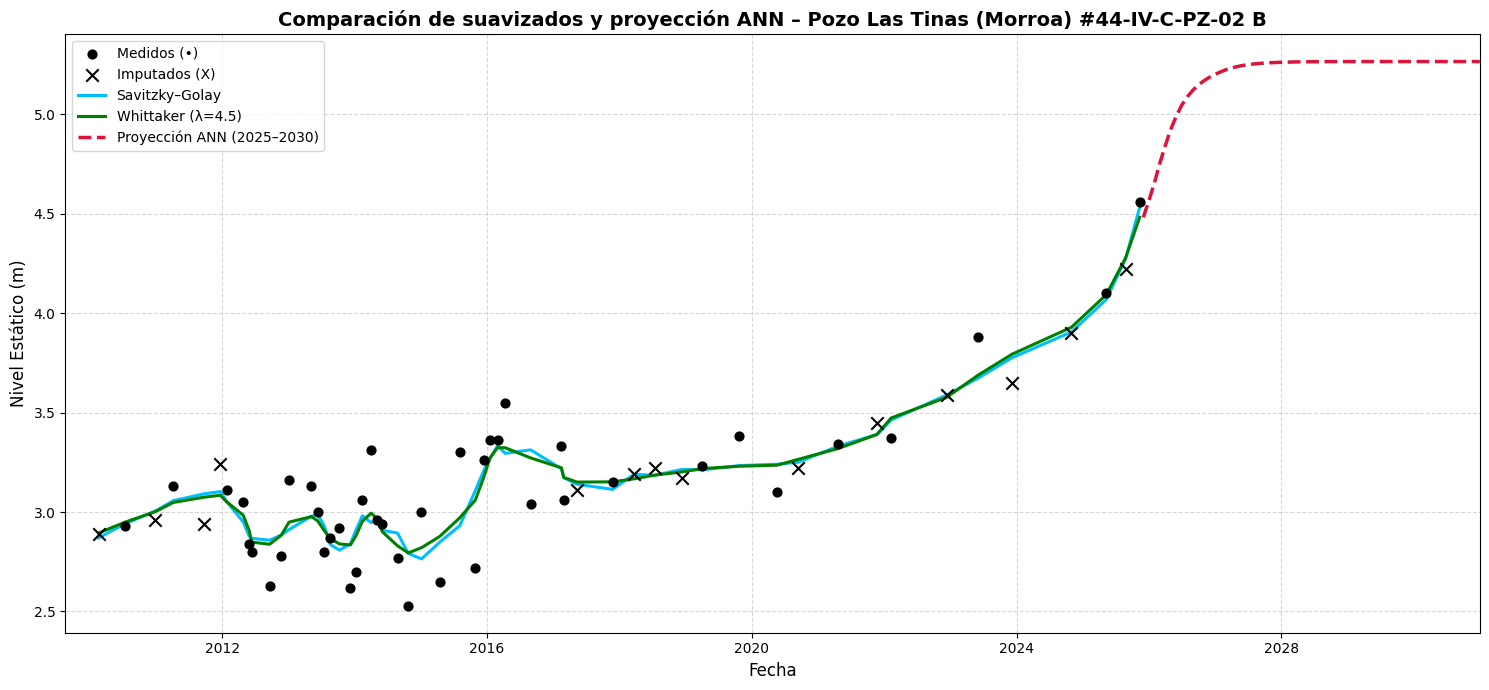


✅ Archivos exportados:
   - comparacion_suavizadores_LasTinas_B.csv
   - proyeccion_ann_LasTinas_B_2025_2030.csv
   - proyeccion_continua_LasTinas_B.csv


In [ ]:
# ======================================================
# Pozo Las Tinas (Morroa) – #44-IV-C-PZ-02 B
# Suavizado (Savitzky–Golay, Whittaker λ=4.5) + ANN 2025–2030
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings("ignore")

# -----------------------------------------------
# 1️⃣ Datos del pozo
# -----------------------------------------------
data = {
    'Fecha': [
        '18/2/2010','13/7/2010','28/12/2010','7/4/2011','24/9/2011','22/12/2011',
        '26/1/2012','26/4/2012','30/5/2012','12/6/2012','19/9/2012','22/11/2012',
        '4/1/2013','7/5/2013','11/6/2013','16/7/2013','20/8/2013','9/10/2013',
        '9/12/2013','8/1/2014','13/2/2014','2/4/2014','5/5/2014','3/6/2014',
        '26/8/2014','24/10/2014','5/1/2015','15/4/2015','4/8/2015','29/10/2015',
        '15/12/2015','18/1/2016','29/2/2016','11/4/2016','29/8/2016','15/2/2017',
        '28/2/2017','12/5/2017','25/11/2017','22/3/2018','14/7/2018','11/12/2018',
        '4/4/2019','25/10/2019','20/5/2020','13/9/2020','22/4/2021','22/11/2021',
        '8/2/2022','11/12/2022','1/6/2023','8/12/2023','30/10/2024','10/5/2025',
        '25/8/2025','10/11/2025'
    ],
    'Nivel_Estatico_m': [
        2.89,2.93,2.96,3.13,2.94,3.24,3.11,3.05,2.84,2.8,2.63,2.78,
        3.16,3.13,3.0,2.8,2.87,2.92,2.62,2.7,3.06,3.31,2.96,2.94,
        2.77,2.53,3.0,2.65,3.3,2.72,3.26,3.36,3.36,3.55,3.04,3.33,
        3.06,3.11,3.15,3.19,3.22,3.17,3.23,3.38,3.1,3.22,3.34,3.45,
        3.37,3.59,3.88,3.65,3.9,4.1,4.22,4.56
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Fechas imputadas
# -----------------------------------------------
fechas_imputadas = [
    '18/02/2010','28/12/2010','24/09/2011','22/12/2011','12/05/2017','22/03/2018',
    '14/07/2018','11/12/2018','13/09/2020','22/11/2021','11/12/2022','08/12/2023',
    '30/10/2024','25/08/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados (Savitzky–Golay y Whittaker λ=4.5)
# ======================================================
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=4.5)

# ======================================================
# 4️⃣ Comparación de suavizadores
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', 'Whittaker (λ=4.5)']).round(4)
print("\n📊 Comparación de suavizadores:\n")
print(tabla)

# ======================================================
# 5️⃣ Preparación de datos para LSTM
# ======================================================
serie = df[['Fecha', 'Whittaker']].set_index('Fecha').resample('M').mean().interpolate()

# Filtrar desde 2018 para capturar la tendencia más reciente
fecha_corte = pd.Timestamp('2018-01-01')
serie_reciente = serie[serie.index >= fecha_corte].copy()

scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(serie_reciente)

def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
X_train, y_train = X, y

# ======================================================
# 6️⃣ Modelo LSTM
# ======================================================
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(window,1)),
    LSTM(64, activation='tanh', return_sequences=True),
    LSTM(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=600, batch_size=2, verbose=0)
print("✅ Modelo LSTM entrenado (tendencia reciente)")

# ======================================================
# 7️⃣ Proyección ANN hasta 2030
# ======================================================
last_date = serie.index[-1]
future_months = (2030 - last_date.year)*12 + (12 - last_date.month)

last_seq = scaled[-window:]
preds = []
for _ in range(future_months):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    last_seq = np.append(last_seq[1:], pred)[-window:]

future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(1),
                             periods=future_months, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

ultimo_valor_historico = serie.iloc[-1].values[0]
ultima_fecha_historica = serie.index[-1]
proyeccion_continua = pd.DataFrame({
    'Fecha': [ultima_fecha_historica] + future_df['Fecha'].tolist(),
    'Nivel': [ultimo_valor_historico] + future_df['Nivel_Predicho'].tolist()
})

# ======================================================
# 8️⃣ Gráfico final
# ======================================================
plt.figure(figsize=(15,7))

# Puntos medidos (•)
plt.scatter(df.loc[~df['Imputado'],'Fecha'], df.loc[~df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=40, label='Medidos (•)', marker='o', zorder=4)

# Puntos imputados (X)
plt.scatter(df.loc[df['Imputado'],'Fecha'], df.loc[df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=80, label='Imputados (X)', marker='x', zorder=4)

# Suavizados
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2.2, label='Savitzky–Golay')
plt.plot(df['Fecha'], df['Whittaker'], color='green', linewidth=2.2, label='Whittaker (λ=4.5)')

# Proyección ANN continua
plt.plot(proyeccion_continua['Fecha'], proyeccion_continua['Nivel'],
         color='crimson', linestyle='--', linewidth=2.5, label='Proyección ANN (2025–2030)')

plt.title('Comparación de suavizados y proyección ANN – Pozo Las Tinas (Morroa) #44-IV-C-PZ-02 B',
          fontsize=14, weight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Nivel Estático (m)', fontsize=12)
plt.xlim(df['Fecha'].min() - pd.DateOffset(months=6), pd.Timestamp('2031-01-01'))
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ======================================================
# 9️⃣ Exportar resultados
# ======================================================
tabla.to_csv('comparacion_suavizadores_LasTinas_B.csv')
future_df.to_csv('proyeccion_ann_LasTinas_B_2025_2030.csv', index=False)
proyeccion_continua.to_csv('proyeccion_continua_LasTinas_B.csv', index=False)

print("\n✅ Archivos exportados:")
print("   - comparacion_suavizadores_LasTinas_B.csv")
print("   - proyeccion_ann_LasTinas_B_2025_2030.csv")
print("   - proyeccion_continua_LasTinas_B.csv")


Arroyo salida a Betulia (Corozal) - # 44-IV-D-PZ-01 A


📊 Comparación de suavizadores:

                     RMSE     MAE      R²
Savitzky–Golay     0.3161  0.2153  0.9956
Whittaker (λ=3.0)  0.2737  0.1816  0.9967
✅ Modelo LSTM entrenado (tendencia reciente)


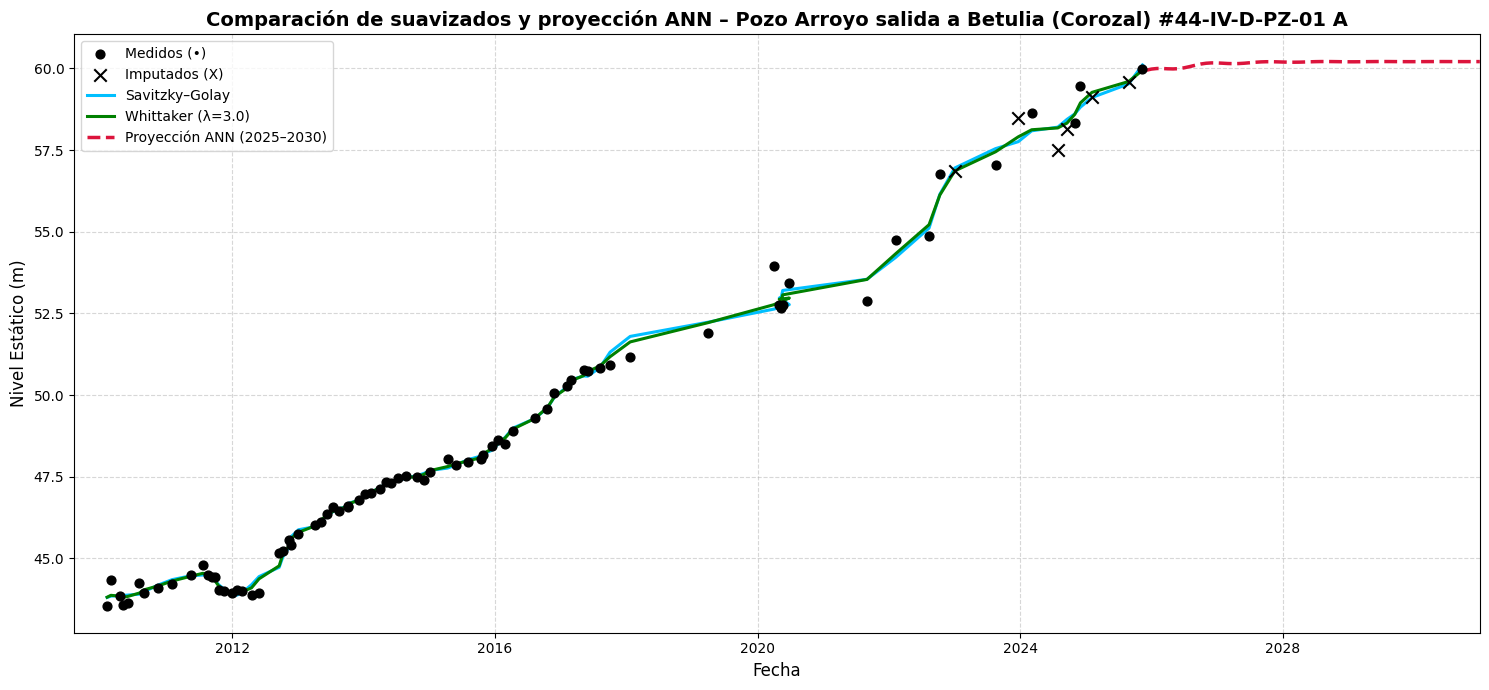


✅ Archivos exportados:
   - comparacion_suavizadores_44_IV_D_PZ_01A.csv
   - proyeccion_ann_44_IV_D_PZ_01A_2025_2030.csv
   - proyeccion_continua_44_IV_D_PZ_01A.csv


In [ ]:
# ======================================================
# Pozo Arroyo salida a Betulia (Corozal) – #44-IV-D-PZ-01 A
# Suavizado (Savitzky–Golay, Whittaker λ=3.0) + ANN 2025–2030
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings("ignore")

# -----------------------------------------------
# 1️⃣ Datos del pozo
# -----------------------------------------------
data = {
    'Fecha': [
        '5/2/2010','26/2/2010','19/4/2010','7/5/2010','2/6/2010','3/8/2010',
        '27/8/2010','16/11/2010','1/2/2011','16/5/2011','21/7/2011','22/8/2011',
        '14/9/2011','28/9/2011','18/10/2011','17/11/2011','3/1/2012','26/1/2012',
        '24/2/2012','18/4/2012','30/5/2012','19/9/2012','9/10/2012','15/11/2012',
        '22/11/2012','4/1/2013','4/4/2013','7/5/2013','12/6/2013','16/7/2013',
        '20/8/2013','8/10/2013','9/10/2013','9/12/2013','8/1/2014','13/2/2014',
        '2/4/2014','5/5/2014','3/6/2014','10/7/2014','26/8/2014','24/10/2014',
        '3/12/2014','5/1/2015','13/4/2015','2/6/2015','4/8/2015','15/10/2015',
        '29/10/2015','15/12/2015','18/1/2016','29/2/2016','11/4/2016','9/8/2016',
        '20/10/2016','28/11/2016','8/2/2017','28/2/2017','10/5/2017','1/6/2017',
        '8/8/2017','3/10/2017','23/1/2018','3/4/2019','31/3/2020','26/6/2020',
        '1/5/2020','13/5/2020','20/5/2020','1/9/2021','8/2/2022','12/8/2022',
        '11/10/2022','2/1/2023','17/8/2023','21/12/2023','5/3/2024','28/7/2024',
        '17/9/2024','30/10/2024','1/12/2024','3/2/2025','26/8/2025','11/11/2025'
    ],
    'Nivel_Estatico_m': [
        43.56,44.35,43.86,43.57,43.63,44.25,43.93,44.1,44.21,44.49,44.79,44.49,
        44.43,44.44,44.05,43.99,43.95,44.05,44.0,43.88,43.95,45.18,45.24,45.58,
        45.41,45.76,46.02,46.12,46.37,46.57,46.46,46.6,46.57,46.775,46.98,47.0,
        47.14,47.34,47.32,47.47,47.52,47.49,47.39,47.66,48.05,47.86,47.96,48.05,
        48.18,48.43,48.63,48.49,48.89,49.31,49.58,50.07,50.28,50.45,50.78,50.73,
        50.82,50.92,51.17,51.89,53.95,53.42,52.75,52.68,52.75,52.87,54.75,54.87,
        56.76,56.87,57.05,58.47,58.65,57.50,58.15,58.32,59.45,59.12,59.58,59.97
    ]
}
df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Fechas imputadas
# -----------------------------------------------
fechas_imputadas = [
    '2/01/2023','21/12/2023','28/07/2024','17/09/2024','3/02/2025','26/08/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados (Savitzky–Golay y Whittaker λ=3.0)
# ======================================================
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=3.0)

# ======================================================
# 4️⃣ Comparación de suavizadores
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', 'Whittaker (λ=3.0)']).round(4)
print("\n📊 Comparación de suavizadores:\n")
print(tabla)

# ======================================================
# 5️⃣ Preparación de datos para LSTM
# ======================================================
serie = df[['Fecha', 'Whittaker']].set_index('Fecha').resample('M').mean().interpolate()
fecha_corte = pd.Timestamp('2018-01-01')
serie_reciente = serie[serie.index >= fecha_corte].copy()

scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(serie_reciente)

def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
X_train, y_train = X, y

# ======================================================
# 6️⃣ Modelo LSTM
# ======================================================
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(window,1)),
    LSTM(64, activation='tanh', return_sequences=True),
    LSTM(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=600, batch_size=2, verbose=0)
print("✅ Modelo LSTM entrenado (tendencia reciente)")

# ======================================================
# 7️⃣ Proyección ANN hasta 2030
# ======================================================
last_date = serie.index[-1]
future_months = (2030 - last_date.year)*12 + (12 - last_date.month)

last_seq = scaled[-window:]
preds = []
for _ in range(future_months):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    last_seq = np.append(last_seq[1:], pred)[-window:]

future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(1),
                             periods=future_months, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

ultimo_valor_historico = serie.iloc[-1].values[0]
ultima_fecha_historica = serie.index[-1]
proyeccion_continua = pd.DataFrame({
    'Fecha': [ultima_fecha_historica] + future_df['Fecha'].tolist(),
    'Nivel': [ultimo_valor_historico] + future_df['Nivel_Predicho'].tolist()
})

# ======================================================
# 8️⃣ Gráfico final
# ======================================================
plt.figure(figsize=(15,7))
plt.scatter(df.loc[~df['Imputado'],'Fecha'], df.loc[~df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=40, label='Medidos (•)', marker='o', zorder=4)
plt.scatter(df.loc[df['Imputado'],'Fecha'], df.loc[df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=80, label='Imputados (X)', marker='x', zorder=4)

plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2.2, label='Savitzky–Golay')
plt.plot(df['Fecha'], df['Whittaker'], color='green', linewidth=2.2, label='Whittaker (λ=3.0)')
plt.plot(proyeccion_continua['Fecha'], proyeccion_continua['Nivel'],
         color='crimson', linestyle='--', linewidth=2.5, label='Proyección ANN (2025–2030)')

plt.title('Comparación de suavizados y proyección ANN – Pozo Arroyo salida a Betulia (Corozal) #44-IV-D-PZ-01 A',
          fontsize=14, weight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Nivel Estático (m)', fontsize=12)
plt.xlim(df['Fecha'].min() - pd.DateOffset(months=6), pd.Timestamp('2031-01-01'))
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ======================================================
# 9️⃣ Exportar resultados
# ======================================================
tabla.to_csv('comparacion_suavizadores_44_IV_D_PZ_01A.csv')
future_df.to_csv('proyeccion_ann_44_IV_D_PZ_01A_2025_2030.csv', index=False)
proyeccion_continua.to_csv('proyeccion_continua_44_IV_D_PZ_01A.csv', index=False)

print("\n✅ Archivos exportados:")
print("   - comparacion_suavizadores_44_IV_D_PZ_01A.csv")
print("   - proyeccion_ann_44_IV_D_PZ_01A_2025_2030.csv")
print("   - proyeccion_continua_44_IV_D_PZ_01A.csv")


\Arroyo salida a Betulia (Corozal) - # 44-IV-D-PZ-01 B


📊 Comparación de suavizadores:

                     RMSE     MAE      R²
Savitzky–Golay     0.3895  0.2866  0.7239
Whittaker (λ=3.5)  0.3328  0.2366  0.7985
✅ Modelo LSTM entrenado (tendencia reciente)


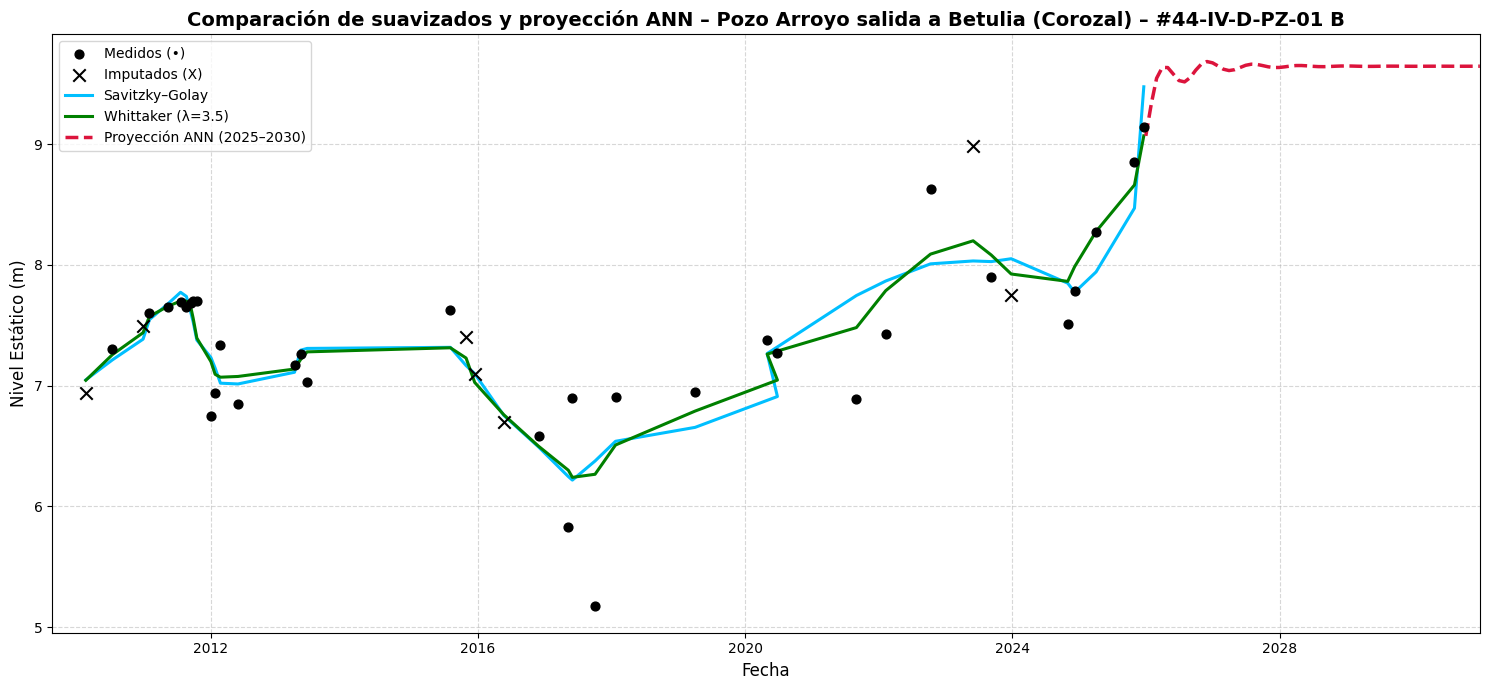


✅ Archivos exportados:
   - comparacion_suavizadores_44_IV_D_PZ_01B.csv
   - proyeccion_ann_44_IV_D_PZ_01B_2025_2030.csv
   - proyeccion_continua_44_IV_D_PZ_01B.csv


In [ ]:
# ======================================================
# Pozo Arroyo salida a Betulia (Corozal) – #44-IV-D-PZ-01 B
# Suavizado (Savitzky–Golay, Whittaker λ=3.5) + ANN (2025–2030)
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings("ignore")

# -----------------------------------------------
# 1️⃣ Datos del pozo
# -----------------------------------------------
data = {
    'Fecha': [
        '18/2/2010','13/7/2010','28/12/2010','1/2/2011','16/5/2011','21/7/2011',
        '22/8/2011','14/9/2011','28/9/2011','18/10/2011','3/1/2012','26/1/2012',
        '24/2/2012','30/5/2012','4/4/2013','7/5/2013','12/6/2013','4/8/2015',
        '29/10/2015','15/12/2015','22/5/2016','28/11/2016','10/5/2017','1/6/2017',
        '3/10/2017','23/1/2018','3/4/2019','26/6/2020','1/5/2020','1/9/2021',
        '8/2/2022','11/10/2022','1/6/2023','8/9/2023','26/12/2023','30/10/2024',
        '7/12/2024','3/4/2025','30/10/2025','20/12/2025'
    ],
    'Nivel_Estatico_m': [
        6.94,7.30,7.49,7.60,7.65,7.69,7.65,7.68,7.70,7.70,6.75,6.94,7.34,6.85,
        7.17,7.26,7.03,7.63,7.40,7.10,6.70,6.58,5.83,6.90,5.18,6.91,6.95,7.27,
        7.38,6.89,7.43,8.63,8.98,7.90,7.75,7.51,7.78,8.27,8.85,9.14
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Fechas imputadas
# -----------------------------------------------
fechas_imputadas = [
    '18/2/2010','28/12/2010','29/10/2015','15/12/2015','22/5/2016',
    '1/6/2023','26/12/2023'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados (Savitzky–Golay y Whittaker λ=2.0)
# ======================================================
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=3.5)

# ======================================================
# 4️⃣ Comparación de suavizadores
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', 'Whittaker (λ=3.5)']).round(4)
print("\n📊 Comparación de suavizadores:\n")
print(tabla)

# ======================================================
# 5️⃣ Preparación de datos para LSTM (desde 2018)
# ======================================================
serie = df[['Fecha','Whittaker']].set_index('Fecha').resample('M').mean().interpolate()
fecha_corte = pd.Timestamp('2018-01-01')
serie_reciente = serie[serie.index >= fecha_corte].copy()

scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(serie_reciente)

def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
X_train, y_train = X, y

# ======================================================
# 6️⃣ Modelo LSTM
# ======================================================
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(window,1)),
    LSTM(64, activation='tanh', return_sequences=True),
    LSTM(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=600, batch_size=2, verbose=0)
print("✅ Modelo LSTM entrenado (tendencia reciente)")

# ======================================================
# 7️⃣ Proyección ANN hasta 2030
# ======================================================
last_date = serie.index[-1]
future_months = (2030 - last_date.year)*12 + (12 - last_date.month)

last_seq = scaled[-window:]
preds = []
for _ in range(future_months):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    last_seq = np.append(last_seq[1:], pred)[-window:]

future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(1),
                             periods=future_months, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

# Concatenar serie histórica + proyección
ultimo_valor_historico = serie.iloc[-1].values[0]
ultima_fecha_historica = serie.index[-1]
proyeccion_continua = pd.DataFrame({
    'Fecha': [ultima_fecha_historica] + future_df['Fecha'].tolist(),
    'Nivel': [ultimo_valor_historico] + future_df['Nivel_Predicho'].tolist()
})

# ======================================================
# 8️⃣ Gráfico final
# ======================================================
plt.figure(figsize=(15,7))
plt.scatter(df.loc[~df['Imputado'],'Fecha'], df.loc[~df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=40, label='Medidos (•)', marker='o', zorder=4)
plt.scatter(df.loc[df['Imputado'],'Fecha'], df.loc[df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=80, label='Imputados (X)', marker='x', zorder=4)
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2.2, label='Savitzky–Golay')
plt.plot(df['Fecha'], df['Whittaker'], color='green', linewidth=2.2, label='Whittaker (λ=3.5)')
plt.plot(proyeccion_continua['Fecha'], proyeccion_continua['Nivel'],
         color='crimson', linestyle='--', linewidth=2.5, label='Proyección ANN (2025–2030)')
plt.title('Comparación de suavizados y proyección ANN – Pozo Arroyo salida a Betulia (Corozal) – #44-IV-D-PZ-01 B',
          fontsize=14, weight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Nivel Estático (m)', fontsize=12)
plt.xlim(df['Fecha'].min() - pd.DateOffset(months=6), pd.Timestamp('2031-01-01'))
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ======================================================
# 9️⃣ Exportar resultados
# ======================================================
tabla.to_csv('comparacion_suavizadores_44_IV_D_PZ_01B.csv')
future_df.to_csv('proyeccion_ann_44_IV_D_PZ_01B_2025_2030.csv', index=False)
proyeccion_continua.to_csv('proyeccion_continua_44_IV_D_PZ_01B.csv', index=False)

print("\n✅ Archivos exportados:")
print("   - comparacion_suavizadores_44_IV_D_PZ_01B.csv")
print("   - proyeccion_ann_44_IV_D_PZ_01B_2025_2030.csv")
print("   - proyeccion_continua_44_IV_D_PZ_01B.csv")


Sabanas de cali (El Tesoro) - # 44-IV-D-PZ-02

---




📊 Comparación de suavizadores:

                     RMSE     MAE      R²
Savitzky–Golay     0.3077  0.2086  0.9982
Whittaker (λ=0.5)  0.1968  0.1196  0.9993
✅ Modelo LSTM entrenado (tendencia reciente)


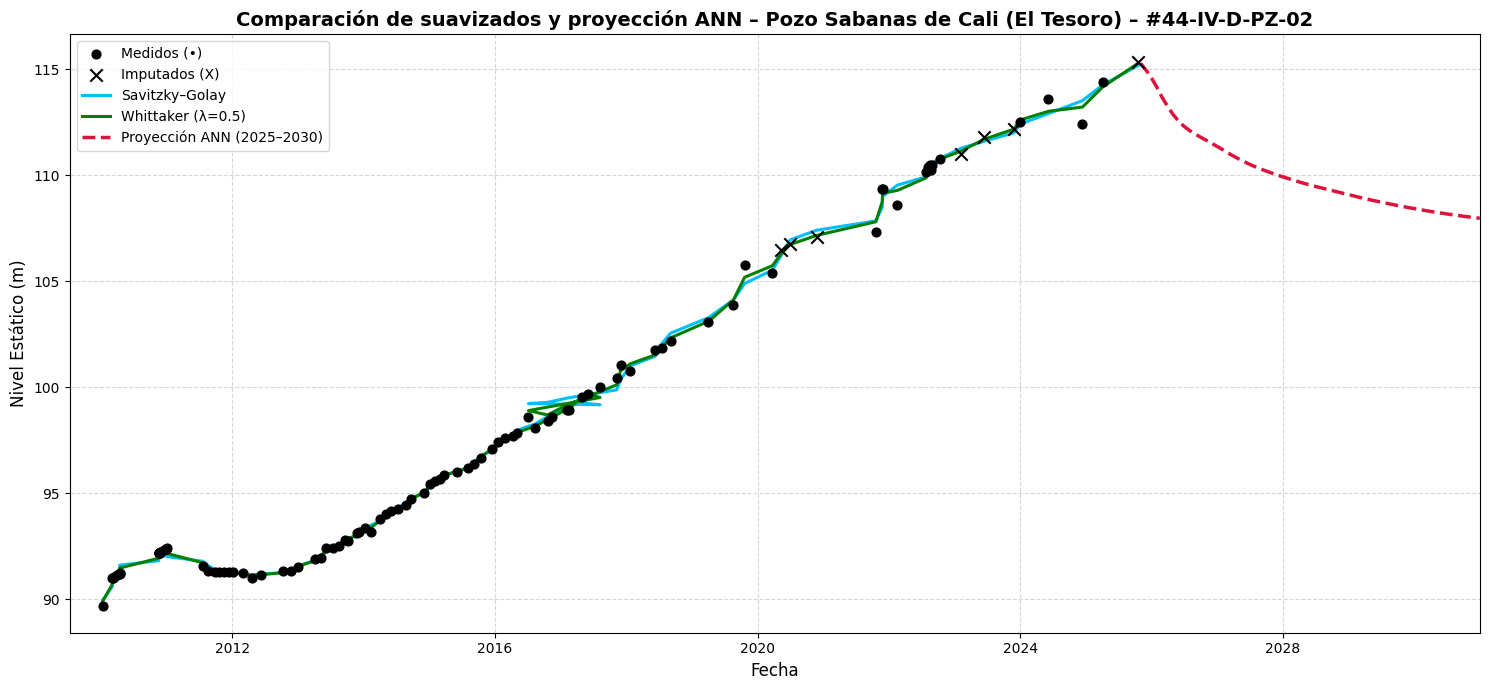


✅ Archivos exportados:
   - comparacion_suavizadores_44_IV_D_PZ_02.csv
   - proyeccion_ann_44_IV_D_PZ_02_2025_2030.csv
   - proyeccion_continua_44_IV_D_PZ_02.csv


In [ ]:
# ======================================================
# Pozo Sabanas de Cali (El Tesoro) – #44-IV-D-PZ-02
# Suavizado (Savitzky–Golay, Whittaker λ=0.5) + ANN (2025–2030)
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings("ignore")

# -----------------------------------------------
# 1️⃣ Datos del pozo
# -----------------------------------------------
data = {
    'Fecha': [
        '12/1/2010','5/3/2010','7/3/2010','8/3/2010','16/3/2010','1/4/2010','10/4/2010','15/4/2010','16/4/2010',
        '19/11/2010','20/11/2010','21/11/2010','22/11/2010','23/11/2010','24/11/2010','25/11/2010','19/12/2010',
        '28/12/2010','29/12/2010','30/12/2010','31/12/2010','1/1/2011','21/7/2011','22/8/2011','28/9/2011',
        '18/10/2011','17/11/2011','12/12/2011','3/1/2012','28/2/2012','18/4/2012','12/6/2012','9/10/2012',
        '22/11/2012','4/1/2013','4/4/2013','7/5/2013','7/6/2013','16/7/2013','20/8/2013','20/9/2013','8/10/2013',
        '26/11/2013','9/12/2013','8/1/2014','13/2/2014','2/4/2014','5/5/2014','3/6/2014','10/7/2014','26/8/2014',
        '24/9/2014','3/12/2014','5/1/2015','31/1/2015','28/2/2015','24/3/2015','2/6/2015','4/8/2015','8/9/2015',
        '15/10/2015','15/12/2015','18/1/2016','29/2/2016','11/4/2016','4/5/2016','9/8/2016','12/11/2016',
        '18/2/2017','27/4/2017','2/6/2017','8/8/2017','6/7/2016','20/10/2016','8/2/2017','9/11/2017','30/11/2017',
        '23/1/2018','12/6/2018','16/7/2018','5/9/2018','3/4/2019','20/8/2019','21/10/2019','24/3/2020','12/5/2020',
        '30/6/2020','25/11/2020','20/10/2021','25/11/2021','26/11/2021','17/2/2022','26/7/2022','5/8/2022',
        '12/8/2022','18/8/2022','24/8/2022','29/8/2022','10/10/2022','7/2/2023','11/6/2023','26/11/2023',
        '1/1/2024','6/6/2024','12/12/2024','4/4/2025','18/10/2025'
    ],
    'Nivel_Estatico_m': [
        89.7,91.01,91.02,91.02,91.06,91.14,91.19,91.22,91.2,92.19,92.2,92.2,92.2,92.2,92.2,92.21,92.33,92.37,
        92.37,92.36,92.39,92.4,91.55,91.34,91.29,91.3,91.3,91.3,91.3,91.25,91,91.15,91.34,91.31,91.52,91.88,
        91.95,92.42,92.41,92.5,92.81,92.76,93.1,93.15,93.35,93.17,93.8,94.03,94.15,94.24,94.42,94.73,95.01,
        95.42,95.58,95.68,95.86,96,96.2,96.39,96.68,97.1,97.4,97.6,97.71,97.82,98.1,98.6,98.93,99.56,99.69,
        99.99,98.61,98.43,98.93,100.45,101.03,100.79,101.74,101.85,102.19,103.08,103.9,105.76,105.38,106.46,
        106.77,107.11,107.32,109.36,109.36,108.6,110.17,110.41,110.33,110.49,110.23,110.5,110.78,111.03,111.79,
        112.2,112.5,113.6,112.44,114.39,115.37
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Fechas imputadas
# -----------------------------------------------
fechas_imputadas = [
    '12/5/2020','30/6/2020','25/11/2020','7/2/2023','11/6/2023','26/11/2023','18/10/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados (Savitzky–Golay y Whittaker λ=0.5)
# ======================================================
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=0.5)

# ======================================================
# 4️⃣ Comparación de suavizadores
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', 'Whittaker (λ=0.5)']).round(4)
print("\n📊 Comparación de suavizadores:\n")
print(tabla)

# ======================================================
# 5️⃣ Preparación de datos para LSTM (desde 2018)
# ======================================================
serie = df[['Fecha','Whittaker']].set_index('Fecha').resample('M').mean().interpolate()
fecha_corte = pd.Timestamp('2018-01-01')
serie_reciente = serie[serie.index >= fecha_corte].copy()

scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(serie_reciente)

def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
X_train, y_train = X, y

# ======================================================
# 6️⃣ Modelo LSTM
# ======================================================
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(window,1)),
    LSTM(64, activation='tanh', return_sequences=True),
    LSTM(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=600, batch_size=2, verbose=0)
print("✅ Modelo LSTM entrenado (tendencia reciente)")

# ======================================================
# 7️⃣ Proyección ANN hasta 2030
# ======================================================
last_date = serie.index[-1]
future_months = (2030 - last_date.year)*12 + (12 - last_date.month)
last_seq = scaled[-window:]
preds = []
for _ in range(future_months):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    last_seq = np.append(last_seq[1:], pred)[-window:]

future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(1),
                             periods=future_months, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

ultimo_valor_historico = serie.iloc[-1].values[0]
ultima_fecha_historica = serie.index[-1]
proyeccion_continua = pd.DataFrame({
    'Fecha': [ultima_fecha_historica] + future_df['Fecha'].tolist(),
    'Nivel': [ultimo_valor_historico] + future_df['Nivel_Predicho'].tolist()
})

# ======================================================
# 8️⃣ Gráfico final
# ======================================================
plt.figure(figsize=(15,7))
plt.scatter(df.loc[~df['Imputado'],'Fecha'], df.loc[~df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=40, label='Medidos (•)', marker='o', zorder=4)
plt.scatter(df.loc[df['Imputado'],'Fecha'], df.loc[df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=80, label='Imputados (X)', marker='x', zorder=4)
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2.2, label='Savitzky–Golay')
plt.plot(df['Fecha'], df['Whittaker'], color='green', linewidth=2.2, label='Whittaker (λ=0.5)')
plt.plot(proyeccion_continua['Fecha'], proyeccion_continua['Nivel'],
         color='crimson', linestyle='--', linewidth=2.5, label='Proyección ANN (2025–2030)')
plt.title('Comparación de suavizados y proyección ANN – Pozo Sabanas de Cali (El Tesoro) – #44-IV-D-PZ-02',
          fontsize=14, weight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Nivel Estático (m)', fontsize=12)
plt.xlim(df['Fecha'].min() - pd.DateOffset(months=6), pd.Timestamp('2031-01-01'))
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ======================================================
# 9️⃣ Exportar resultados
# ======================================================
tabla.to_csv('comparacion_suavizadores_44_IV_D_PZ_02.csv')
future_df.to_csv('proyeccion_ann_44_IV_D_PZ_02_2025_2030.csv', index=False)
proyeccion_continua.to_csv('proyeccion_continua_44_IV_D_PZ_02.csv', index=False)

print("\n✅ Archivos exportados:")
print("   - comparacion_suavizadores_44_IV_D_PZ_02.csv")
print("   - proyeccion_ann_44_IV_D_PZ_02_2025_2030.csv")
print("   - proyeccion_continua_44_IV_D_PZ_02.csv")


Finca el tesoro - # 44-IV-D-PZ-04


📊 Comparación de suavizadores:

                      RMSE     MAE      R²
Savitzky–Golay      0.6476  0.3549  0.9592
Whittaker (λ=0.85)  0.4259  0.2337  0.9823
✅ Modelo LSTM entrenado (tendencia reciente)


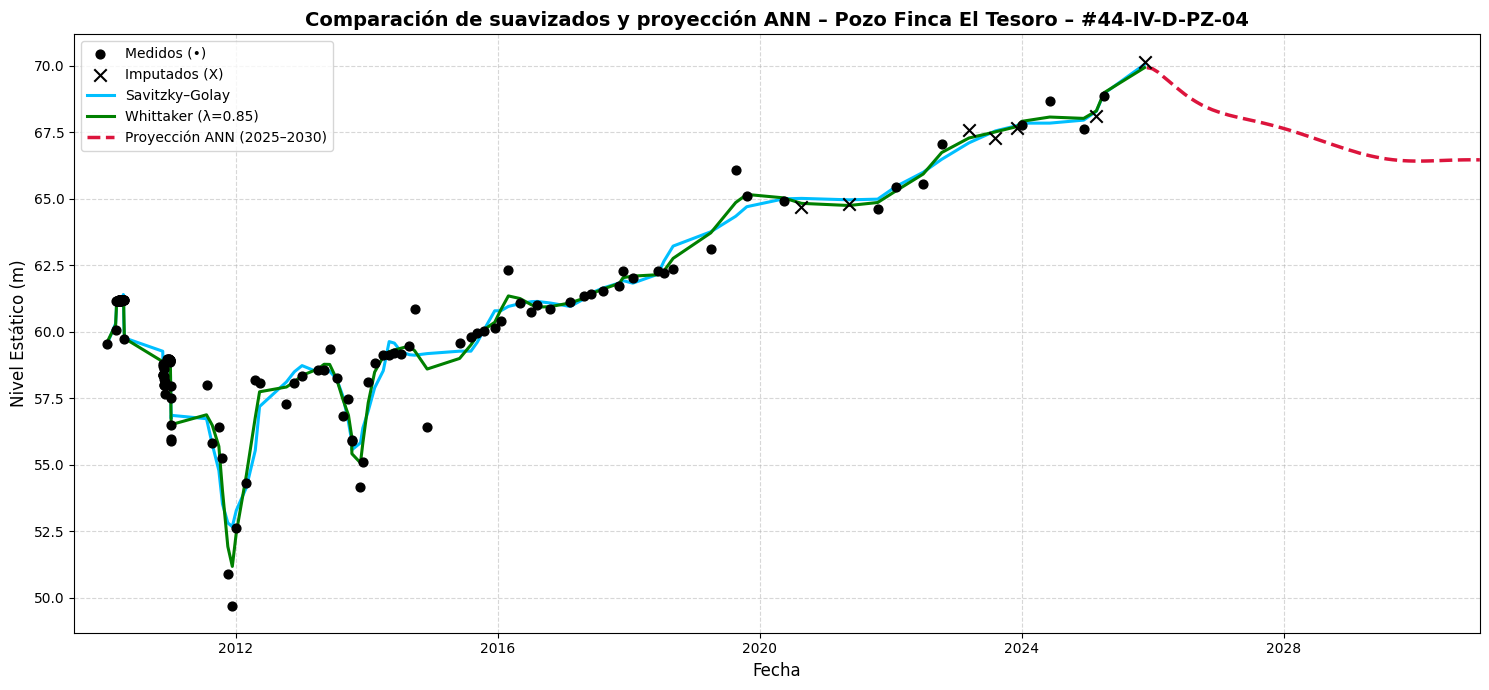


✅ Archivos exportados:
   - comparacion_suavizadores_44_IV_D_PZ_04.csv
   - proyeccion_ann_44_IV_D_PZ_04_2025_2030.csv
   - proyeccion_continua_44_IV_D_PZ_04.csv


In [ ]:
# ======================================================
# Pozo Finca El Tesoro – #44-IV-D-PZ-04
# Suavizado (Savitzky–Golay, Whittaker λ=0.85) + ANN (2025–2030)
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings("ignore")

# -----------------------------------------------
# 1️⃣ Datos del pozo
# -----------------------------------------------
data = {
    'Fecha': [
        '12/1/2010','1/3/2010','5/3/2010','6/3/2010','7/3/2010','8/3/2010','9/3/2010','10/3/2010','11/3/2010','12/3/2010',
        '13/3/2010','14/3/2010','15/3/2010','16/3/2010','17/3/2010','18/3/2010','19/3/2010','20/3/2010','21/3/2010','22/3/2010',
        '23/3/2010','24/3/2010','25/3/2010','26/3/2010','27/3/2010','28/3/2010','29/3/2010','30/3/2010','31/3/2010','1/4/2010',
        '2/4/2010','3/4/2010','4/4/2010','5/4/2010','6/4/2010','7/4/2010','8/4/2010','9/4/2010','10/4/2010','11/4/2010',
        '12/4/2010','13/4/2010','14/4/2010','15/4/2010','16/4/2010','19/4/2010','19/11/2010','20/11/2010','21/11/2010',
        '22/11/2010','23/11/2010','24/11/2010','25/11/2010','26/11/2010','27/11/2010','28/11/2010','29/11/2010','30/11/2010',
        '1/12/2010','15/12/2010','16/12/2010','17/12/2010','18/12/2010','19/12/2010','20/12/2010','21/12/2010','22/12/2010',
        '23/12/2010','24/12/2010','25/12/2010','26/12/2010','27/12/2010','28/12/2010','29/12/2010','30/12/2010','31/12/2010',
        '1/1/2011','2/1/2011','3/1/2011','4/1/2011','5/1/2011','6/1/2011','21/7/2011','22/8/2011','28/9/2011','18/10/2011',
        '17/11/2011','12/12/2011','3/1/2012','28/2/2012','18/4/2012','12/5/2012','9/10/2012','22/11/2012','4/1/2013',
        '4/4/2013','7/5/2013','7/6/2013','16/7/2013','20/8/2013','20/9/2013','8/10/2013','9/10/2013','26/11/2013','9/12/2013',
        '8/1/2014','13/2/2014','2/4/2014','5/5/2014','3/6/2014','10/7/2014','26/8/2014','24/9/2014','3/12/2014','2/6/2015',
        '4/8/2015','8/9/2015','15/10/2015','15/12/2015','18/1/2016','29/2/2016','4/5/2016','6/7/2016','9/8/2016','20/10/2016',
        '8/2/2017','27/4/2017','2/6/2017','8/8/2017','9/11/2017','30/11/2017','23/1/2018','12/6/2018','16/7/2018','5/9/2018',
        '3/4/2019','20/8/2019','21/10/2019','13/5/2020','21/8/2020','13/5/2021','20/10/2021','1/2/2022','1/7/2022','12/10/2022',
        '13/3/2023','8/8/2023','7/12/2023','1/1/2024','6/6/2024','12/12/2024','21/2/2025','4/4/2025','17/11/2025'
    ],
    'Nivel_Estatico_m': [
        59.55,60.06,61.16,61.14,61.16,61.16,61.16,61.15,61.15,61.15,61.15,61.15,61.15,61.16,61.16,61.17,61.18,61.17,61.17,61.17,
        61.16,61.16,61.16,61.17,61.17,61.16,61.15,61.16,61.17,61.17,61.17,61.17,61.17,61.17,61.18,61.18,61.18,61.18,61.18,
        61.18,61.18,61.18,61.19,61.19,61.19,59.72,58.35,58.36,58.7,58.37,58.79,58.34,58.58,58.22,58,58,57.98,58.1,57.67,
        58.96,58.98,58.94,58.94,58.93,58.93,58.92,58.92,58.98,58.95,58.94,58.93,58.93,58.93,58.92,58.88,58.85,58.9,57.5,
        57.95,56.5,55.9,55.95,57.99,55.8,56.4,55.25,50.9,49.7,52.6,54.3,58.18,58.05,57.26,58.05,58.32,58.57,58.55,59.36,
        58.24,56.83,57.45,55.9,55.93,54.14,55.1,58.1,58.82,59.12,59.13,59.2,59.14,59.46,60.86,56.4,59.58,59.78,59.95,
        60.02,60.12,60.38,62.31,61.07,60.73,60.98,60.83,61.12,61.32,61.41,61.53,61.72,62.29,62.03,62.26,62.21,62.36,63.1,
        66.06,65.11,64.9,64.7,64.8,64.6,65.43,65.54,67.06,67.56,67.29,67.66,67.77,68.68,67.61,68.12,68.86,70.15
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Fechas imputadas
# -----------------------------------------------
fechas_imputadas = [
    '21/08/2020','13/05/2021','13/03/2023','8/08/2023','7/12/2023','21/02/2025','17/11/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados (Savitzky–Golay y Whittaker λ=0.85)
# ======================================================
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=0.85)

# ======================================================
# 4️⃣ Comparación de suavizadores
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', 'Whittaker (λ=0.85)']).round(4)
print("\n📊 Comparación de suavizadores:\n")
print(tabla)

# ======================================================
# 5️⃣ Preparación de datos para LSTM (desde 2018)
# ======================================================
serie = df[['Fecha','Whittaker']].set_index('Fecha').resample('M').mean().interpolate()
fecha_corte = pd.Timestamp('2018-01-01')
serie_reciente = serie[serie.index >= fecha_corte].copy()

scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(serie_reciente)

def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
X_train, y_train = X, y

# ======================================================
# 6️⃣ Modelo LSTM
# ======================================================
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(window,1)),
    LSTM(64, activation='tanh', return_sequences=True),
    LSTM(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=600, batch_size=2, verbose=0)
print("✅ Modelo LSTM entrenado (tendencia reciente)")

# ======================================================
# 7️⃣ Proyección ANN hasta 2030
# ======================================================
last_date = serie.index[-1]
future_months = (2030 - last_date.year)*12 + (12 - last_date.month)
last_seq = scaled[-window:]
preds = []
for _ in range(future_months):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    last_seq = np.append(last_seq[1:], pred)[-window:]

future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(1),
                             periods=future_months, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

ultimo_valor_historico = serie.iloc[-1].values[0]
ultima_fecha_historica = serie.index[-1]
proyeccion_continua = pd.DataFrame({
    'Fecha': [ultima_fecha_historica] + future_df['Fecha'].tolist(),
    'Nivel': [ultimo_valor_historico] + future_df['Nivel_Predicho'].tolist()
})

# ======================================================
# 8️⃣ Gráfico final
# ======================================================
plt.figure(figsize=(15,7))
plt.scatter(df.loc[~df['Imputado'],'Fecha'], df.loc[~df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=40, label='Medidos (•)', marker='o', zorder=4)
plt.scatter(df.loc[df['Imputado'],'Fecha'], df.loc[df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=80, label='Imputados (X)', marker='x', zorder=4)
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2.2, label='Savitzky–Golay')
plt.plot(df['Fecha'], df['Whittaker'], color='green', linewidth=2.2, label='Whittaker (λ=0.85)')
plt.plot(proyeccion_continua['Fecha'], proyeccion_continua['Nivel'],
         color='crimson', linestyle='--', linewidth=2.5, label='Proyección ANN (2025–2030)')
plt.title('Comparación de suavizados y proyección ANN – Pozo Finca El Tesoro – #44-IV-D-PZ-04',
          fontsize=14, weight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Nivel Estático (m)', fontsize=12)
plt.xlim(df['Fecha'].min() - pd.DateOffset(months=6), pd.Timestamp('2031-01-01'))
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ======================================================
# 9️⃣ Exportar resultados
# ======================================================
tabla.to_csv('comparacion_suavizadores_44_IV_D_PZ_04.csv')
future_df.to_csv('proyeccion_ann_44_IV_D_PZ_04_2025_2030.csv', index=False)
proyeccion_continua.to_csv('proyeccion_continua_44_IV_D_PZ_04.csv', index=False)

print("\n✅ Archivos exportados:")
print("   - comparacion_suavizadores_44_IV_D_PZ_04.csv")
print("   - proyeccion_ann_44_IV_D_PZ_04_2025_2030.csv")
print("   - proyeccion_continua_44_IV_D_PZ_04.csv")


Corozal - # 44-IV-D-PO-14


📊 Comparación de suavizadores:

                     RMSE     MAE      R²
Savitzky–Golay     0.2377  0.1786  0.9987
Whittaker (λ=0.2)  0.1288  0.0920  0.9996
✅ Modelo LSTM entrenado con datos desde 2018.


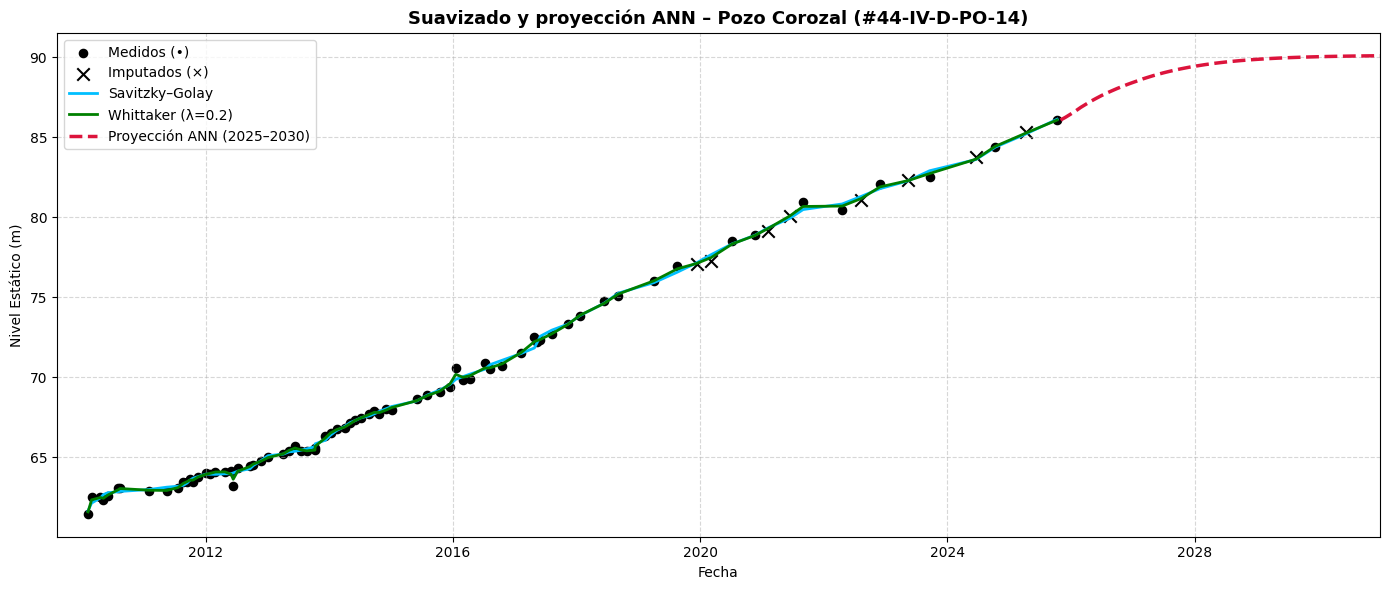


✅ Archivos exportados:
   - comparacion_suavizadores_44_IV_D_PO_14.csv
   - proyeccion_ann_44_IV_D_PO_14.csv
   - proyeccion_continua_44_IV_D_PO_14.csv


In [ ]:
# ======================================================
# Pozo Corozal – #44-IV-D-PO-14
# Suavizado (λ=0.2) + Proyección ANN (2018–2030)
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------
# 1️⃣ Datos del pozo Corozal – #44-IV-D-PO-14
# -----------------------------------------------
data = {
    'Fecha': [
        '5/2/2010','26/2/2010','19/4/2010','7/5/2010','2/6/2010','3/8/2010','13/8/2010',
        '1/2/2011','16/5/2011','21/7/2011','22/8/2011','14/9/2011','28/9/2011','18/10/2011',
        '17/11/2011','3/1/2012','26/1/2012','28/2/2012','23/4/2012','30/5/2012','12/6/2012',
        '8/7/2012','19/9/2012','9/10/2012','22/11/2012','4/1/2013','4/4/2013','7/5/2013',
        '12/6/2013','16/7/2013','20/8/2013','8/10/2013','9/10/2013','9/12/2013','8/1/2014',
        '13/2/2014','2/4/2014','5/5/2014','3/6/2014','10/7/2014','26/8/2014','24/9/2014',
        '24/10/2014','3/12/2014','5/1/2015','2/6/2015','4/8/2015','15/10/2015','15/12/2015',
        '18/1/2016','29/2/2016','11/4/2016','6/7/2016','9/8/2016','20/10/2016','8/2/2017',
        '27/4/2017','10/5/2017','1/6/2017','8/8/2017','9/11/2017','23/1/2018','12/6/2018',
        '5/9/2018','4/4/2019','20/8/2019','11/12/2019','7/3/2020','10/7/2020','20/11/2020',
        '8/2/2021','14/6/2021','1/9/2021','20/4/2022','11/8/2022','29/11/2022','14/5/2023',
        '18/9/2023','18/6/2024','10/10/2024','12/4/2025','11/10/2025'
    ],
    'Nivel_Estatico_m': [
        61.48,62.56,62.5,62.34,62.6,63.08,63.1,62.92,62.9,63.09,63.45,63.46,63.65,63.49,
        63.8,64.0,63.95,64.1,64.11,64.16,63.24,64.35,64.46,64.56,64.75,65.0,65.23,65.4,
        65.7,65.43,65.42,65.46,65.58,66.35,66.52,66.75,66.87,67.13,67.32,67.47,67.69,
        67.9,67.71,68.06,67.99,68.64,68.91,69.08,69.43,70.59,69.82,69.93,70.88,70.51,
        70.73,71.53,72.5,72.21,72.32,72.7,73.37,73.82,74.75,75.08,76.04,76.95,77.12,
        77.25,78.56,78.9,79.15,80.11,80.97,80.47,81.11,82.1,82.31,82.55,83.78,84.4,
        85.31,86.08
    ]
}

df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Fechas imputadas
# -----------------------------------------------
fechas_imputadas = [
    '11/12/2019','7/03/2020','8/02/2021','14/06/2021',
    '11/08/2022','14/05/2023','18/06/2024','12/04/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados (Savitzky–Golay y Whittaker λ=0.2)
# ======================================================
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=0.2)

# ======================================================
# 4️⃣ Comparación de suavizadores
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', 'Whittaker (λ=0.2)']).round(4)
print("\n📊 Comparación de suavizadores:\n")
print(tabla)

# ======================================================
# 5️⃣ Preparación de datos para LSTM (2018–2025)
# ======================================================
serie = df[['Fecha','Whittaker']].set_index('Fecha').resample('M').mean().interpolate()
serie_reciente = serie[serie.index >= '2018-01-01']

scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(serie_reciente)

def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
X_train, y_train = X, y

# Modelo LSTM
from tensorflow.keras.callbacks import EarlyStopping
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(window,1)),
    LSTM(64, activation='tanh', return_sequences=True),
    LSTM(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
es = EarlyStopping(patience=50, restore_best_weights=True)
model.fit(X_train, y_train, epochs=600, batch_size=2, verbose=0, callbacks=[es])
print("✅ Modelo LSTM entrenado con datos desde 2018.")

# ======================================================
# 6️⃣ Proyección ANN hasta 2030 (continua)
# ======================================================
last_date = serie.index[-1]
future_months = (2030 - last_date.year)*12 + (12 - last_date.month)
last_seq = scaled[-window:]
preds = []

for i in range(future_months):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    last_seq = np.append(last_seq[1:], pred)[-window:]

future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(1), periods=future_months, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

# Serie continua
ultimo_valor = serie.iloc[-1].values[0]
serie_continua = pd.DataFrame({
    'Fecha': [serie.index[-1]] + list(future_df['Fecha']),
    'Nivel': [ultimo_valor] + list(future_df['Nivel_Predicho'])
})

# ======================================================
# 7️⃣ Gráfico final
# ======================================================
plt.figure(figsize=(14,6))
plt.scatter(df.loc[~df['Imputado'],'Fecha'], df.loc[~df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=35, label='Medidos (•)', marker='o')
plt.scatter(df.loc[df['Imputado'],'Fecha'], df.loc[df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=80, label='Imputados (×)', marker='x')
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2, label='Savitzky–Golay')
plt.plot(df['Fecha'], df['Whittaker'], color='green', linewidth=2, label='Whittaker (λ=0.2)')
plt.plot(serie_continua['Fecha'], serie_continua['Nivel'],
         color='crimson', linestyle='--', linewidth=2.5, label='Proyección ANN (2025–2030)')
plt.title('Suavizado y proyección ANN – Pozo Corozal (#44-IV-D-PO-14)', fontsize=13, weight='bold')
plt.xlabel('Fecha'); plt.ylabel('Nivel Estático (m)')
plt.xlim(df['Fecha'].min()-pd.DateOffset(months=6), pd.Timestamp('2031-01-01'))
plt.legend(); plt.grid(True, linestyle='--', alpha=0.5); plt.tight_layout()
plt.show()

# ======================================================
# 8️⃣ Exportar resultados
# ======================================================
tabla.to_csv('comparacion_suavizadores_44_IV_D_PO_14.csv')
future_df.to_csv('proyeccion_ann_44_IV_D_PO_14.csv', index=False)
serie_continua.to_csv('proyeccion_continua_44_IV_D_PO_14.csv', index=False)

print("\n✅ Archivos exportados:")
print("   - comparacion_suavizadores_44_IV_D_PO_14.csv")
print("   - proyeccion_ann_44_IV_D_PO_14.csv")
print("   - proyeccion_continua_44_IV_D_PO_14.csv")


Corozal - # 44-IV-D-PZ-22


📊 Comparación de suavizadores:

                      RMSE     MAE      R²
Savitzky–Golay      0.2698  0.2033  0.9982
Whittaker (λ=0.15)  0.1472  0.1013  0.9994

📅 Serie usada para entrenamiento: 93 meses (2018–2025)
   Tendencia reciente: 76.58 → 89.68 m
✅ Modelo LSTM entrenado con datos recientes (2018–2025)


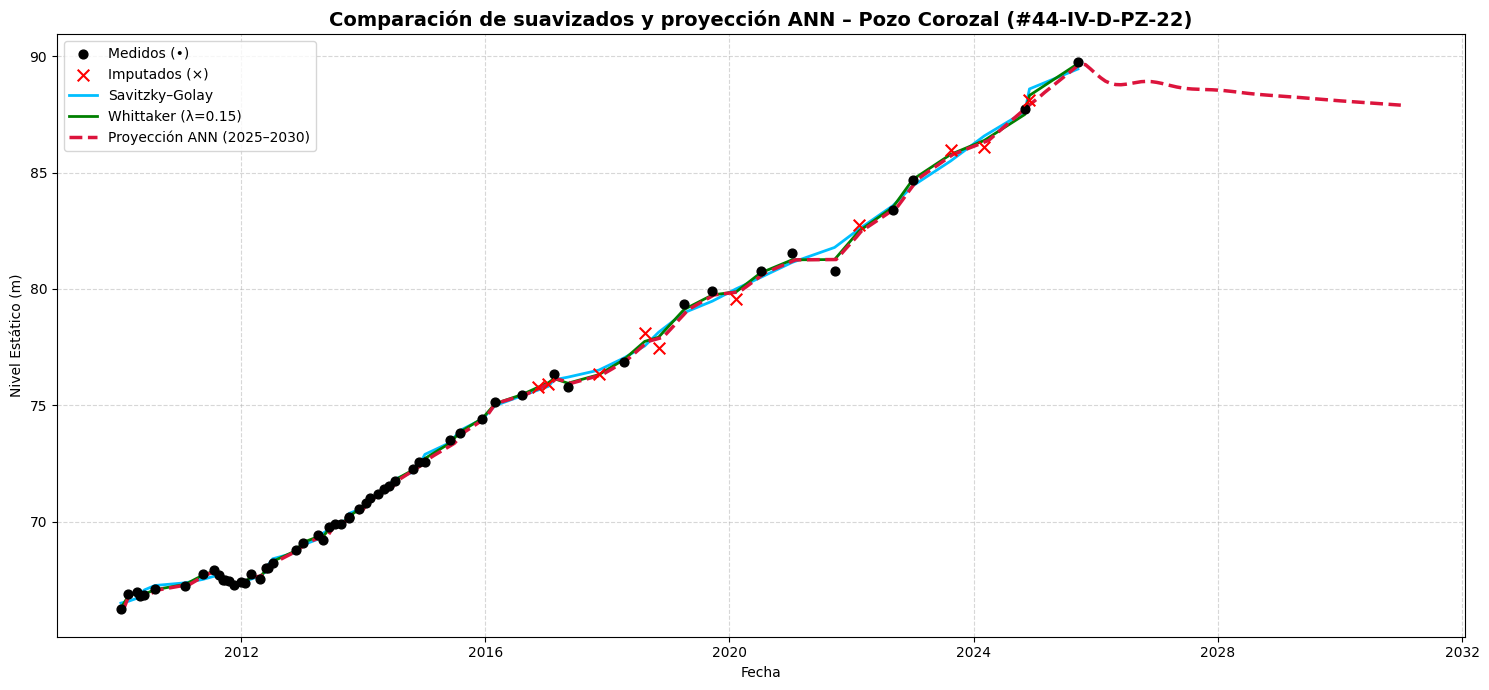


✅ Archivos exportados:
   - comparacion_suavizadores_44_IV_D_PZ_22.csv
   - proyeccion_ann_44_IV_D_PZ_22.csv
   - proyeccion_ann_continua_44_IV_D_PZ_22.csv


In [ ]:
# ======================================================
# Pozo Corozal – #44-IV-D-PZ-22
# Suavizado (λ = 0.15) y Proyección ANN (2018–2030)
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------
# 1️⃣ Datos del pozo
# -----------------------------------------------
data = {
    'Fecha': [
        '12/1/2010','26/2/2010','19/4/2010','7/5/2010','2/6/2010','3/8/2010','1/2/2011','16/5/2011','21/7/2011','22/8/2011',
        '14/9/2011','28/9/2011','18/10/2011','17/11/2011','3/1/2012','26/1/2012','28/2/2012','24/4/2012','30/5/2012','12/6/2012',
        '8/7/2012','22/11/2012','4/1/2013','4/4/2013','7/5/2013','12/6/2013','16/7/2013','20/8/2013','8/10/2013','9/10/2013',
        '9/12/2013','20/1/2014','13/2/2014','2/4/2014','5/5/2014','3/6/2014','10/7/2014','24/10/2014','3/12/2014','5/1/2015',
        '2/6/2015','4/8/2015','15/12/2015','29/2/2016','9/8/2016','11/11/2016','13/1/2017','15/2/2017','10/5/2017','10/11/2017',
        '9/4/2018','12/8/2018','3/11/2018','4/4/2019','21/9/2019','10/2/2020','5/7/2020','10/1/2021','21/9/2021','14/2/2022',
        '5/9/2022','3/1/2023','17/8/2023','5/3/2024','3/11/2024','30/11/2024','16/9/2025'
    ],
    'Nivel_Estatico_m': [
        66.24,66.9,66.98,66.81,66.87,67.12,67.24,67.74,67.94,67.7,67.5,67.48,67.45,67.3,67.4,67.35,67.74,67.55,68,68,
        68.25,68.79,69.1,69.45,69.22,69.79,69.91,69.9,70.2,70.17,70.57,70.79,71.01,71.19,71.39,71.52,71.75,72.27,72.58,72.55,
        73.5,73.82,74.4,75.14,75.44,75.79,75.91,76.34,75.77,76.34,76.87,78.1,77.45,79.36,79.91,79.56,80.78,81.56,80.79,82.75,
        83.41,84.7,85.98,86.11,87.75,88.1,89.76
    ]
}
df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Fechas imputadas
# -----------------------------------------------
fechas_imputadas = [
    '11/11/2016','13/01/2017','10/11/2017','12/08/2018','03/11/2018',
    '10/02/2020','14/02/2022','17/08/2023','05/03/2024','30/11/2024'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados (Savitzky–Golay y Whittaker λ=0.15)
# ======================================================
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=0.15)

# ======================================================
# 4️⃣ Comparación de suavizadores
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', 'Whittaker (λ=0.15)']).round(4)
print("\n📊 Comparación de suavizadores:\n")
print(tabla)

# ======================================================
# 5️⃣ Preparación de datos para LSTM (desde 2018)
# ======================================================
serie = df[['Fecha','Whittaker']].set_index('Fecha').resample('M').mean().interpolate()
serie_reciente = serie[serie.index >= '2018-01-01']

print(f"\n📅 Serie usada para entrenamiento: {len(serie_reciente)} meses (2018–2025)")
print(f"   Tendencia reciente: {serie_reciente.iloc[0,0]:.2f} → {serie_reciente.iloc[-1,0]:.2f} m")

scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(serie_reciente)

def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
X_train, y_train = X, y

# ======================================================
# 6️⃣ Modelo LSTM y proyección hasta 2030
# ======================================================
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(window,1)),
    LSTM(64, activation='tanh', return_sequences=True),
    LSTM(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=600, batch_size=2, verbose=0)
print("✅ Modelo LSTM entrenado con datos recientes (2018–2025)")

last_date = serie.index[-1]
future_months = (2030 - last_date.year)*12 + (12 - last_date.month)
last_seq = scaled[-window:]
preds = []
for _ in range(future_months):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    last_seq = np.append(last_seq[1:], pred)[-window:]

future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(1), periods=future_months, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

proyeccion_continua = pd.concat([
    serie.reset_index().rename(columns={'Whittaker':'Nivel'}),
    future_df.rename(columns={'Nivel_Predicho':'Nivel'})
]).reset_index(drop=True)

# ======================================================
# 7️⃣ Gráfico completo
# ======================================================
plt.figure(figsize=(15,7))
plt.scatter(df.loc[~df['Imputado'],'Fecha'], df.loc[~df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=40, label='Medidos (•)', marker='o', zorder=4)
plt.scatter(df.loc[df['Imputado'],'Fecha'], df.loc[df['Imputado'],'Nivel_Estatico_m'],
            color='red', s=70, label='Imputados (×)', marker='x', zorder=4)
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2, label='Savitzky–Golay')
plt.plot(df['Fecha'], df['Whittaker'], color='green', linewidth=2, label='Whittaker (λ=0.15)')
plt.plot(proyeccion_continua['Fecha'], proyeccion_continua['Nivel'],
         color='crimson', linestyle='--', linewidth=2.5, label='Proyección ANN (2025–2030)')

plt.title('Comparación de suavizados y proyección ANN – Pozo Corozal (#44-IV-D-PZ-22)', fontsize=14, weight='bold')
plt.xlabel('Fecha')
plt.ylabel('Nivel Estático (m)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ======================================================
# 8️⃣ Exportar resultados
# ======================================================
tabla.to_csv('comparacion_suavizadores_44_IV_D_PZ_22.csv')
future_df.to_csv('proyeccion_ann_44_IV_D_PZ_22.csv', index=False)
proyeccion_continua.to_csv('proyeccion_ann_continua_44_IV_D_PZ_22.csv', index=False)

print("\n✅ Archivos exportados:")
print("   - comparacion_suavizadores_44_IV_D_PZ_22.csv")
print("   - proyeccion_ann_44_IV_D_PZ_22.csv")
print("   - proyeccion_ann_continua_44_IV_D_PZ_22.csv")


Cantagallo - # 52-II-A-PZ-01 Corozal


📊 Comparación de suavizadores:

                      RMSE     MAE      R²
Savitzky–Golay      0.2607  0.1758  0.9952
Whittaker (λ=0.15)  0.1247  0.0759  0.9989

📅 Serie usada para entrenamiento: 95 meses (2018–2025)
   Tendencia reciente: 39.93 → 45.96 m
✅ Modelo LSTM entrenado con datos recientes (2018–2025)


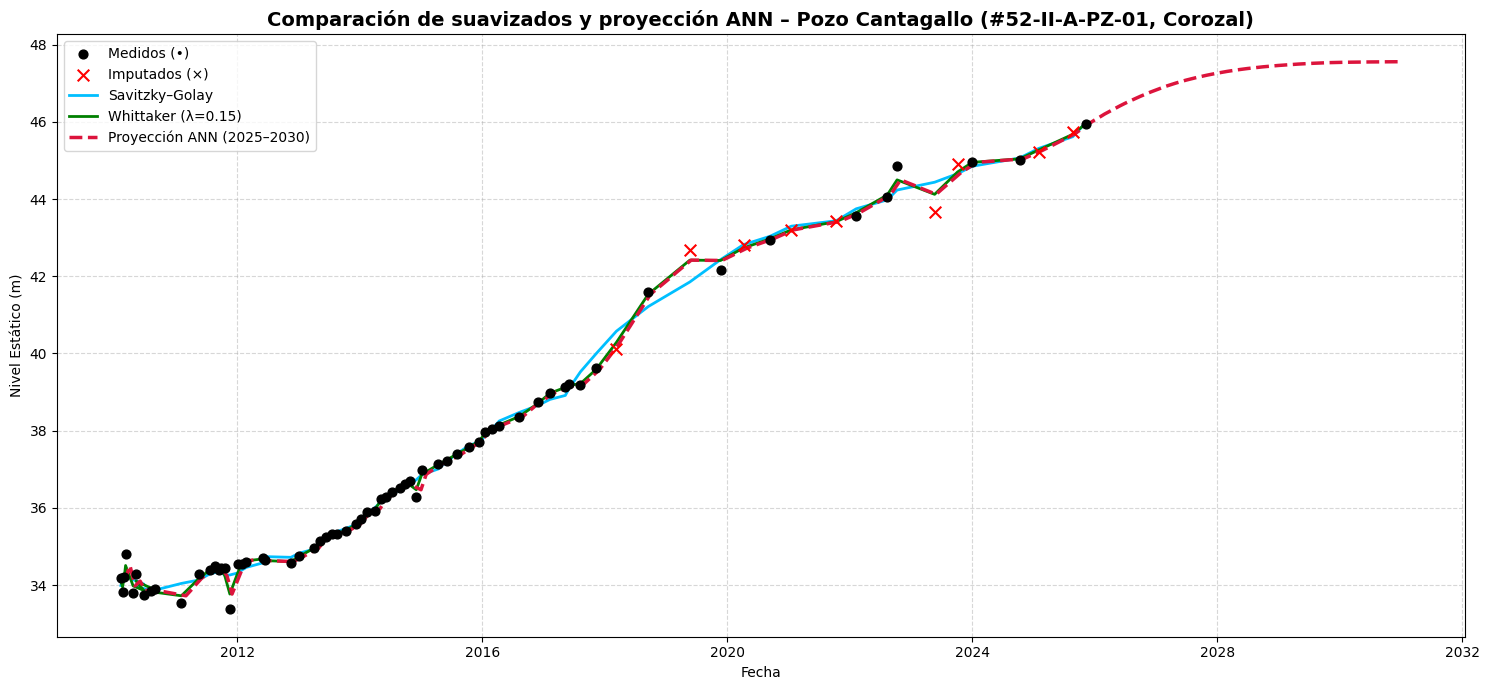


✅ Archivos exportados:
   - comparacion_suavizadores_52_II_A_PZ_01.csv
   - proyeccion_ann_52_II_A_PZ_01.csv
   - proyeccion_ann_continua_52_II_A_PZ_01.csv


In [ ]:
# ======================================================
# Pozo Cantagallo – #52-II-A-PZ-01 (Corozal)
# Suavizado (λ = 0.15) y Proyección ANN (2018–2030)
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------
# 1️⃣ Datos del pozo
# -----------------------------------------------
data = {
    'Fecha': [
        '5/02/2010','15/02/2010','26/02/2010','5/03/2010','19/04/2010','22/06/2010','7/05/2010','3/08/2010','27/08/2010',
        '1/02/2011','16/05/2011','21/07/2011','22/08/2011','14/09/2011','28/09/2011','18/10/2011','17/11/2011','3/01/2012',
        '26/01/2012','24/02/2012','30/05/2012','13/06/2012','15/11/2012','4/01/2013','4/04/2013','7/05/2013','12/06/2013',
        '16/07/2013','20/08/2013','9/10/2013','9/12/2013','8/01/2014','13/02/2014','2/04/2014','5/05/2014','3/06/2014',
        '10/07/2014','26/08/2014','24/09/2014','24/10/2014','3/12/2014','5/01/2015','13/04/2015','2/06/2015','5/08/2015',
        '15/10/2015','15/12/2015','18/01/2016','29/02/2016','11/04/2016','9/08/2016','28/11/2016','8/02/2017','10/05/2017',
        '1/06/2017','8/08/2017','9/11/2017','11/03/2018','17/09/2018','23/05/2019','22/11/2019','7/04/2020','11/09/2020',
        '17/01/2021','12/10/2021','8/02/2022','12/08/2022','10/10/2022','22/05/2023','6/10/2023','2/01/2024','10/10/2024',
        '1/02/2025','23/08/2025','11/11/2025'
    ],
    'Nivel_Estatico_m': [
        34.17,33.81,34.2,34.8,33.79,33.75,34.29,33.84,33.9,33.53,34.29,34.39,34.49,34.4,34.43,34.45,33.37,34.54,34.54,
        34.6,34.7,34.64,34.57,34.74,34.97,35.14,35.24,35.31,35.32,35.41,35.57,35.72,35.9,35.92,36.23,36.27,36.41,36.52,
        36.61,36.7,36.27,36.97,37.14,37.22,37.39,37.58,37.71,37.97,38.04,38.13,38.34,38.73,38.98,39.13,39.21,39.17,39.61,
        40.12,41.59,42.68,42.16,42.81,42.95,43.21,43.44,43.57,44.04,44.86,43.67,44.92,44.97,45.0,45.22,45.74,45.94
    ]
}
df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Fechas imputadas
# -----------------------------------------------
fechas_imputadas = [
    '11/03/2018','23/05/2019','7/04/2020','17/01/2021','12/10/2021',
    '22/05/2023','6/10/2023','1/02/2025','23/08/2025'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados (Savitzky–Golay y Whittaker λ=0.15)
# ======================================================
window = 11 if len(df) >= 11 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=3)

def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=0.15)

# ======================================================
# 4️⃣ Comparación de suavizadores
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', 'Whittaker (λ=0.15)']).round(4)
print("\n📊 Comparación de suavizadores:\n")
print(tabla)

# ======================================================
# 5️⃣ Preparación de datos para LSTM (desde 2018)
# ======================================================
serie = df[['Fecha','Whittaker']].set_index('Fecha').resample('M').mean().interpolate()
serie_reciente = serie[serie.index >= '2018-01-01']

print(f"\n📅 Serie usada para entrenamiento: {len(serie_reciente)} meses (2018–2025)")
print(f"   Tendencia reciente: {serie_reciente.iloc[0,0]:.2f} → {serie_reciente.iloc[-1,0]:.2f} m")

scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(serie_reciente)

def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 12
X, y = create_sequences(scaled, window)
X_train, y_train = X, y

# ======================================================
# 6️⃣ Modelo LSTM y proyección hasta 2030
# ======================================================
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(window,1)),
    LSTM(64, activation='tanh', return_sequences=True),
    LSTM(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=600, batch_size=2, verbose=0)
print("✅ Modelo LSTM entrenado con datos recientes (2018–2025)")

last_date = serie.index[-1]
future_months = (2030 - last_date.year)*12 + (12 - last_date.month)
last_seq = scaled[-window:]
preds = []
for _ in range(future_months):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    last_seq = np.append(last_seq[1:], pred)[-window:]

future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(1), periods=future_months, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

proyeccion_continua = pd.concat([
    serie.reset_index().rename(columns={'Whittaker':'Nivel'}),
    future_df.rename(columns={'Nivel_Predicho':'Nivel'})
]).reset_index(drop=True)

# ======================================================
# 7️⃣ Gráfico completo
# ======================================================
plt.figure(figsize=(15,7))
plt.scatter(df.loc[~df['Imputado'],'Fecha'], df.loc[~df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=40, label='Medidos (•)', marker='o', zorder=4)
plt.scatter(df.loc[df['Imputado'],'Fecha'], df.loc[df['Imputado'],'Nivel_Estatico_m'],
            color='red', s=70, label='Imputados (×)', marker='x', zorder=4)
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2, label='Savitzky–Golay')
plt.plot(df['Fecha'], df['Whittaker'], color='green', linewidth=2, label='Whittaker (λ=0.15)')
plt.plot(proyeccion_continua['Fecha'], proyeccion_continua['Nivel'],
         color='crimson', linestyle='--', linewidth=2.5, label='Proyección ANN (2025–2030)')

plt.title('Comparación de suavizados y proyección ANN – Pozo Cantagallo (#52-II-A-PZ-01, Corozal)', fontsize=14, weight='bold')
plt.xlabel('Fecha')
plt.ylabel('Nivel Estático (m)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ======================================================
# 8️⃣ Exportar resultados
# ======================================================
tabla.to_csv('comparacion_suavizadores_52_II_A_PZ_01.csv')
future_df.to_csv('proyeccion_ann_52_II_A_PZ_01.csv', index=False)
proyeccion_continua.to_csv('proyeccion_ann_continua_52_II_A_PZ_01.csv', index=False)

print("\n✅ Archivos exportados:")
print("   - comparacion_suavizadores_52_II_A_PZ_01.csv")
print("   - proyeccion_ann_52_II_A_PZ_01.csv")
print("   - proyeccion_ann_continua_52_II_A_PZ_01.csv")




```
# Esto tiene formato de código
```

Corozal - # 44-IV-D-PZ-20


📊 Comparación de suavizadores:

                      RMSE     MAE      R²
Savitzky–Golay      0.3673  0.2558  0.9028
Whittaker (λ=0.85)  0.2508  0.1639  0.9547
✅ Modelo LSTM entrenado con datos 2013–2016


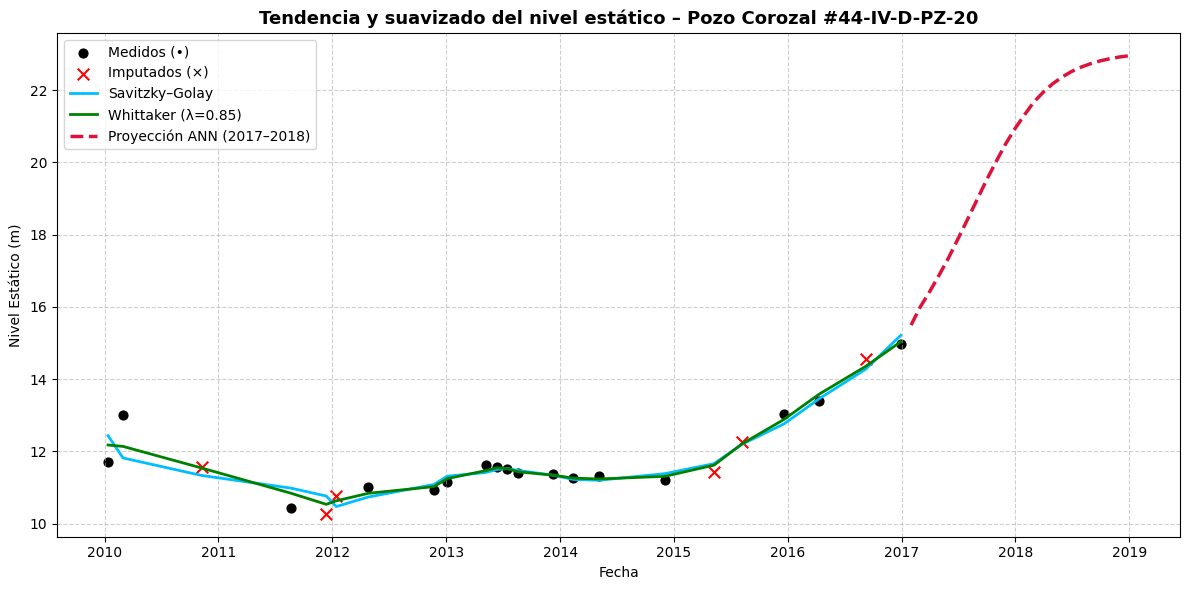


✅ Archivos exportados:
   - comparacion_suavizadores_44_IV_D_PZ_20.csv
   - tendencia_ann_44_IV_D_PZ_20.csv


In [ ]:
# ======================================================
# Pozo Corozal – #44-IV-D-PZ-20
# Suavizado (λ = 0.85) y tendencia ANN (2013–2016)
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------
# 1️⃣ Datos del pozo
# -----------------------------------------------
data = {
    'Fecha': [
        '12/01/2010','1/03/2010','8/11/2010','22/08/2011','13/12/2011','14/01/2012',
        '26/04/2012','22/11/2012','4/01/2013','7/05/2013','13/06/2013','16/07/2013',
        '20/08/2013','9/12/2013','13/02/2014','5/05/2014','3/12/2014','10/05/2015',
        '7/08/2015','21/12/2015','11/04/2016','7/09/2016','29/12/2016'
    ],
    'Nivel_Estatico_m': [
        11.7,13.0,11.57,10.43,10.27,10.77,11.0,10.94,11.16,11.61,11.56,11.52,
        11.4,11.37,11.25,11.32,11.22,11.44,12.27,13.02,13.39,14.56,14.96
    ]
}
df = pd.DataFrame(data)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')

# -----------------------------------------------
# 2️⃣ Fechas imputadas
# -----------------------------------------------
fechas_imputadas = [
    '8/11/2010','13/12/2011','14/01/2012','10/05/2015','7/08/2015','7/09/2016'
]
fechas_imputadas = pd.to_datetime(fechas_imputadas, format='%d/%m/%Y')
df['Imputado'] = df['Fecha'].isin(fechas_imputadas)

# ======================================================
# 3️⃣ Suavizados (Savitzky–Golay y Whittaker λ=0.85)
# ======================================================
window = 9 if len(df) >= 9 else len(df) - (len(df) % 2 == 0)
df['Savitzky'] = savgol_filter(df['Nivel_Estatico_m'], window_length=window, polyorder=2)

def whittaker_smooth(y, lmbd, differences=2):
    m = len(y)
    E = sparse.eye(m, format='csc')
    D = E[1:] - E[:-1]
    for i in range(differences - 1):
        D = D[1:] - D[:-1]
    A = E + lmbd * D.T @ D
    z = spsolve(A, y)
    return z

df['Whittaker'] = whittaker_smooth(df['Nivel_Estatico_m'], lmbd=0.85)

# ======================================================
# 4️⃣ Comparación de suavizadores
# ======================================================
metrics = {
    'RMSE': [
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Savitzky'])),
        np.sqrt(mean_squared_error(df['Nivel_Estatico_m'], df['Whittaker']))
    ],
    'MAE': [
        mean_absolute_error(df['Nivel_Estatico_m'], df['Savitzky']),
        mean_absolute_error(df['Nivel_Estatico_m'], df['Whittaker'])
    ],
    'R²': [
        r2_score(df['Nivel_Estatico_m'], df['Savitzky']),
        r2_score(df['Nivel_Estatico_m'], df['Whittaker'])
    ]
}
tabla = pd.DataFrame(metrics, index=['Savitzky–Golay', 'Whittaker (λ=0.85)']).round(4)
print("\n📊 Comparación de suavizadores:\n")
print(tabla)

# ======================================================
# 5️⃣ Preparación de datos para LSTM (2013–2016)
# ======================================================
serie = df[['Fecha','Whittaker']].set_index('Fecha').resample('M').mean().interpolate()
serie_reciente = serie[serie.index >= '2013-01-01']

scaler = MinMaxScaler((0,1))
scaled = scaler.fit_transform(serie_reciente)

def create_sequences(data, window=6):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window = 6
X, y = create_sequences(scaled, window)
X_train, y_train = X, y

# ======================================================
# 6️⃣ Modelo LSTM y proyección hasta 2018 (tendencia)
# ======================================================
model = Sequential([
    LSTM(64, activation='tanh', return_sequences=True, input_shape=(window,1)),
    LSTM(32, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=400, batch_size=2, verbose=0)
print("✅ Modelo LSTM entrenado con datos 2013–2016")

last_date = serie_reciente.index[-1]
future_months = 24  # proyectar 2 años adicionales (2017–2018 aprox)
last_seq = scaled[-window:]
preds = []
for _ in range(future_months):
    pred = model.predict(last_seq.reshape(1, window, 1), verbose=0)
    preds.append(pred[0,0])
    last_seq = np.append(last_seq[1:], pred)[-window:]

future_dates = pd.date_range(start=last_date + pd.offsets.MonthEnd(1), periods=future_months, freq='M')
future_df = pd.DataFrame({
    'Fecha': future_dates,
    'Nivel_Predicho': scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
})

# ======================================================
# 7️⃣ Gráfico completo
# ======================================================
plt.figure(figsize=(12,6))
plt.scatter(df.loc[~df['Imputado'],'Fecha'], df.loc[~df['Imputado'],'Nivel_Estatico_m'],
            color='black', s=40, label='Medidos (•)', marker='o')
plt.scatter(df.loc[df['Imputado'],'Fecha'], df.loc[df['Imputado'],'Nivel_Estatico_m'],
            color='red', s=70, label='Imputados (×)', marker='x')
plt.plot(df['Fecha'], df['Savitzky'], color='deepskyblue', linewidth=2, label='Savitzky–Golay')
plt.plot(df['Fecha'], df['Whittaker'], color='green', linewidth=2, label='Whittaker (λ=0.85)')
plt.plot(future_df['Fecha'], future_df['Nivel_Predicho'], color='crimson', linestyle='--', linewidth=2.5,
         label='Proyección ANN (2017–2018)')

plt.title('Tendencia y suavizado del nivel estático – Pozo Corozal #44-IV-D-PZ-20', fontsize=13, weight='bold')
plt.xlabel('Fecha'); plt.ylabel('Nivel Estático (m)')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()

# ======================================================
# 8️⃣ Exportar resultados
# ======================================================
tabla.to_csv('comparacion_suavizadores_44_IV_D_PZ_20.csv')
future_df.to_csv('tendencia_ann_44_IV_D_PZ_20.csv', index=False)

print("\n✅ Archivos exportados:")
print("   - comparacion_suavizadores_44_IV_D_PZ_20.csv")
print("   - tendencia_ann_44_IV_D_PZ_20.csv")


SUBIR A GITHUB

In [7]:
%cd Proyecto-Acuifero-Morroa

/content/Proyecto-Acuifero-Morroa


In [9]:
!mkdir "algoritmos/graficos"